In [ ]:


# An insurance company is a company that provides financial protection against certain risks
# A policyholder is a person who has an insurance policy.
# If something covered by the policy happens, such as vehicle damage, the policyholder may file an insurance claim asking the insurance company to cover the eligible loss according to the policy
# I need to find which types of customers have claimed and which types have not claimed based on their available attributes
# Use historical insurance data to learn the characteristics and patterns associated with insurance claims, build classification models that predict whether a policyholder is likely to file a claim, and identify the important factors behind those predictions


M Raihan Nawaz21


In [70]:

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
# Machine Learning methods
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier



# Metrics Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


Insurance_df = pd.read_csv("Insurance_dataset.csv")
rows , cols = Insurance_df.shape
print("Rows: ", rows)
print("Columns: ", cols)
print("Total length :", len(Insurance_df))
Insurance_df.head()



Rows:  58592
Columns:  41
Total length : 58592


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [117]:
# Target column 
Insurance_df['claim_status'].head(15)


0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    1
13    0
14    0
Name: claim_status, dtype: int64

In [72]:
# Statistical measures of the dataset 

Insurance_df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000


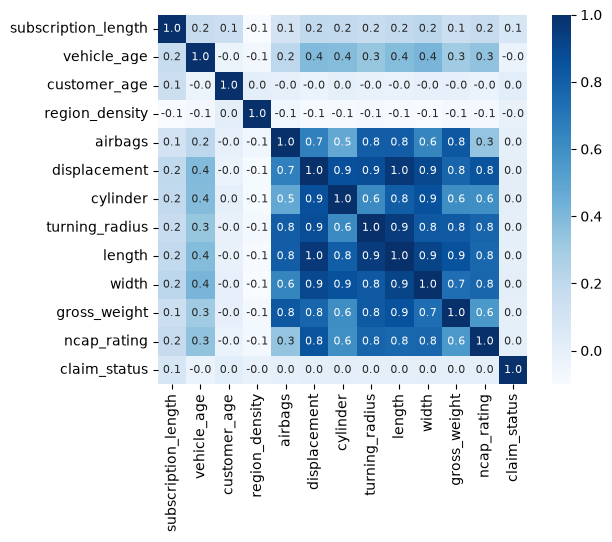

In [73]:
# Heatmap is used to show the correlation between the features 

import matplotlib.pyplot as plt 
import seaborn as sns 
numerical_cols = Insurance_df.select_dtypes(include=np.number)
correlation = numerical_cols.corr()
plt.Figure(figsize=(15, 10))
sns.heatmap(correlation, annot= True, square= True, fmt='.1f', annot_kws={'size': 8}, cmap='Blues')
plt.show()

In [74]:
numerical_cols = Insurance_df.select_dtypes(include=np.number)
print(numerical_cols.columns)
numerical_cols

Index(['subscription_length', 'vehicle_age', 'customer_age', 'region_density',
       'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
       'width', 'gross_weight', 'ncap_rating', 'claim_status'],
      dtype='str')


,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
0,9.3,1.2,41,8794,6,1493,4,5.2,4300,1790,1720,3,0
1,8.2,1.8,35,27003,2,1498,4,4.9,3995,1695,1051,4,0
2,9.5,0.2,44,8794,6,1493,4,5.2,4300,1790,1720,3,0
3,5.2,0.4,44,73430,2,796,3,4.6,3445,1515,1185,0,0
4,10.1,1.0,56,5410,2,1497,4,5.0,3990,1755,1490,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,34738,2,1197,4,4.8,3845,1735,1335,2,0
58588,2.3,2.2,37,4076,6,1493,4,5.2,4300,1790,1720,3,0
58589,6.6,2.2,35,8794,2,1197,4,4.8,3845,1735,1335,2,0
58590,4.1,3.6,44,8794,2,1197,4,4.8,3845,1735,1335,2,0


In [75]:
categorical_cols = Insurance_df.select_dtypes(include=['object', 'bool', 'category'])
print(len(categorical_cols.columns), categorical_cols.columns)
categorical_cols

28 Index(['policy_id', 'region_code', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'transmission_type',
       'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert'],
      dtype='str')


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\2188588585.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = Insurance_df.select_dtypes(include=['object', 'bool', 'category'])


,policy_id,region_code,segment,model,fuel_type,max_torque,max_power,engine_type,is_esc,is_adjustable_steering,...,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert
0,POL045360,C8,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
1,POL016745,C2,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,No,Yes,...,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
2,POL007194,C8,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
3,POL018146,C10,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,No,...,No,No,No,No,No,Yes,No,No,No,Yes
4,POL049011,C13,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,No,Yes,...,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,POL019269,C5,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,No,Yes,...,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
58588,POL001254,C3,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
58589,POL019859,C8,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,No,Yes,...,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
58590,POL014061,C8,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,No,Yes,...,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes


In [76]:
# Datatypes
dtypes_df = Insurance_df.dtypes
print('_' * 40)
print(' ' * 10,"Datatype of each column")
print('_' * 40)
print(dtypes_df)
print('_' * 40)
print(' ' * 10,'Missing_values')
print('_' * 40)

cols_list = Insurance_df.columns

for each_col in cols_list:
    count = (Insurance_df[each_col].isnull().sum()) 
    print(each_col, count)

print('_' * 40)
print("Duplicate Records")
print('_' * 40)
duplicate_recrds = Insurance_df.duplicated().sum()
print(duplicate_recrds)

print('_' * 40)
print(' ' * 10,'Unique_Values')
print('_' * 40)
print(Insurance_df.nunique())

________________________________________
           Datatype of each column
________________________________________
policy_id                               str
subscription_length                 float64
vehicle_age                         float64
customer_age                          int64
region_code                             str
region_density                        int64
segment                                 str
model                                   str
fuel_type                               str
max_torque                              str
max_power                               str
engine_type                             str
airbags                               int64
is_esc                                  str
is_adjustable_steering                  str
is_tpms                                 str
is_parking_sensors                      str
is_parking_camera                       str
rear_brakes_type                        str
displacement                          int64
cyl

In [77]:
# B. Statistical Analysis

print('_' * 80)
print(' ' * 15 ,"Statistical Analysis")
print('_' * 80)


print('_' * 30)
print(' ' * 10, 'Mean')
print('_' * 30)
print(round(numerical_cols.mean(),2))
print('_' * 30)
print(' ' * 10, 'Median')
print('_' * 30)
print(numerical_cols.median())
print('_' * 30)
print(' ' * 10, 'Mode')
print('_' * 30)
print(numerical_cols.mode().iloc[0])
print('_' * 30)
print(' ' * 10, 'Minimum')
print('_' * 30)
print(numerical_cols.min())

print('_' * 30)
print(' ' * 10, 'Maximum')
print('_' * 30)

print(numerical_cols.max())

print('_' * 30)
print(' ' * 10, 'Variance')
print('_' * 30)
print(round(numerical_cols.var(), 2))

print('_' * 30)
print(' ' * 10, 'Standard_deviation')
print('_' * 30)
print(round(numerical_cols.std(), 2))

print('_' * 30)
print(' ' * 10, 'Quartiles')
print('_' * 30)

Q1 = Insurance_df[numerical_cols.columns].quantile(0.25)
Q2 = Insurance_df[numerical_cols.columns].quantile(0.50)
Q3 = Insurance_df[numerical_cols.columns].quantile(0.75)

IQR = Q3 - Q1

print("Q1")
print(Q1)
print("\nQ2")
print(Q2)
print("\nQ3")
print(Q3)

print("\nIQR: ", IQR)


________________________________________________________________________________
                Statistical Analysis
________________________________________________________________________________
______________________________
           Mean
______________________________
subscription_length        6.11
vehicle_age                1.39
customer_age              44.82
region_density         18826.86
airbags                    3.14
displacement            1162.36
cylinder                   3.63
turning_radius             4.85
length                  3850.48
width                   1672.23
gross_weight            1385.28
ncap_rating                1.76
claim_status               0.06
dtype: float64
______________________________
           Median
______________________________
subscription_length       5.7
vehicle_age               1.2
customer_age             44.0
region_density         8794.0
airbags                   2.0
displacement           1197.0
cylinder                  4.0
tu

__________________________________________________
Distribution Analysis
____________________________________________________________


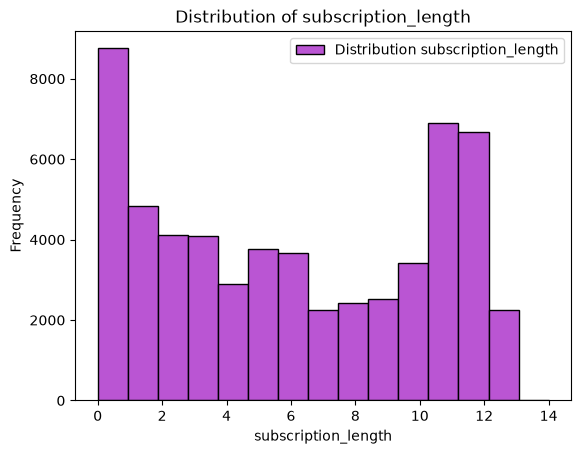

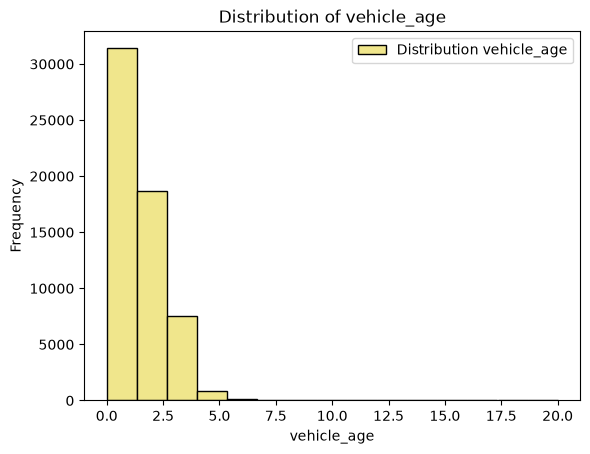

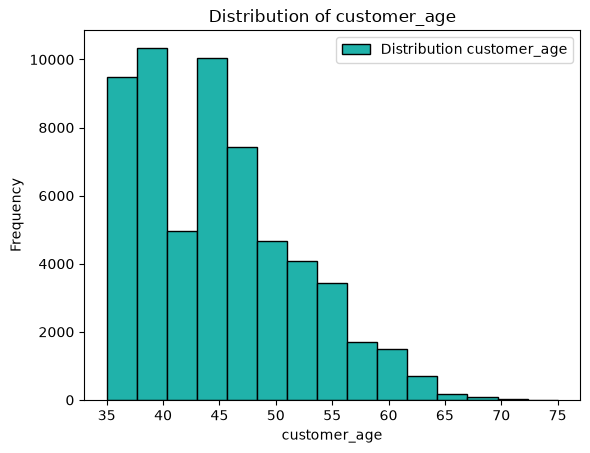

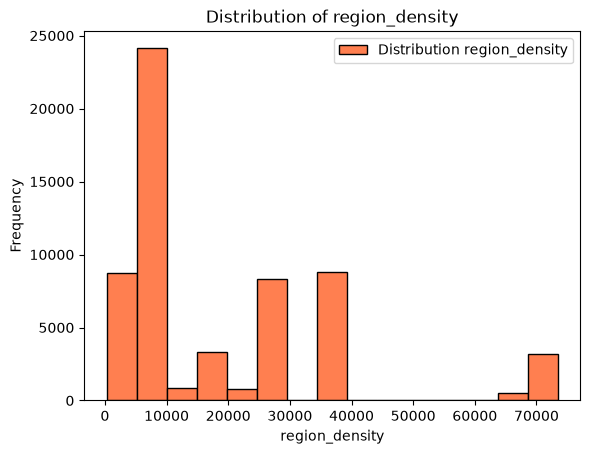

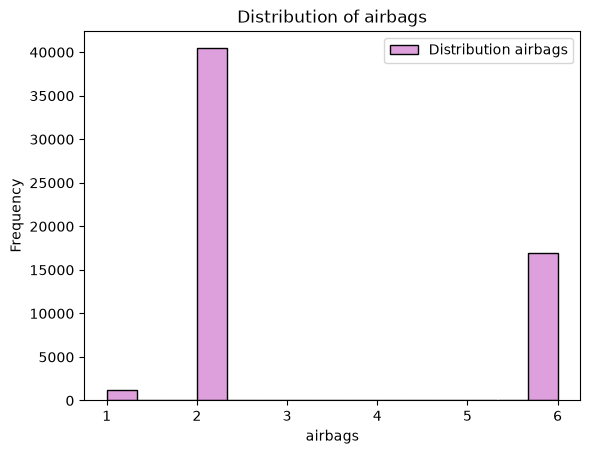

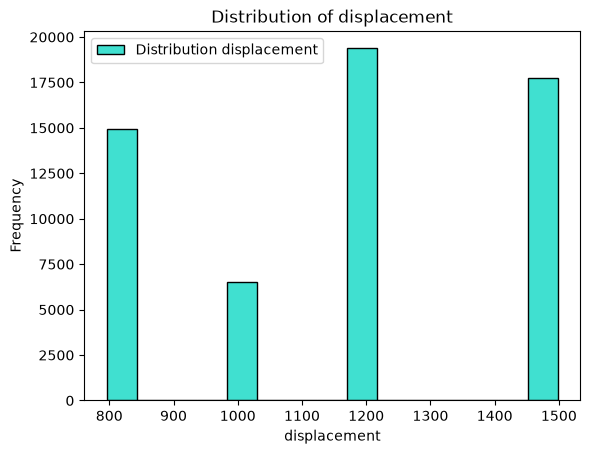

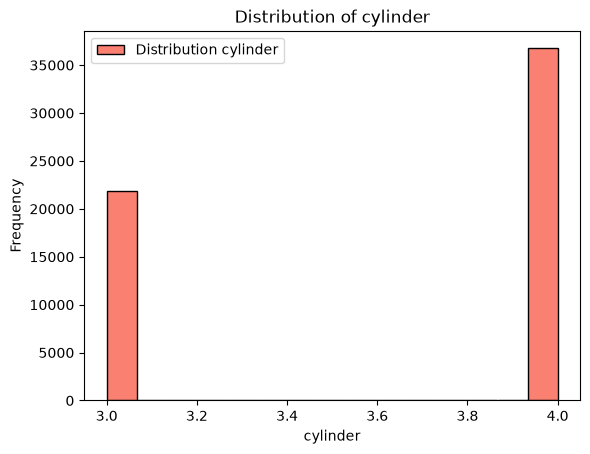

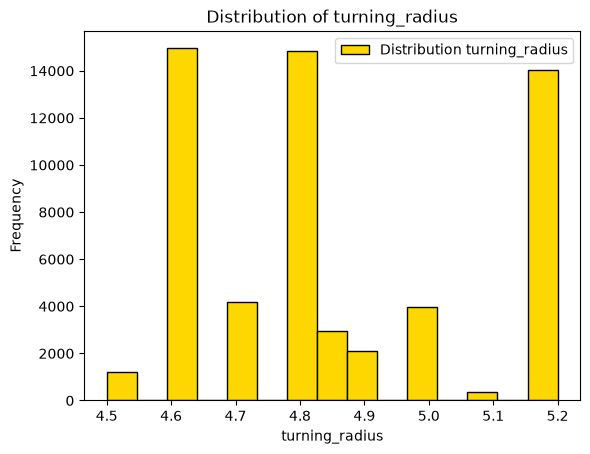

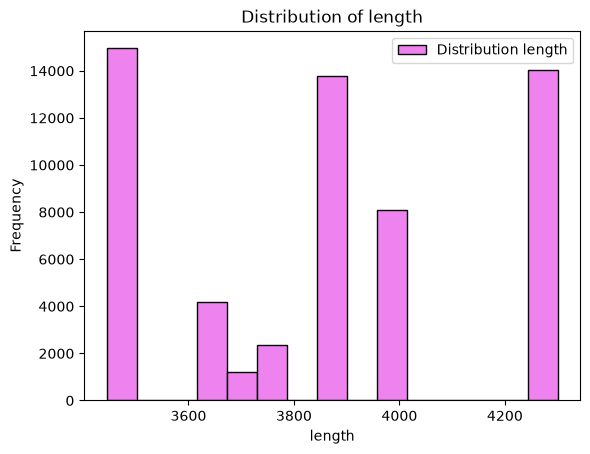

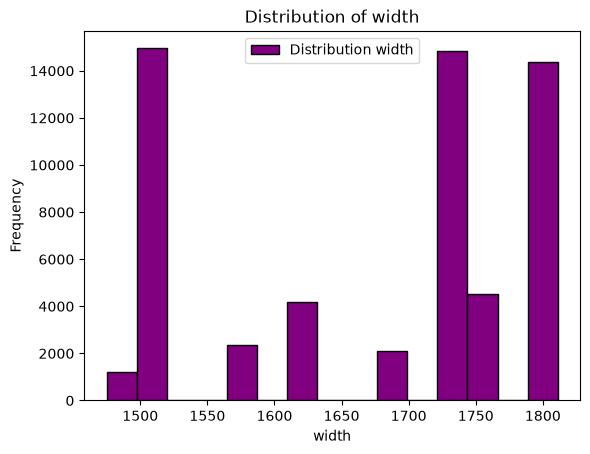

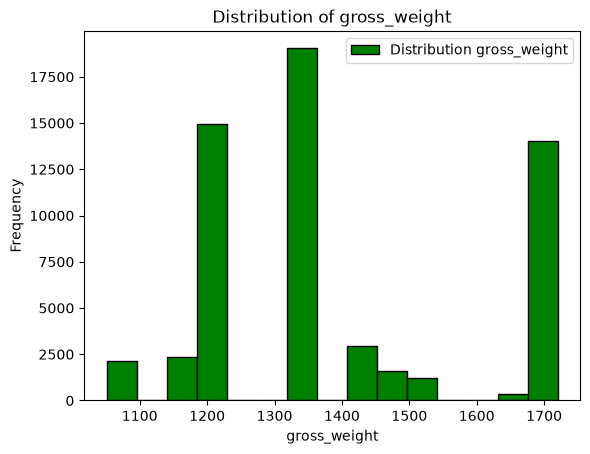

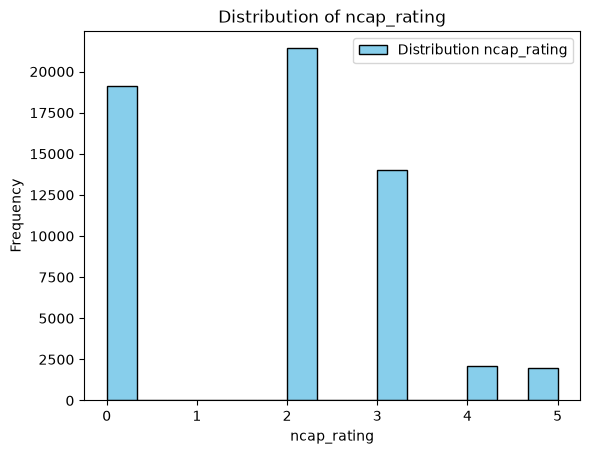

In [108]:
# Distribution Analysis is used to display how numerical values are distributed

print('_' * 50)
print('Distribution Analysis')
print('_' * 60)


colors = ["cyan", "skyblue","green","purple","violet","gold","salmon","turquoise","plum","coral","lightseagreen","khaki","mediumorchid"]

counter =12
for col in numerical_cols:

    plt.Figure(figsize=(8, 6))
    plt.hist(Insurance_df[col].dropna(),edgecolor='black', bins=15, label=f'Distribution {col}', color=colors[counter])
    counter -= 1
    plt.title("Distribution of "+col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


__________________________________________________
             CORRELATION ANALYSIS
__________________________________________________
                     subscription_length  vehicle_age  customer_age  \
subscription_length             1.000000     0.166320      0.143350   
vehicle_age                     0.166320     1.000000     -0.035222   
customer_age                    0.143350    -0.035222      1.000000   
region_density                 -0.100316    -0.062255      0.009495   
airbags                         0.104032     0.209073     -0.008151   
displacement                    0.194402     0.393208     -0.023577   
cylinder                        0.191222     0.379522      0.004349   
turning_radius                  0.166472     0.332716     -0.016755   
length                          0.190925     0.383177     -0.020020   
width                           0.213284     0.414104     -0.005980   
gross_weight                    0.141088     0.302127     -0.007691   
ncap_rating 

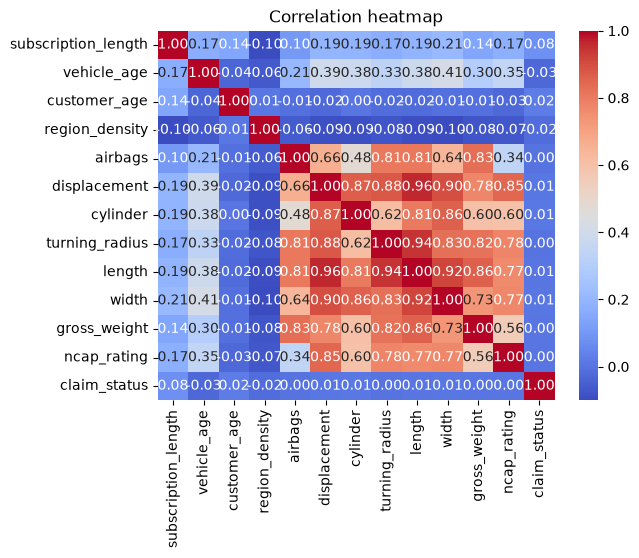

In [79]:
#  CORRELATION ANALYSIS is used to display how variables are corelated to each other if finds the relationship between the variable by matrix form
# Correlation Analysis  tells us how strongly two numerical variables are linearly related
# The correlation value ranges from -1 to +1
# +1 is the perfectly correlated and it represent the Red color
# 0 means no relationship btw variables
# -1 is the perfect negative relationship

import seaborn as sns 

print('_' * 50)
print(' ' * 12,'CORRELATION ANALYSIS')
print('_' * 50)

corr = Insurance_df[numerical_cols.columns].corr()
print(corr)

plt.Figure(figsize=(25, 15))
sns.heatmap(
    corr, annot=True, cmap='coolwarm', fmt='.2f'
    
)
plt.title("Correlation heatmap")
plt.show()

____________________________________________________________
EXPLORATORY DATA ANALYSIS (EDA)
____________________________________________________________
Numerical columns: ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'airbags', 'displacement', 'cylinder', 'turning_radius', 'length', 'width', 'gross_weight', 'ncap_rating']
Categorical columns: ['region_code', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']
12


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Insurance_df.select_dtypes(


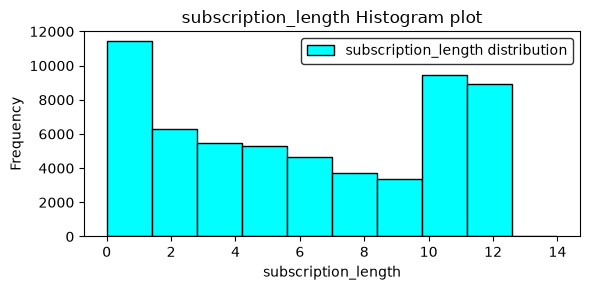

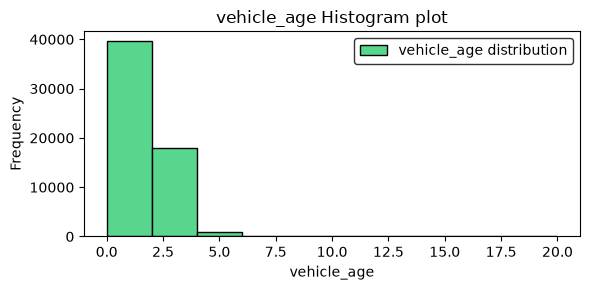

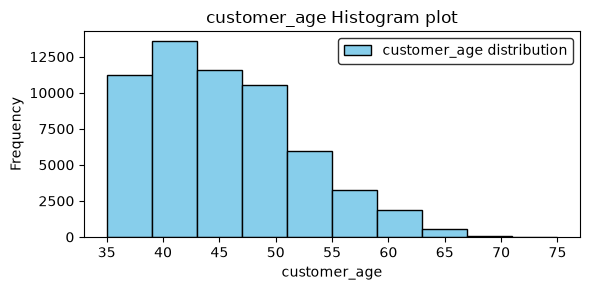

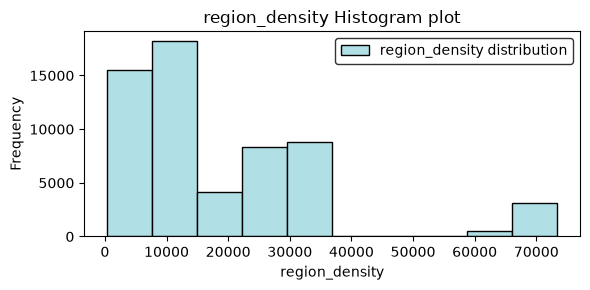

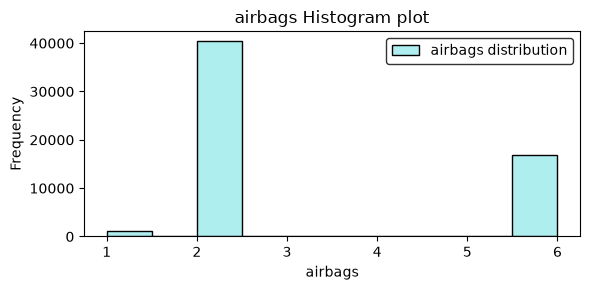

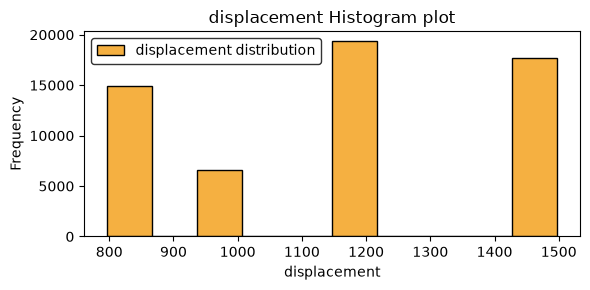

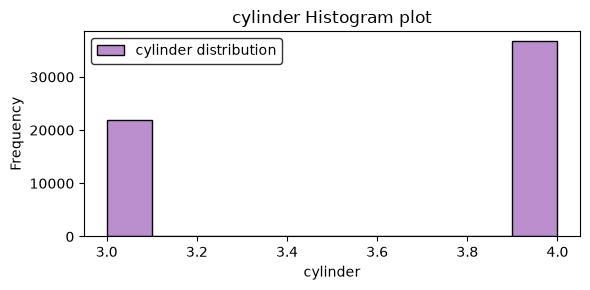

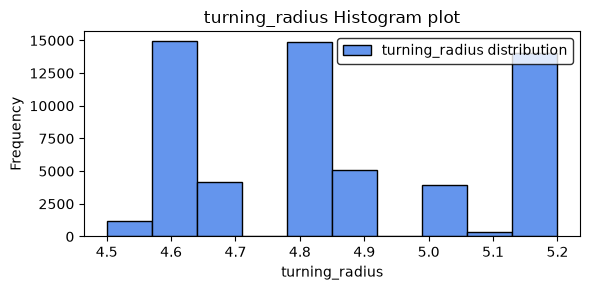

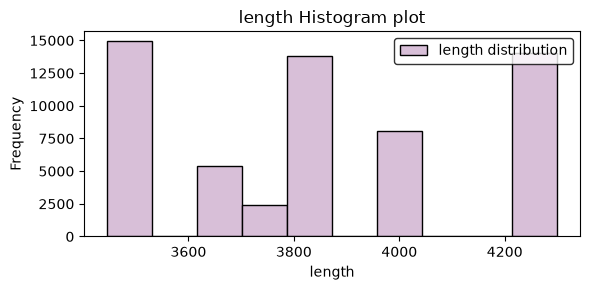

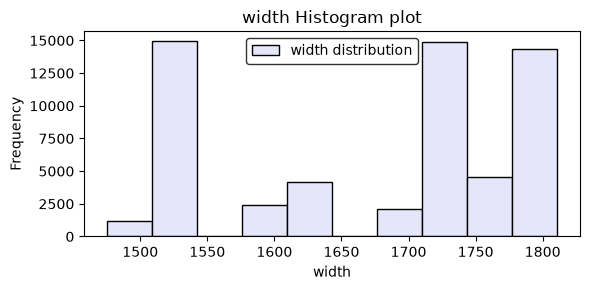

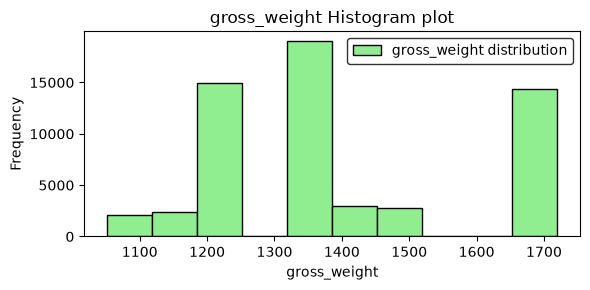

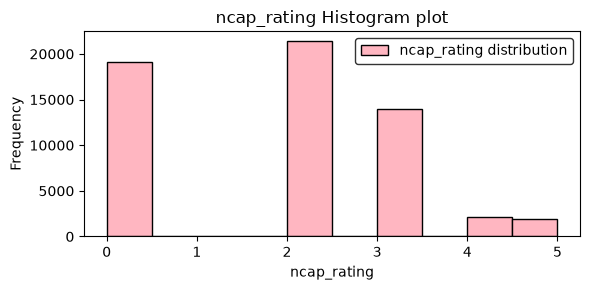


subscription_length - Outlier Analysis
Q1: 2.10
Median (Q2): 5.70
Q3: 10.40
IQR: 8.30
Lower limit: -10.35
Upper limit: 22.85
Number of outliers: 0


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


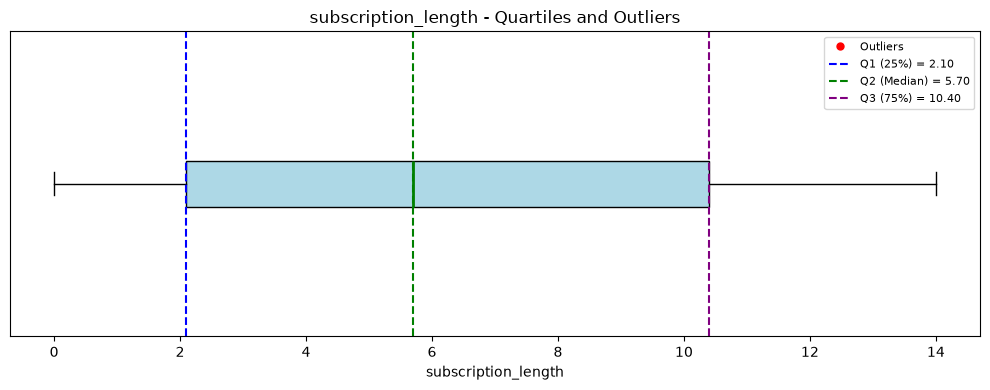

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



vehicle_age - Outlier Analysis
Q1: 0.40
Median (Q2): 1.20
Q3: 2.20
IQR: 1.80
Lower limit: -2.30
Upper limit: 4.90
Number of outliers: 269


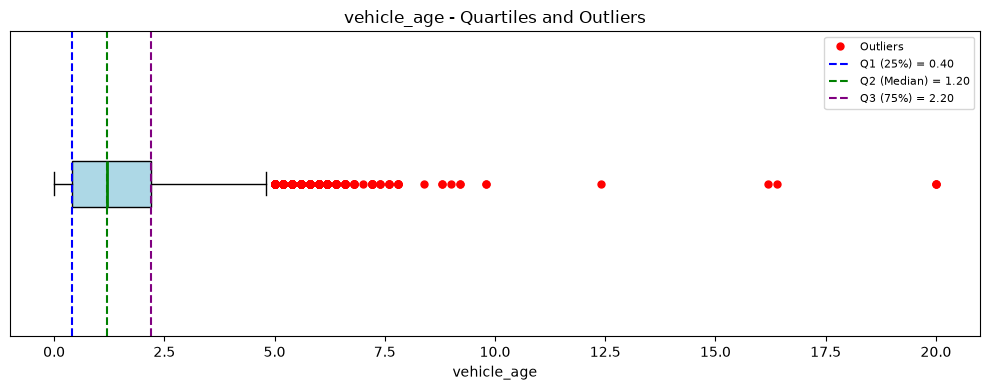

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



customer_age - Outlier Analysis
Q1: 39.00
Median (Q2): 44.00
Q3: 49.00
IQR: 10.00
Lower limit: 24.00
Upper limit: 64.00
Number of outliers: 282


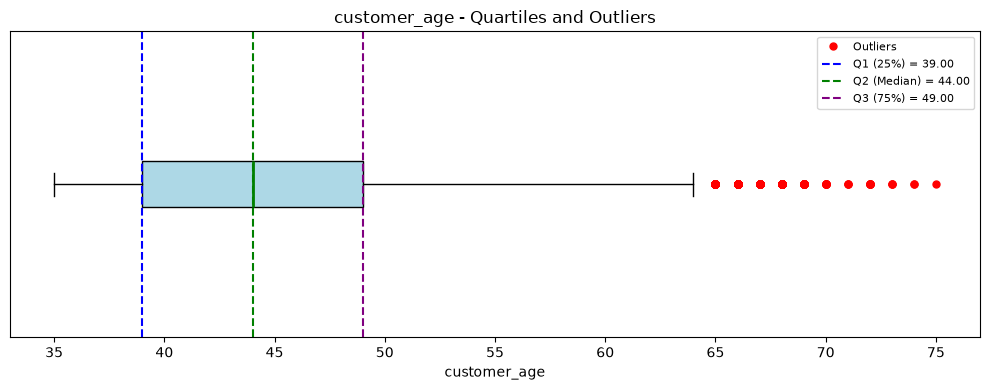

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



region_density - Outlier Analysis
Q1: 6112.00
Median (Q2): 8794.00
Q3: 27003.00
IQR: 20891.00
Lower limit: -25224.50
Upper limit: 58339.50
Number of outliers: 3647


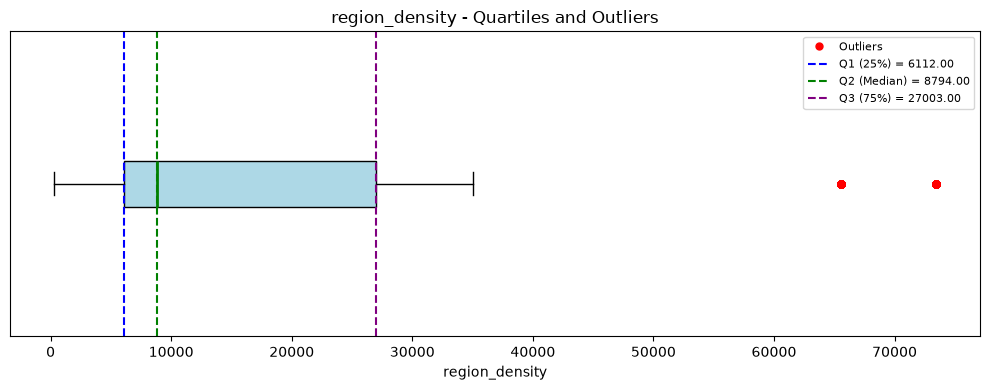


airbags - Outlier Analysis
Q1: 2.00
Median (Q2): 2.00
Q3: 6.00
IQR: 4.00
Lower limit: -4.00
Upper limit: 12.00
Number of outliers: 0


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


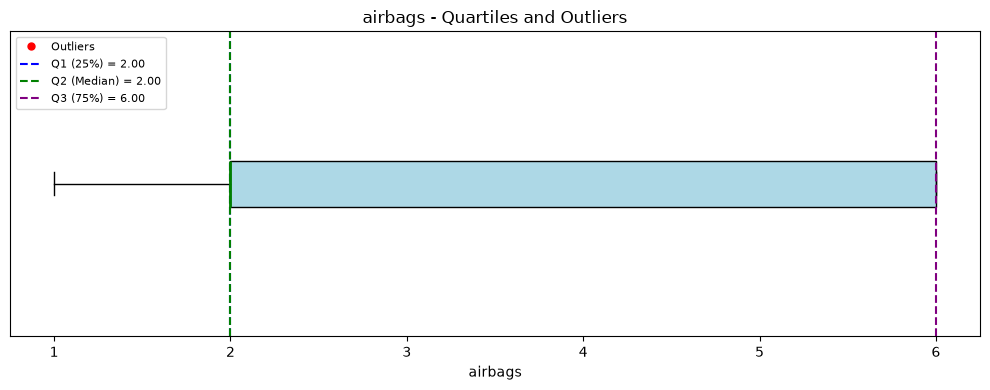

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



displacement - Outlier Analysis
Q1: 796.00
Median (Q2): 1197.00
Q3: 1493.00
IQR: 697.00
Lower limit: -249.50
Upper limit: 2538.50
Number of outliers: 0


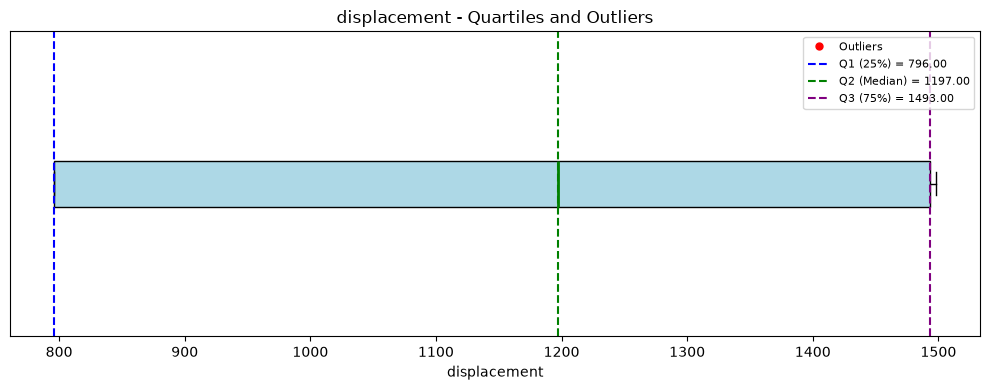

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



cylinder - Outlier Analysis
Q1: 3.00
Median (Q2): 4.00
Q3: 4.00
IQR: 1.00
Lower limit: 1.50
Upper limit: 5.50
Number of outliers: 0


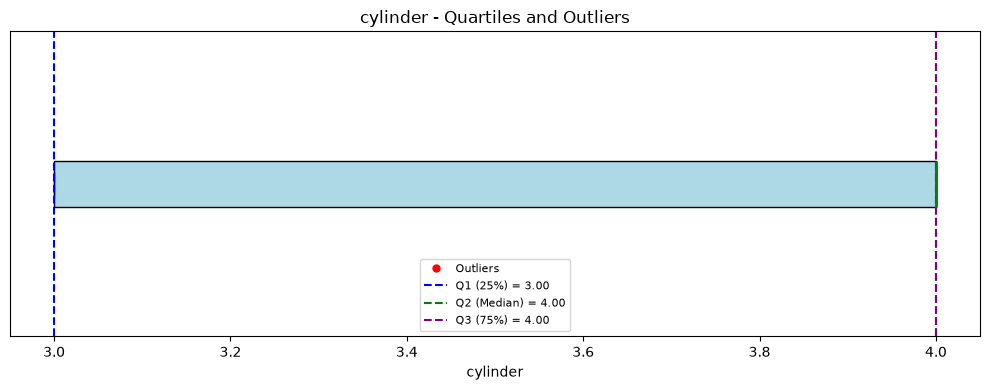

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



turning_radius - Outlier Analysis
Q1: 4.60
Median (Q2): 4.80
Q3: 5.00
IQR: 0.40
Lower limit: 4.00
Upper limit: 5.60
Number of outliers: 0


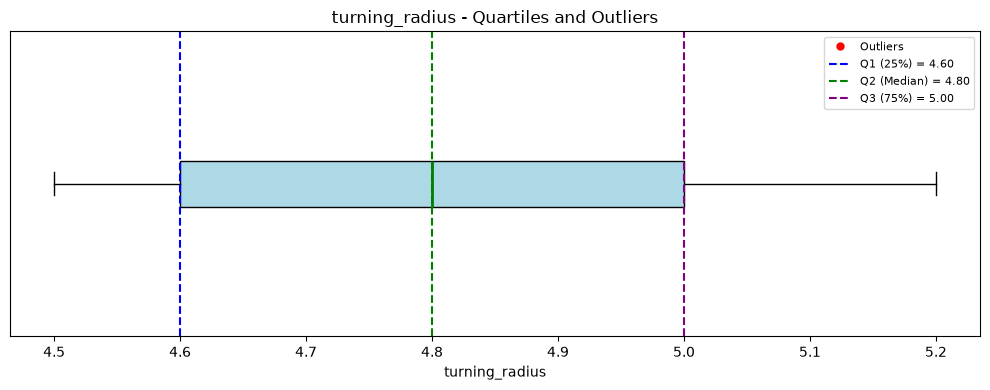


length - Outlier Analysis
Q1: 3445.00
Median (Q2): 3845.00
Q3: 3995.00
IQR: 550.00
Lower limit: 2620.00
Upper limit: 4820.00
Number of outliers: 0


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


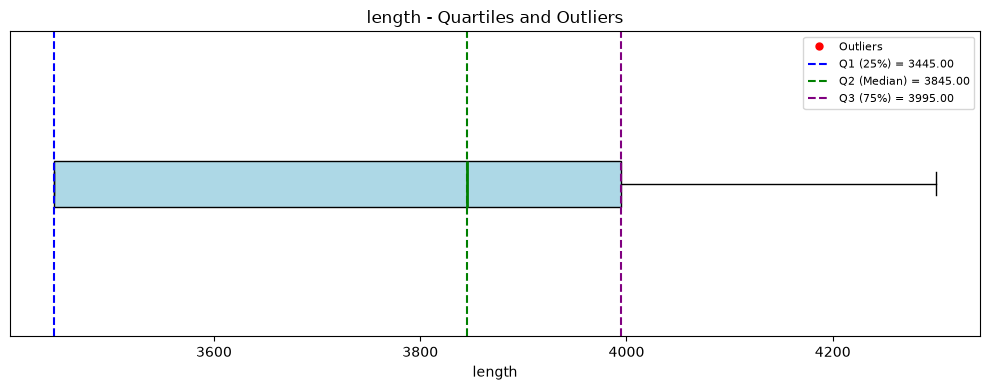

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



width - Outlier Analysis
Q1: 1515.00
Median (Q2): 1735.00
Q3: 1755.00
IQR: 240.00
Lower limit: 1155.00
Upper limit: 2115.00
Number of outliers: 0


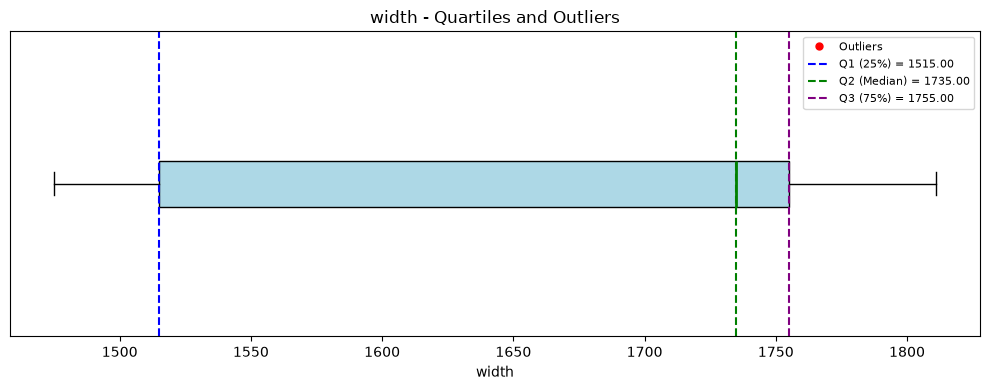


gross_weight - Outlier Analysis
Q1: 1185.00
Median (Q2): 1335.00
Q3: 1510.00
IQR: 325.00
Lower limit: 697.50
Upper limit: 1997.50
Number of outliers: 0


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


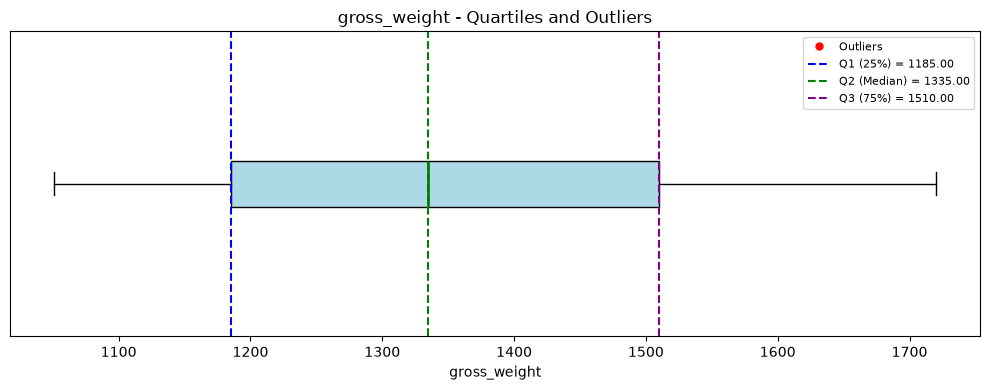

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\826576710.py:103: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(



ncap_rating - Outlier Analysis
Q1: 0.00
Median (Q2): 2.00
Q3: 3.00
IQR: 3.00
Lower limit: -4.50
Upper limit: 7.50
Number of outliers: 0


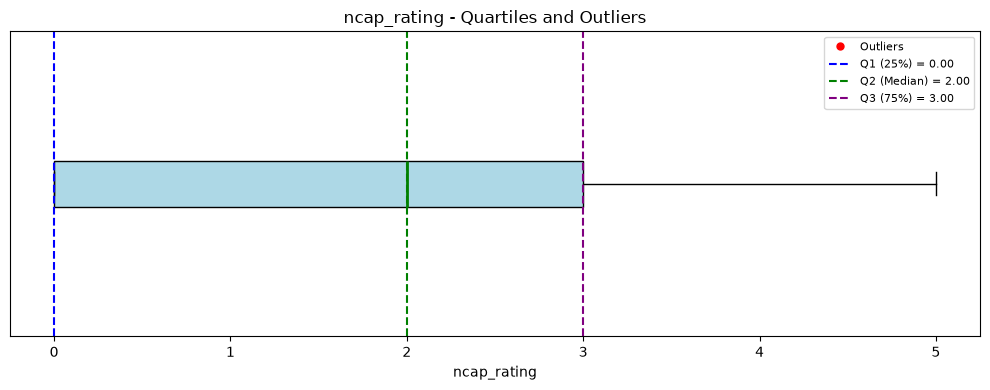

Skipping region_code: too many categories


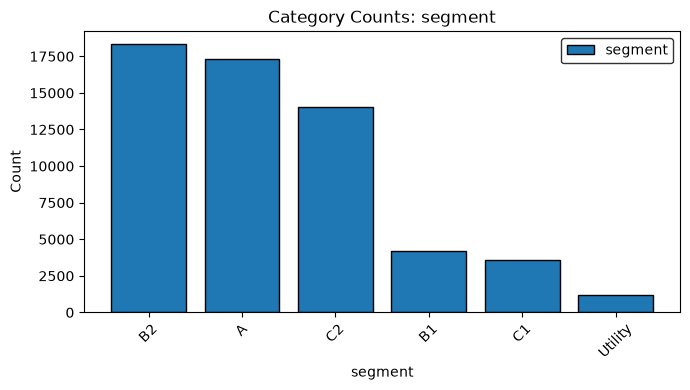

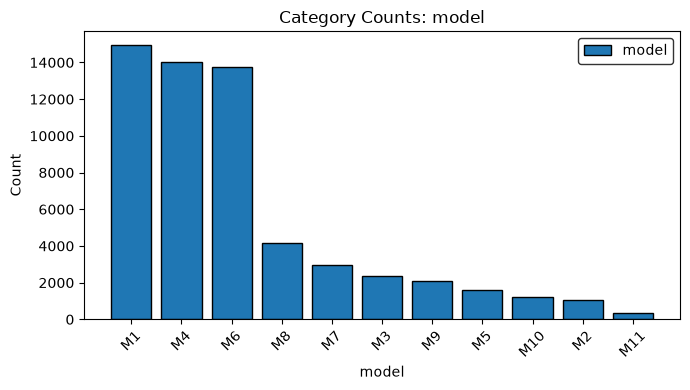

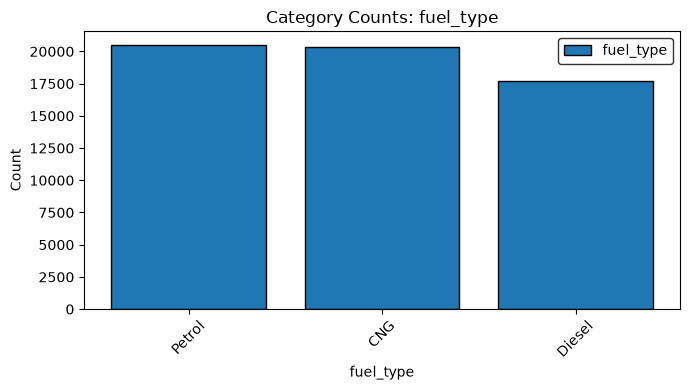

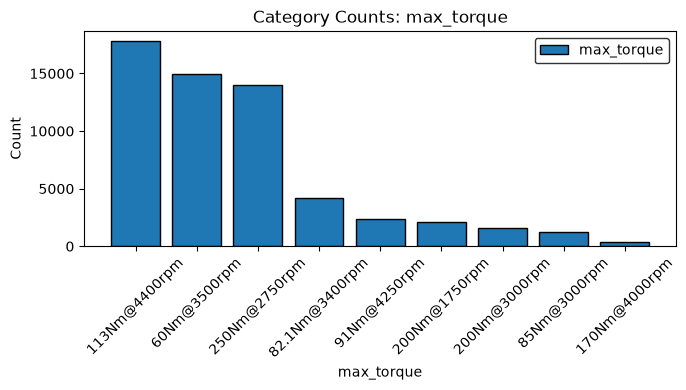

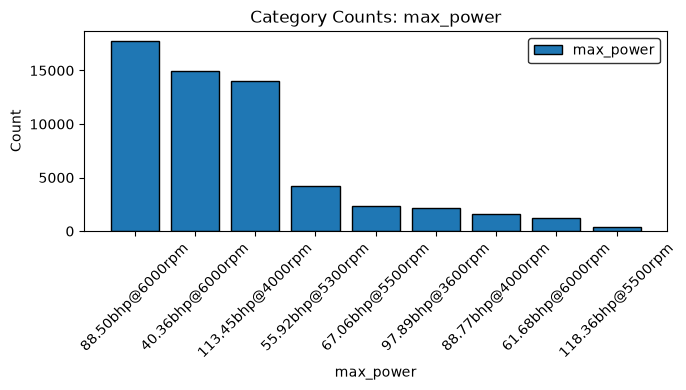

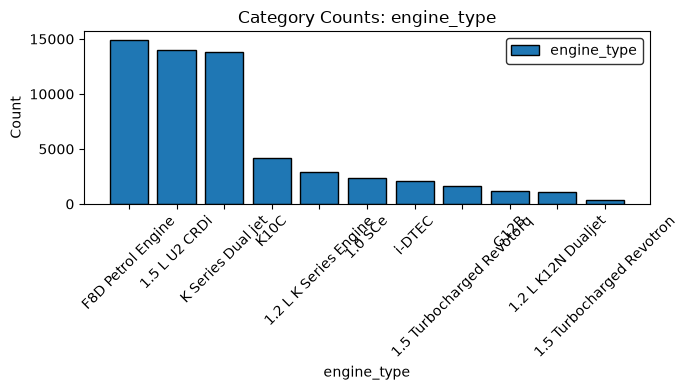

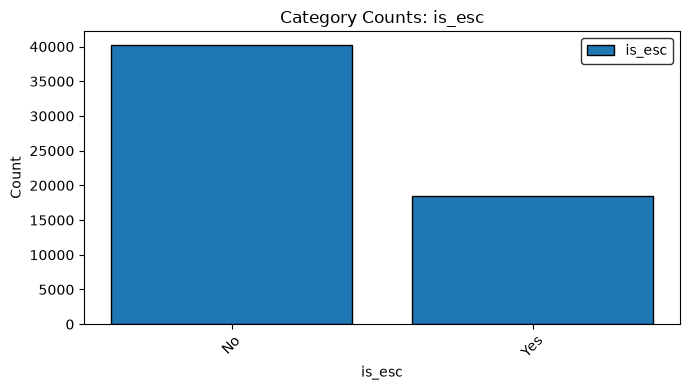

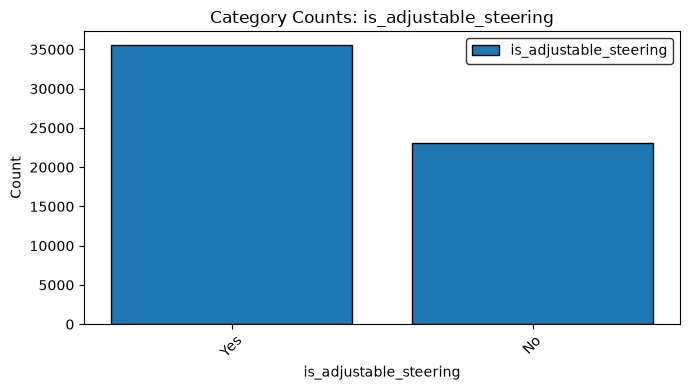

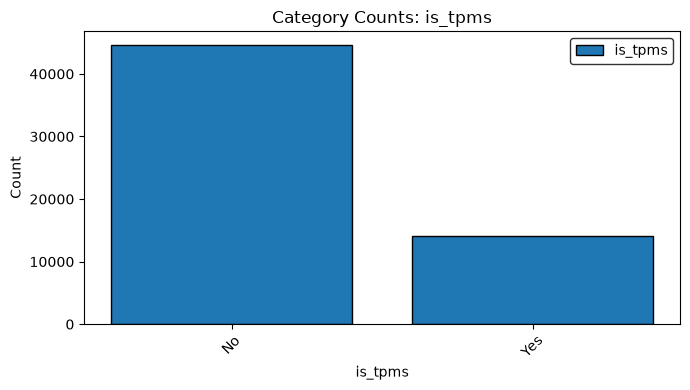

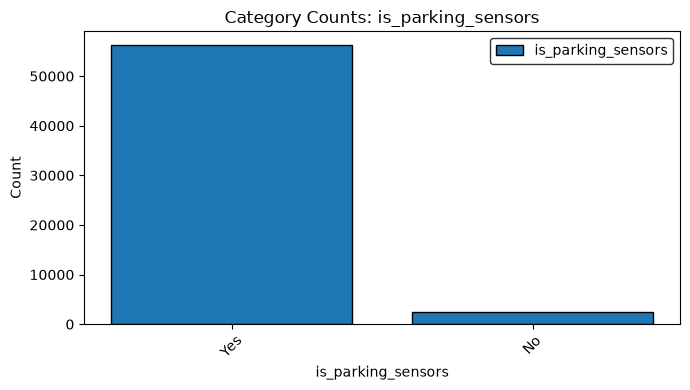

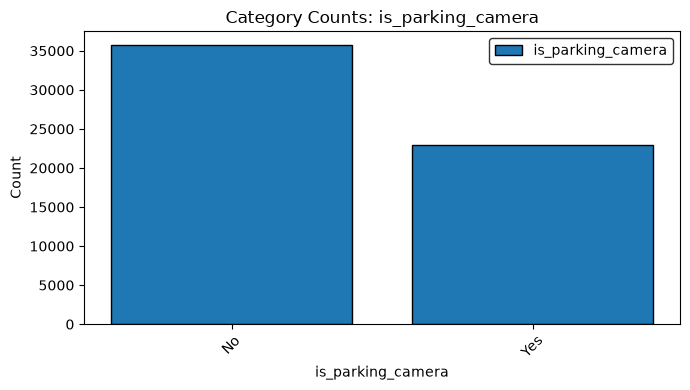

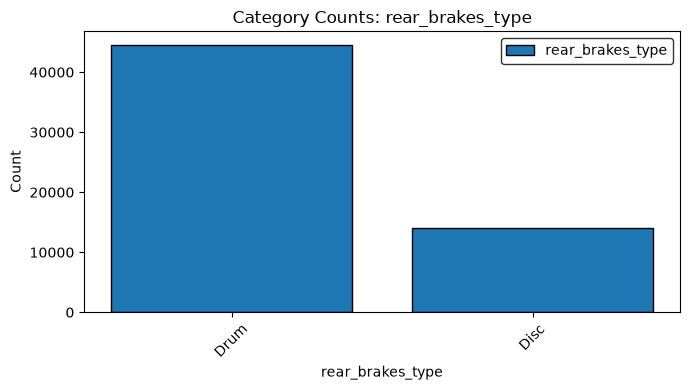

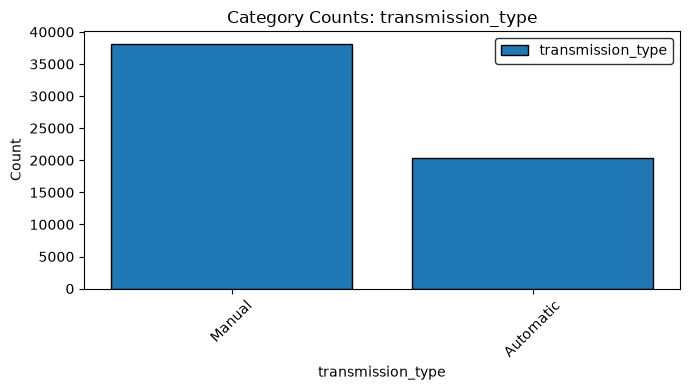

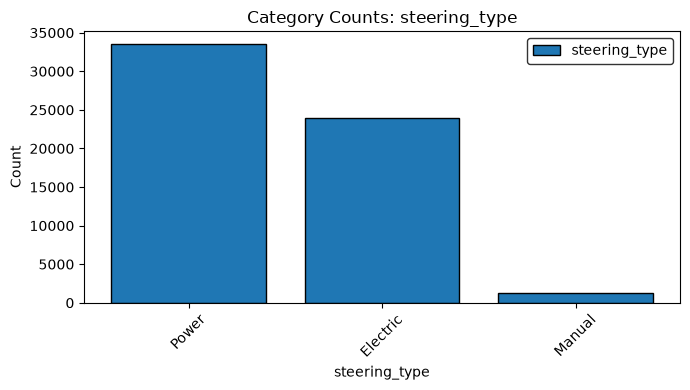

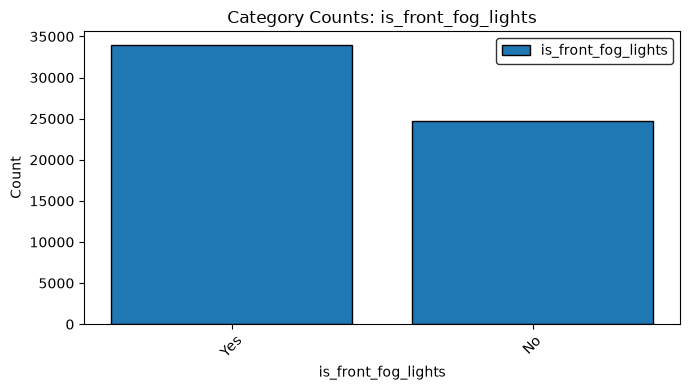

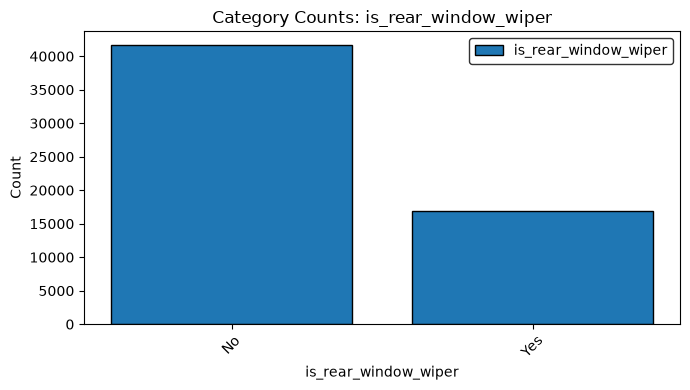

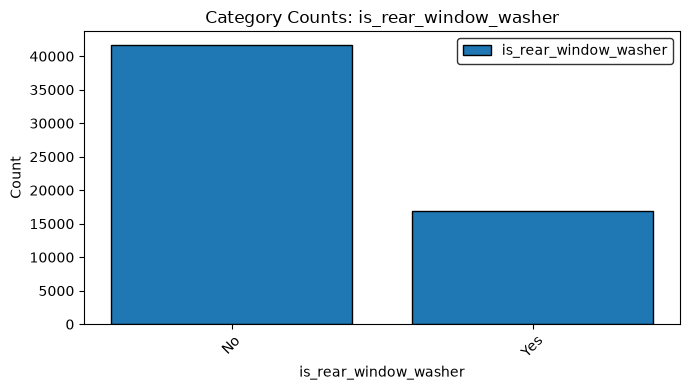

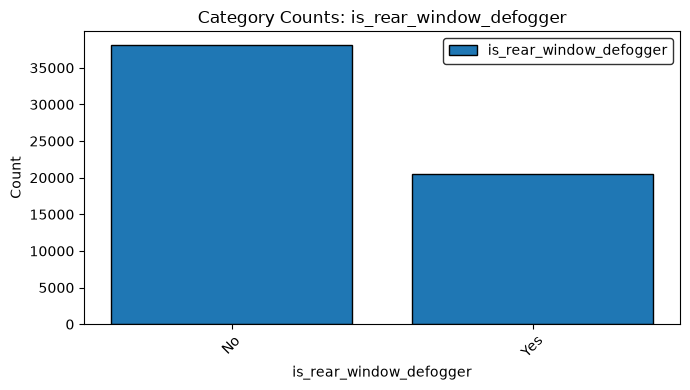

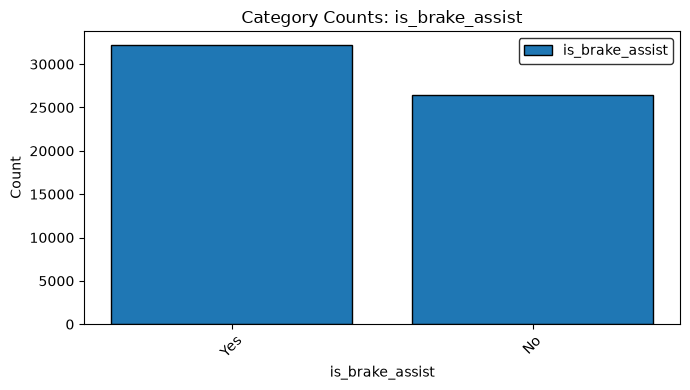

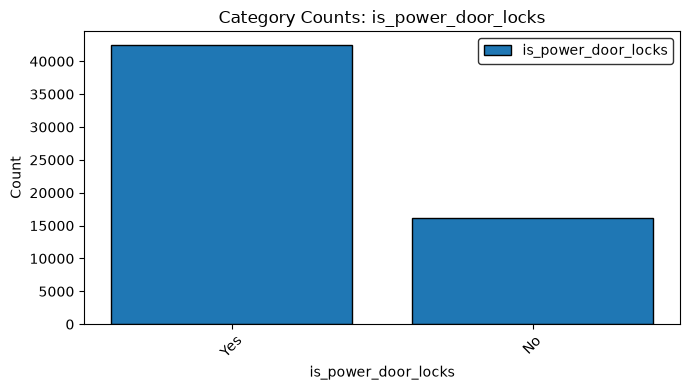

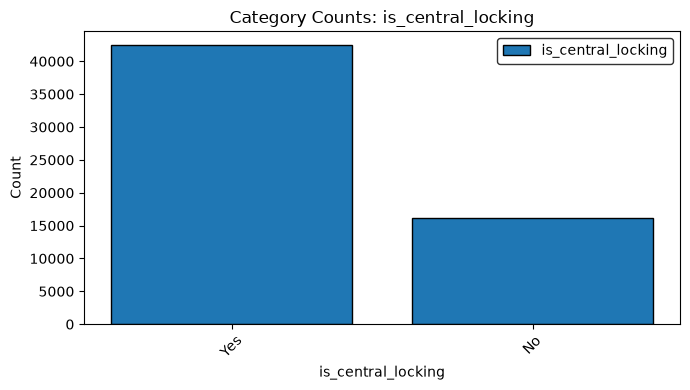

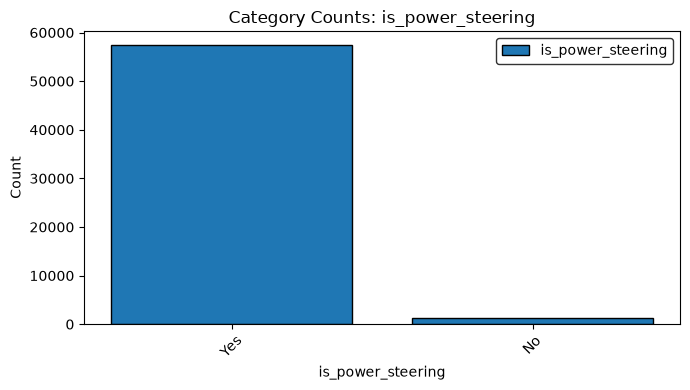

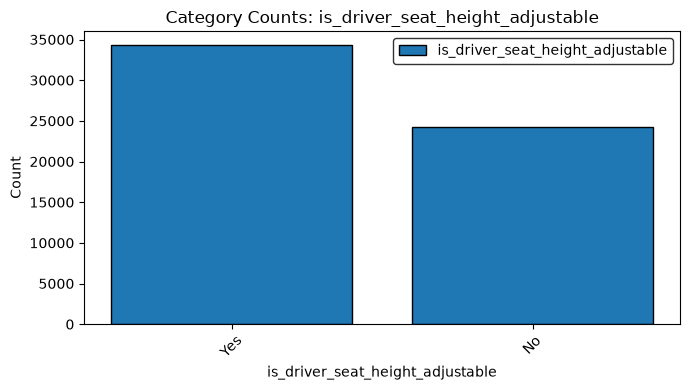

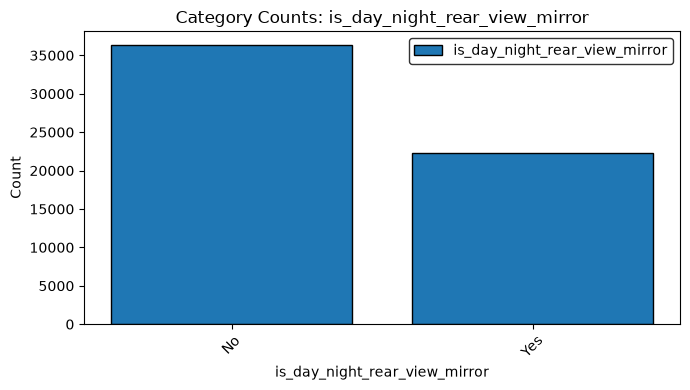

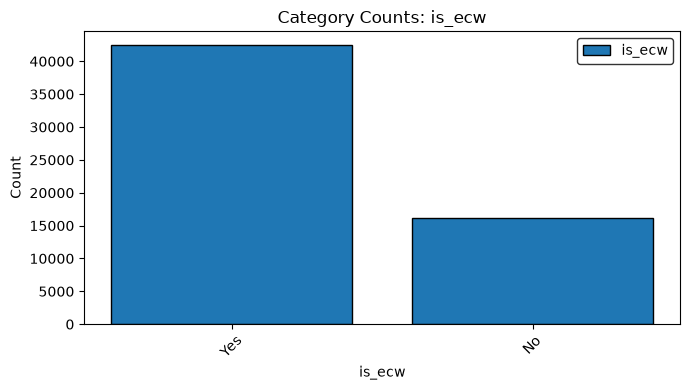

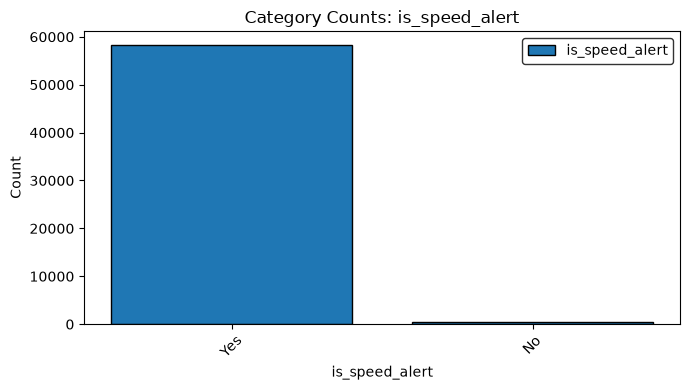

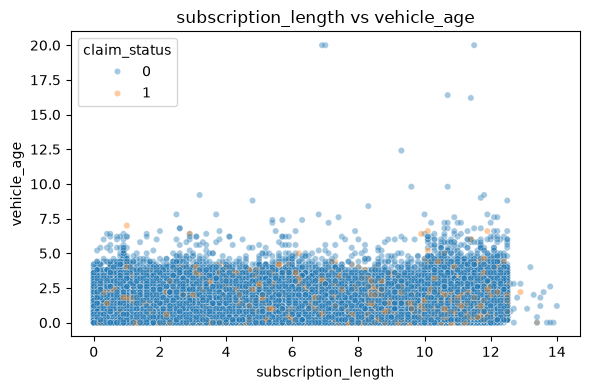

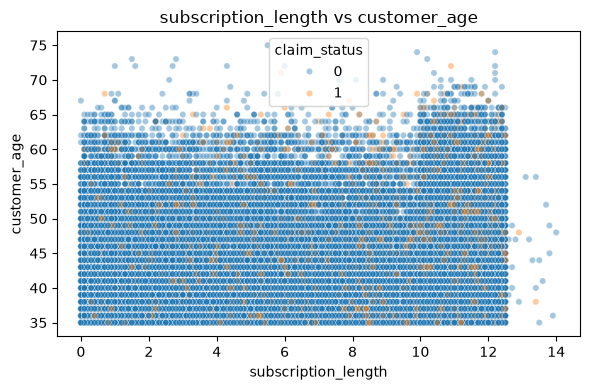

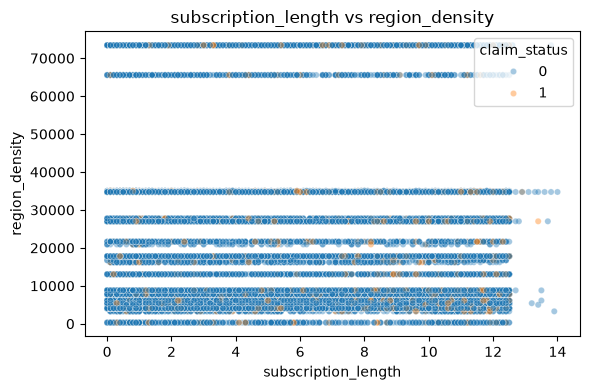

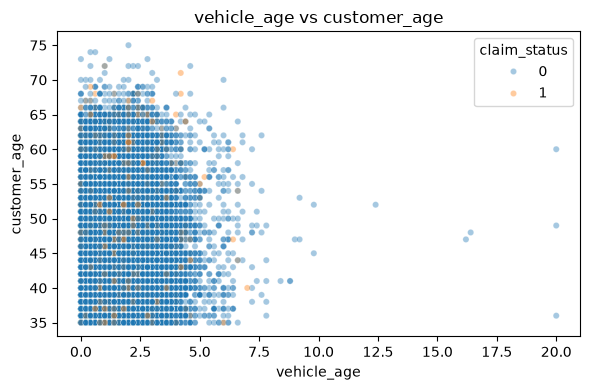

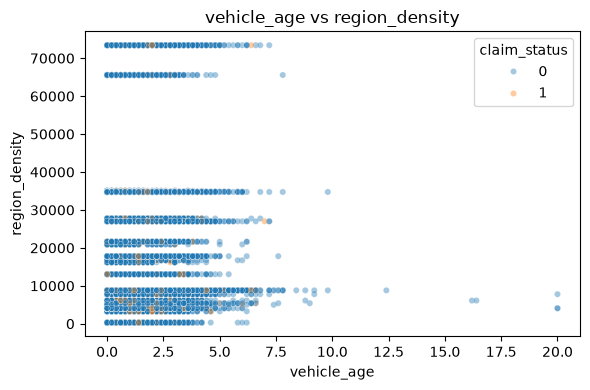

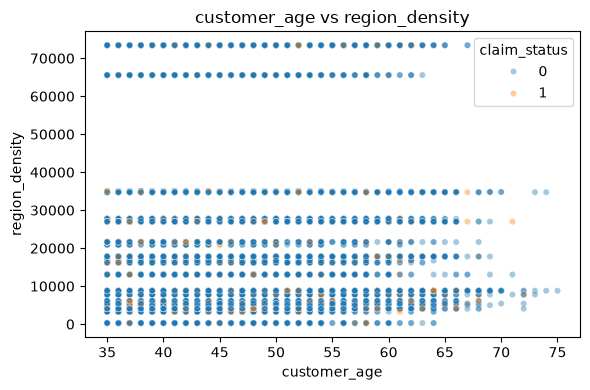

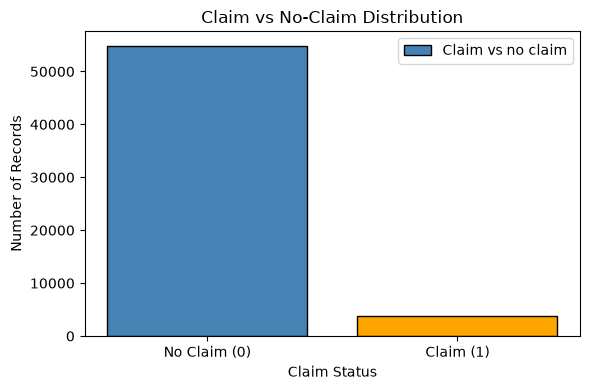


Claim Counts:
claim_status
0    54844
1     3748
Name: count, dtype: int64

Claim Percentages:
claim_status
0    93.6
1     6.4
Name: count, dtype: float64

subscription_length - No Claim
Q1: 2.00
Median (Q2): 5.60
Q3: 10.40
IQR: 8.40
Outlier count: 0

subscription_length - Claim
Q1: 4.00
Median (Q2): 8.30
Q3: 10.80
IQR: 6.80
Outlier count: 0


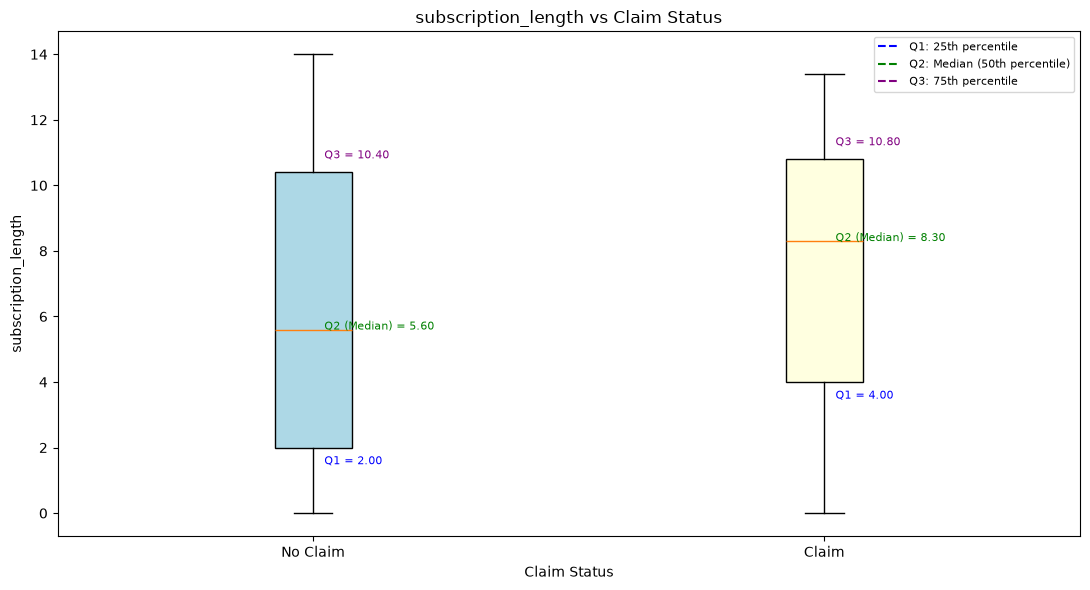


vehicle_age - No Claim
Q1: 0.40
Median (Q2): 1.20
Q3: 2.20
IQR: 1.80
Outlier count: 260

vehicle_age - Claim
Q1: 0.40
Median (Q2): 1.00
Q3: 2.00
IQR: 1.60
Outlier count: 13


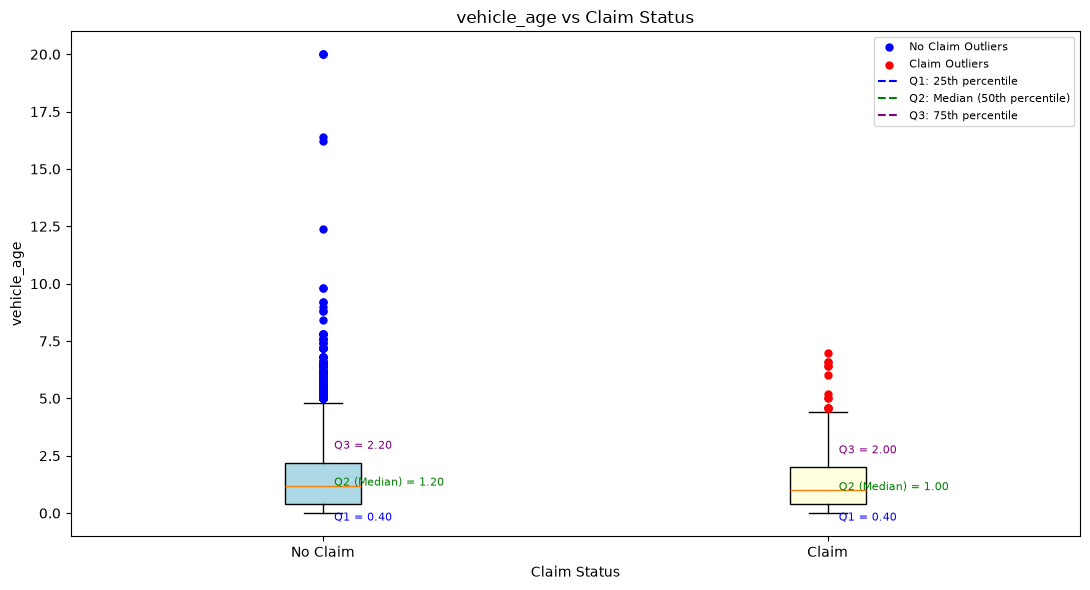


customer_age - No Claim
Q1: 39.00
Median (Q2): 44.00
Q3: 49.00
IQR: 10.00
Outlier count: 245

customer_age - Claim
Q1: 40.00
Median (Q2): 44.00
Q3: 50.00
IQR: 10.00
Outlier count: 21


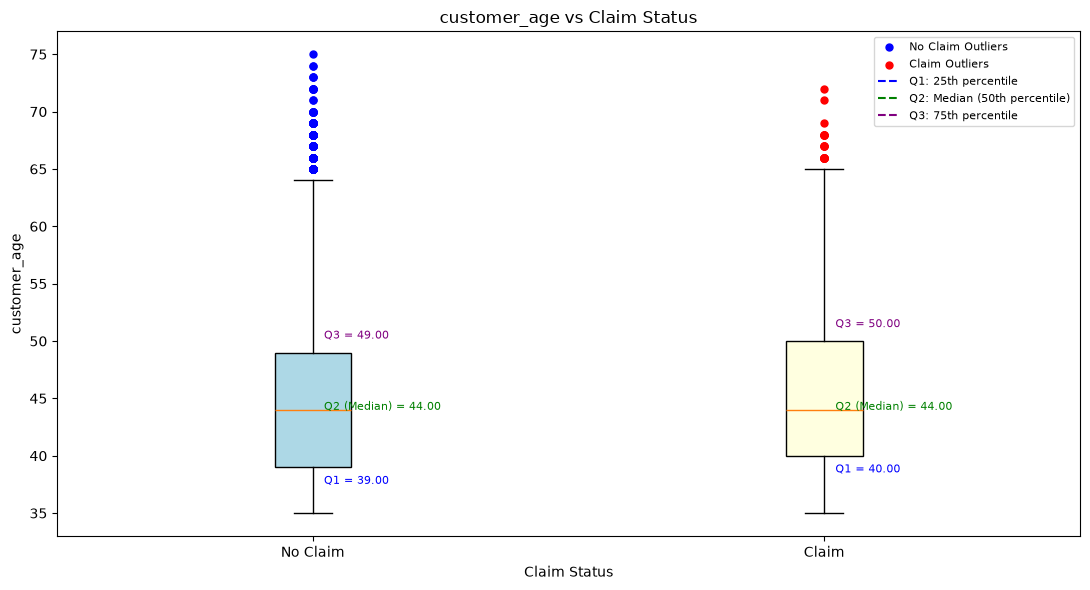


region_density - No Claim
Q1: 6112.00
Median (Q2): 8794.00
Q3: 27003.00
IQR: 20891.00
Outlier count: 3480

region_density - Claim
Q1: 6112.00
Median (Q2): 8794.00
Q3: 27003.00
IQR: 20891.00
Outlier count: 167


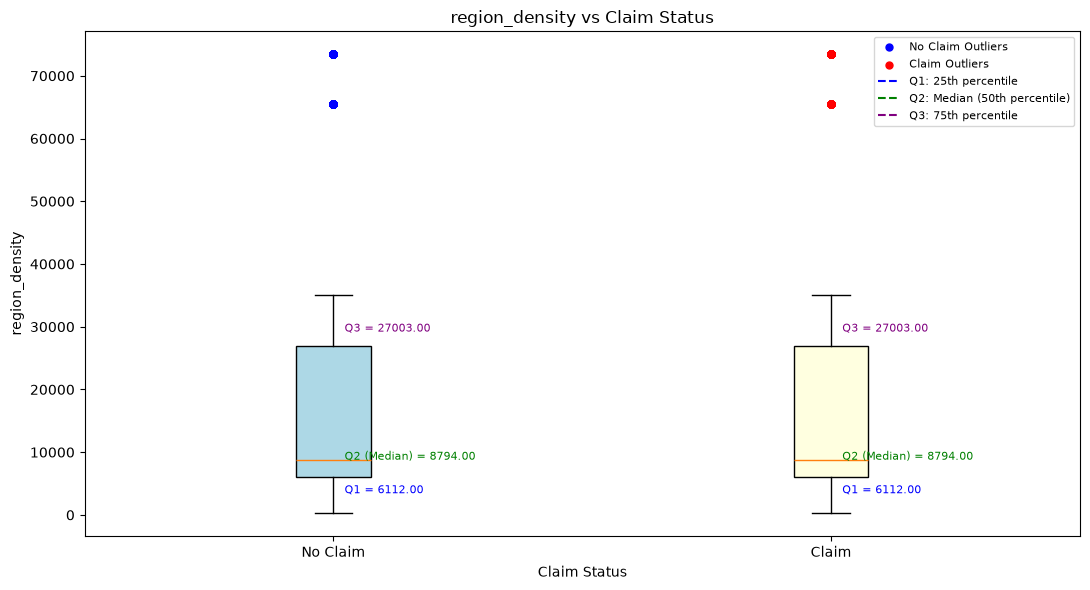


airbags - No Claim
Q1: 2.00
Median (Q2): 2.00
Q3: 6.00
IQR: 4.00
Outlier count: 0

airbags - Claim
Q1: 2.00
Median (Q2): 2.00
Q3: 6.00
IQR: 4.00
Outlier count: 0


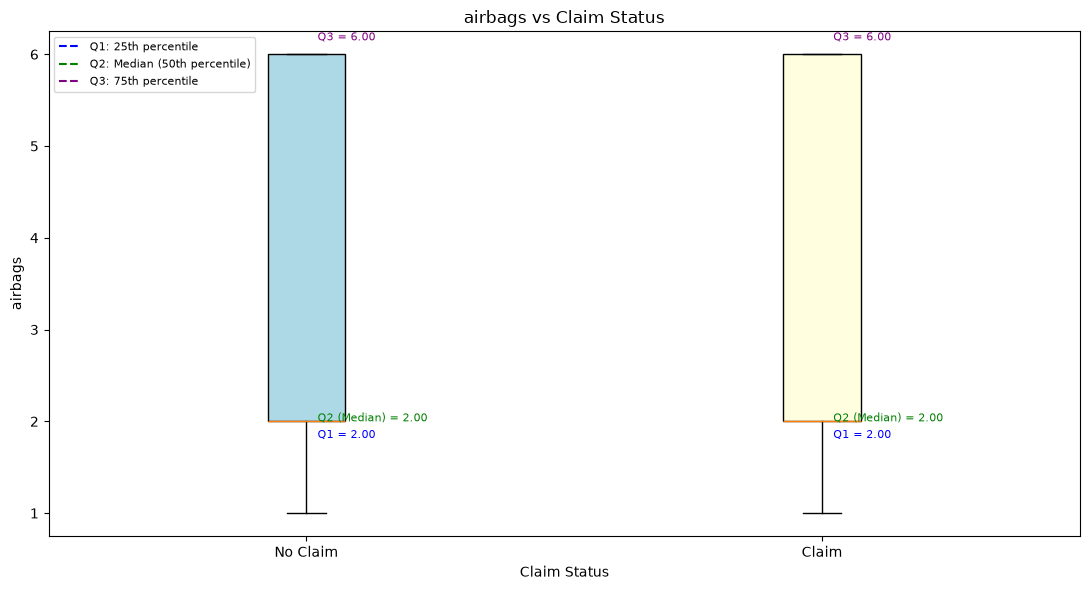


displacement - No Claim
Q1: 796.00
Median (Q2): 1197.00
Q3: 1493.00
IQR: 697.00
Outlier count: 0

displacement - Claim
Q1: 998.00
Median (Q2): 1197.00
Q3: 1493.00
IQR: 495.00
Outlier count: 0


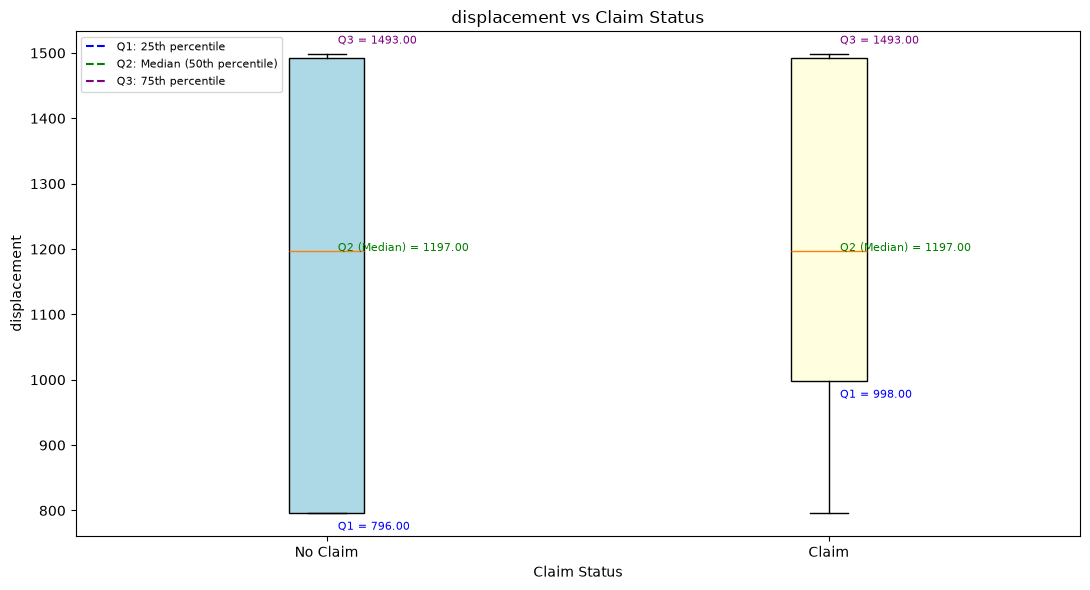


cylinder - No Claim
Q1: 3.00
Median (Q2): 4.00
Q3: 4.00
IQR: 1.00
Outlier count: 0

cylinder - Claim
Q1: 3.00
Median (Q2): 4.00
Q3: 4.00
IQR: 1.00
Outlier count: 0


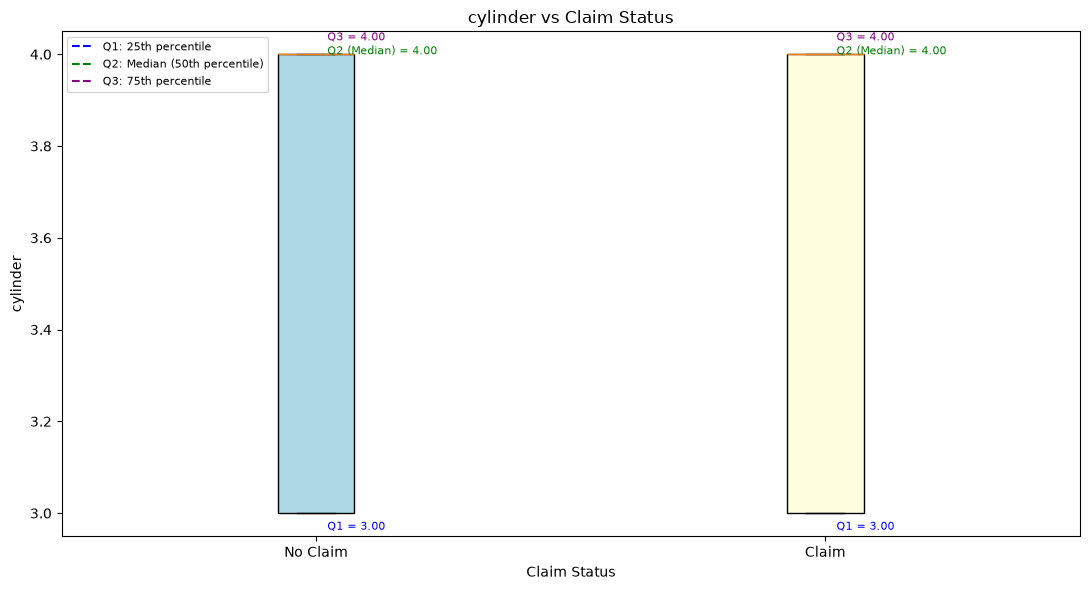


turning_radius - No Claim
Q1: 4.60
Median (Q2): 4.80
Q3: 5.00
IQR: 0.40
Outlier count: 0

turning_radius - Claim
Q1: 4.60
Median (Q2): 4.80
Q3: 5.00
IQR: 0.40
Outlier count: 0


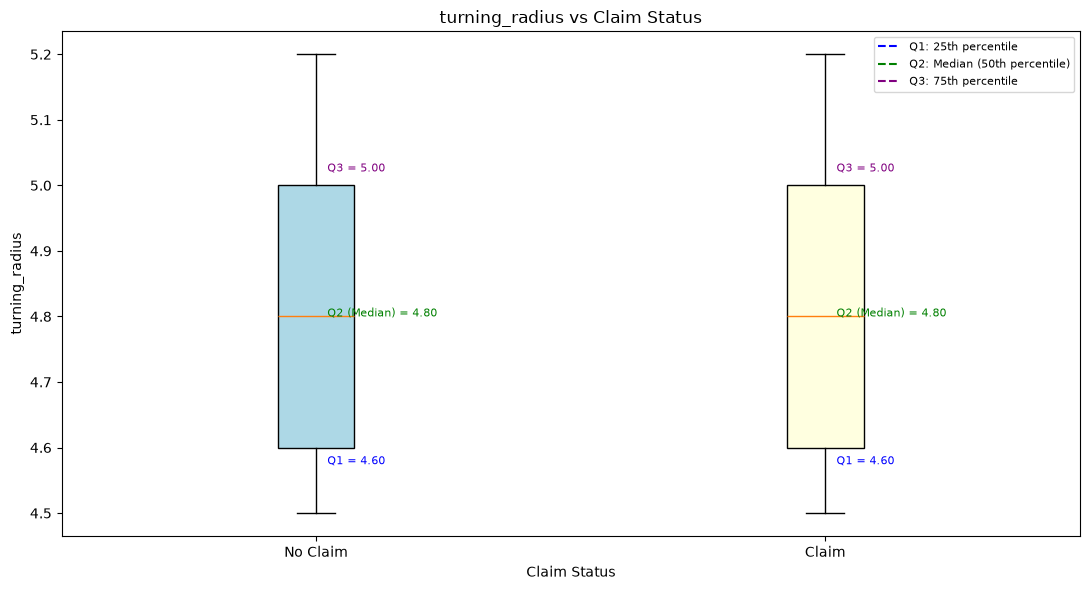


length - No Claim
Q1: 3445.00
Median (Q2): 3845.00
Q3: 3995.00
IQR: 550.00
Outlier count: 0

length - Claim
Q1: 3655.00
Median (Q2): 3845.00
Q3: 3995.00
IQR: 340.00
Outlier count: 0


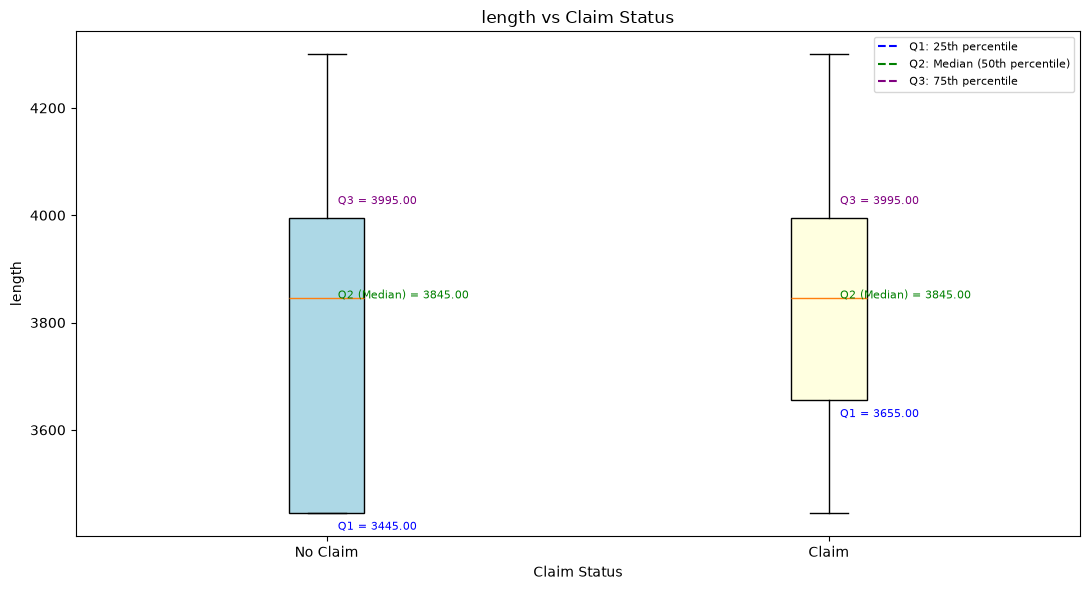


width - No Claim
Q1: 1515.00
Median (Q2): 1735.00
Q3: 1755.00
IQR: 240.00
Outlier count: 0

width - Claim
Q1: 1515.00
Median (Q2): 1735.00
Q3: 1755.00
IQR: 240.00
Outlier count: 0


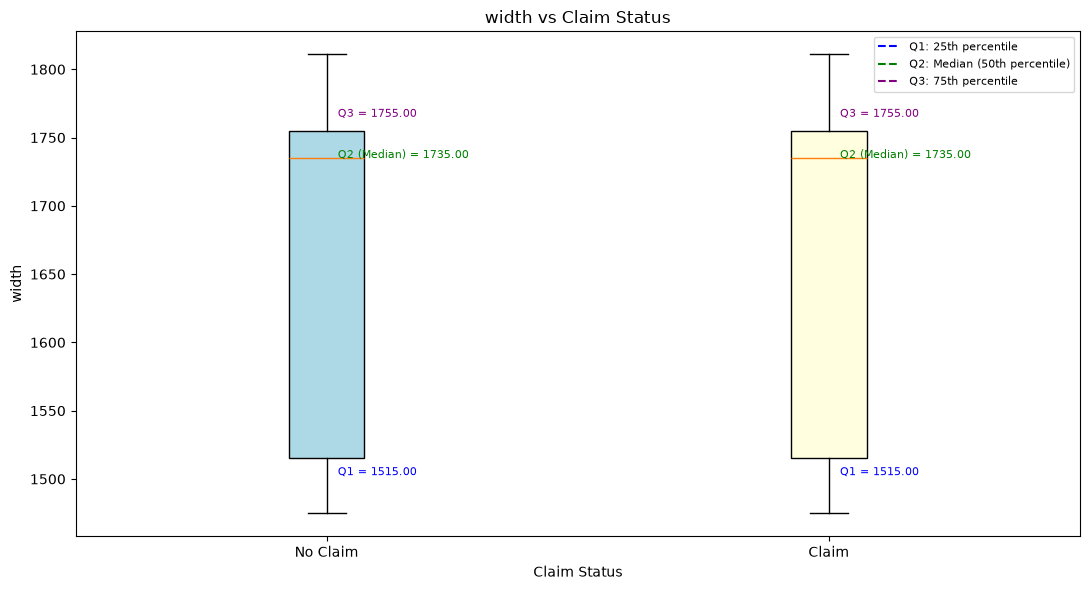


gross_weight - No Claim
Q1: 1185.00
Median (Q2): 1335.00
Q3: 1510.00
IQR: 325.00
Outlier count: 0

gross_weight - Claim
Q1: 1185.00
Median (Q2): 1335.00
Q3: 1510.00
IQR: 325.00
Outlier count: 0


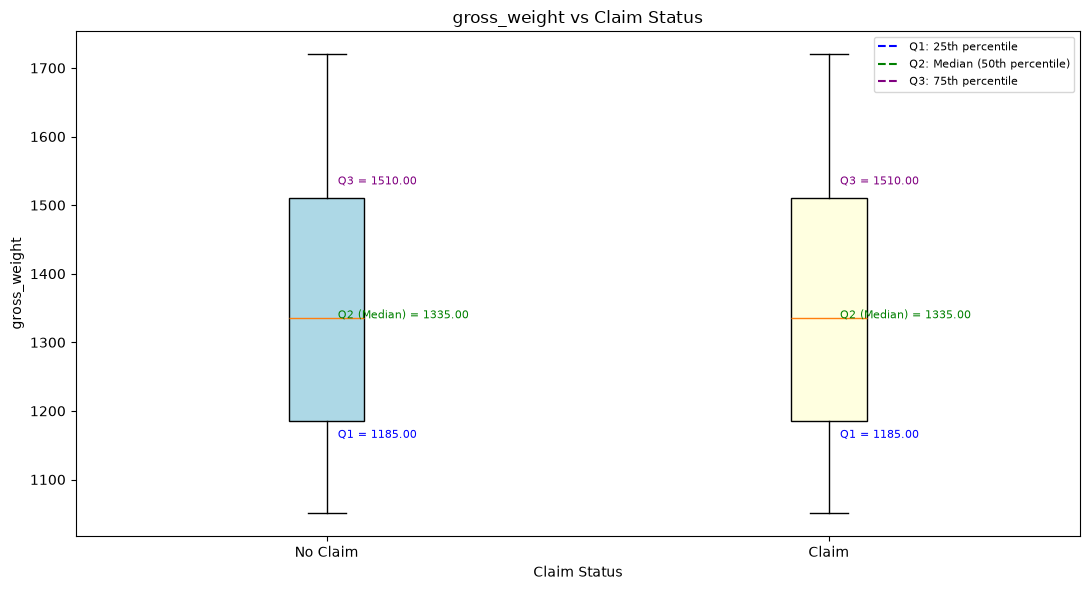


ncap_rating - No Claim
Q1: 0.00
Median (Q2): 2.00
Q3: 3.00
IQR: 3.00
Outlier count: 0

ncap_rating - Claim
Q1: 0.00
Median (Q2): 2.00
Q3: 3.00
IQR: 3.00
Outlier count: 0


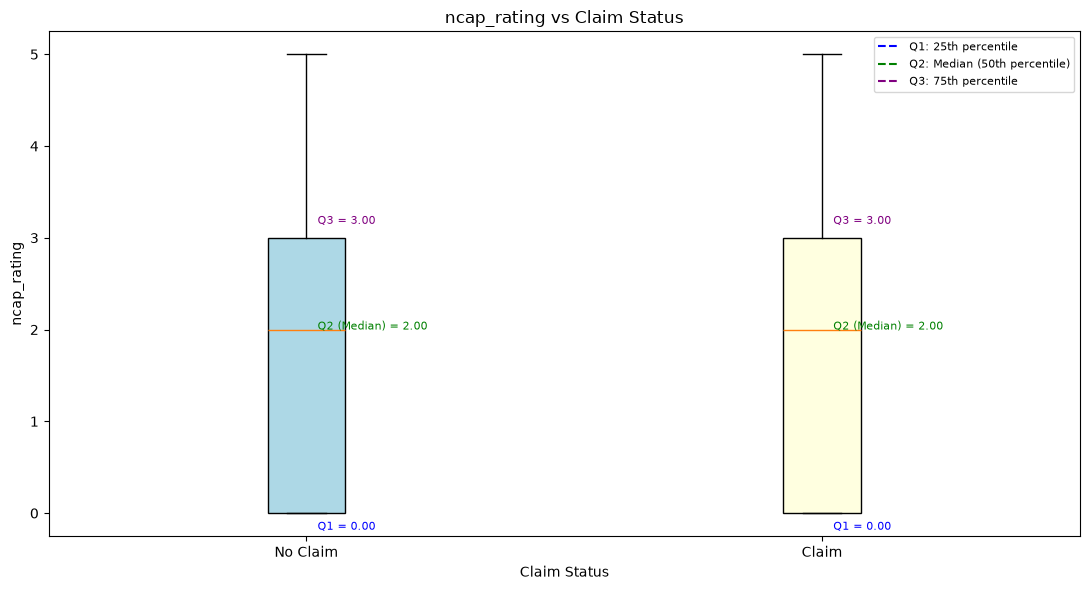

In [110]:
# Exploratory Data Analysis  means exploring the dataset using statistics and visualizations before building the ML model.

# 1.Univariate Analysis Univariate means analyzing one variable at a time
# Numerical variables
# Categorical variables
# Histograms
# Box plots
# Bar charts / Count plots


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("_" * 60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("_" * 60)

target = "claim_status"

# 1. SELECTING NUMERICAL AND CATEGORICAL COLUMNS

numerical_cols = (
    Insurance_df.select_dtypes(include=np.number)
    .columns.drop(target, errors="ignore")
    .tolist()
)

categorical_cols = (
    Insurance_df.select_dtypes(
        include=["object", "category", "bool"]
    )
    .columns.drop("policy_id", errors="ignore")
    .tolist()
)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

print(len(numerical_cols))


# 12 light colors for histograms

colors_list = [
    "cyan",
    "#58D68D",
    "skyblue",
    "powderblue",
    "paleturquoise",
    "#F5B041",
    "#BB8FCE",
    "cornflowerblue",
    "thistle",
    "lavender",
    "lightgreen",
    "lightpink"
]

# 2. UNIVARIATE ANALYSIS - HISTOGRAMS
count = 0
for col in numerical_cols:

    data = Insurance_df[col].dropna()

    plt.figure(figsize=(6, 3))
    plt.hist(data, bins=10, edgecolor="black", label=f'{col} distribution', color=colors_list[count])
    count += 1

    plt.title(f"{col} Histogram plot")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.legend(edgecolor='black')
    plt.show()
    plt.close()


# 3. UNIVARIATE ANALYSIS - BOX PLOTS


for col in numerical_cols:

    data = Insurance_df[col].dropna()

    if data.empty:
        continue

    q1, median, q3 = np.percentile(data, [25, 50, 75])

    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = data[
        (data < lower_limit) | (data > upper_limit)
    ]

    plt.figure(figsize=(10, 4))

    plt.boxplot(
        data,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue"),
        medianprops=dict(color="green", linewidth=2),
        flierprops=dict(
            marker="o",
            markerfacecolor="red",
            markeredgecolor="red",
            markersize=5,
            label="Outliers"
        )
    )

    # Quartile reference lines
    plt.axvline(
        q1, color="blue", linestyle="--",
        label=f"Q1 (25%) = {q1:.2f}"
    )

    plt.axvline(
        median, color="green", linestyle="--",
        label=f"Q2 (Median) = {median:.2f}"
    )

    plt.axvline(
        q3, color="purple", linestyle="--",
        label=f"Q3 (75%) = {q3:.2f}"
    )

    print(f"\n{col} - Outlier Analysis")
    print(f"Q1: {q1:.2f}")
    print(f"Median (Q2): {median:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower limit: {lower_limit:.2f}")
    print(f"Upper limit: {upper_limit:.2f}")
    print(f"Number of outliers: {len(outliers)}")

    plt.title(f"{col} - Quartiles and Outliers")
    plt.xlabel(col)
    plt.yticks([])
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close()

# 4. UNIVARIATE ANALYSIS - CATEGORICAL DISTRIBUTIONS

for col in categorical_cols:

    # Avoid plotting columns with too many categories
    if Insurance_df[col].nunique(dropna=False) > 20:
        print(f"Skipping {col}: too many categories")
        continue

    counts = Insurance_df[col].value_counts(dropna=False)

    plt.figure(figsize=(7, 4))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        edgecolor="black", label=col
    )

    plt.title(f"Category Counts: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(edgecolor='black')
    plt.tight_layout()
    plt.show()
    plt.close()

# 5. NUMERICAL vs NUMERICAL - SCATTER PLOTS
# Limit to the first four numerical features
features = numerical_cols[:4]

for i in range(len(features)):
    for j in range(i + 1, len(features)):

        plt.figure(figsize=(6, 4))

        sns.scatterplot(
            data=Insurance_df,
            x=features[i],
            y=features[j],
            hue=target,
            alpha=0.4,
            s=20
        )

        plt.title(f"{features[i]} vs {features[j]}")
        plt.tight_layout()
        plt.show()
        plt.close()

# 6. CLAIM vs NO-CLAIM DISTRIBUTION

claim_counts = (
    Insurance_df[target]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

claim_labels = ["No Claim (0)", "Claim (1)"]

plt.figure(figsize=(6, 4))

plt.bar(
    claim_labels,
    claim_counts.values,
    color=["steelblue", "orange"],
    edgecolor="black", label='Claim vs no claim'
)

plt.title("Claim vs No-Claim Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.legend()
plt.show()
plt.close()

print("\nClaim Counts:")
print(claim_counts)

print("\nClaim Percentages:")
print(
    (claim_counts / len(Insurance_df) * 100).round(2)
)

# 7. NUMERICAL FEATURES vs CLAIM STATUS

for col in numerical_cols:

    no_claim = Insurance_df.loc[
        Insurance_df[target] == 0, col
    ].dropna()

    claim = Insurance_df.loc[
        Insurance_df[target] == 1, col
    ].dropna()

    if no_claim.empty or claim.empty:
        continue

    groups = [no_claim, claim]
    group_names = ["No Claim", "Claim"]
    outlier_colors = ["blue", "red"]

    plt.figure(figsize=(11, 6))

    box = plt.boxplot(
        groups,
        tick_labels=group_names,
        patch_artist=True,
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="gray",
            markeredgecolor="gray"
        )
    )

    # Color the two boxes
    box["boxes"][0].set_facecolor("lightblue")
    box["boxes"][1].set_facecolor("lightyellow")

    # Quartile labels and outlier detection
    for i, data in enumerate(groups, start=1):

        q1, median, q3 = np.percentile(
            data, [25, 50, 75]
        )

        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outliers = data[
            (data < lower_limit) |
            (data > upper_limit)
        ]

        # Offset labels to reduce overlap
        plt.annotate(
            f"Q1 = {q1:.2f}",
            xy=(i, q1),
            xytext=(8, -12),
            textcoords="offset points",
            color="blue",
            fontsize=8
        )

        plt.annotate(
            f"Q2 (Median) = {median:.2f}",
            xy=(i, median),
            xytext=(8, 0),
            textcoords="offset points",
            color="green",
            fontsize=8
        )

        plt.annotate(
            f"Q3 = {q3:.2f}",
            xy=(i, q3),
            xytext=(8, 10),
            textcoords="offset points",
            color="purple",
            fontsize=8
        )

        # Overlay colored outliers
        if len(outliers) > 0:

            plt.scatter(
                np.full(len(outliers), i),
                outliers,
                color=outlier_colors[i - 1],
                s=25,
                label=f"{group_names[i - 1]} Outliers",
                zorder=3
            )

        print(f"\n{col} - {group_names[i - 1]}")
        print(f"Q1: {q1:.2f}")
        print(f"Median (Q2): {median:.2f}")
        print(f"Q3: {q3:.2f}")
        print(f"IQR: {iqr:.2f}")
        print(f"Outlier count: {len(outliers)}")

    # Legend for quartile definitions
    plt.plot(
        [], [], color="blue", linestyle="--",
        label="Q1: 25th percentile"
    )

    plt.plot(
        [], [], color="green", linestyle="--",
        label="Q2: Median (50th percentile)"
    )

    plt.plot(
        [], [], color="purple", linestyle="--",
        label="Q3: 75th percentile"
    )

    plt.title(f"{col} vs Claim Status")
    plt.xlabel("Claim Status")
    plt.ylabel(col)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close()



C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\3272002779.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = Insurance_df.select_dtypes(


Numerical columns: ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'airbags', 'displacement', 'cylinder', 'turning_radius', 'length', 'width', 'gross_weight', 'ncap_rating']
Categorical columns:       region_code segment model fuel_type     max_torque          max_power  \
0              C8      C2    M4    Diesel  250Nm@2750rpm  113.45bhp@4000rpm   
1              C2      C1    M9    Diesel  200Nm@1750rpm   97.89bhp@3600rpm   
2              C8      C2    M4    Diesel  250Nm@2750rpm  113.45bhp@4000rpm   
3             C10       A    M1       CNG   60Nm@3500rpm   40.36bhp@6000rpm   
4             C13      B2    M5    Diesel  200Nm@3000rpm   88.77bhp@4000rpm   
...           ...     ...   ...       ...            ...                ...   
58587          C5      B2    M6    Petrol  113Nm@4400rpm   88.50bhp@6000rpm   
58588          C3      C2    M4    Diesel  250Nm@2750rpm  113.45bhp@4000rpm   
58589          C8      B2    M6    Petrol  113Nm@4400rpm   88.50bhp@6

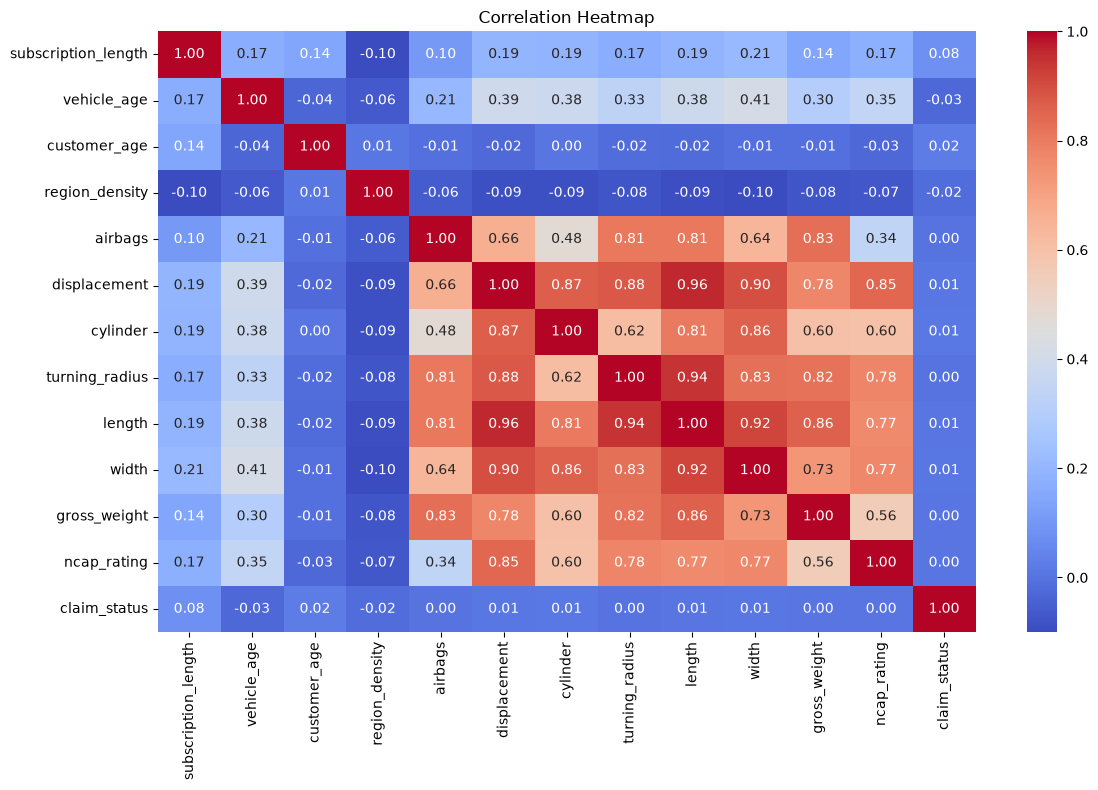

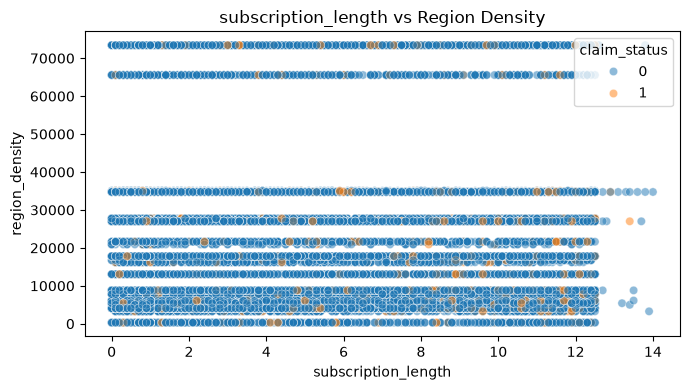

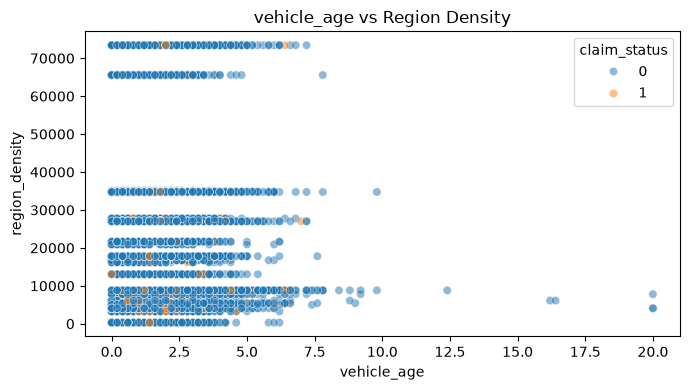

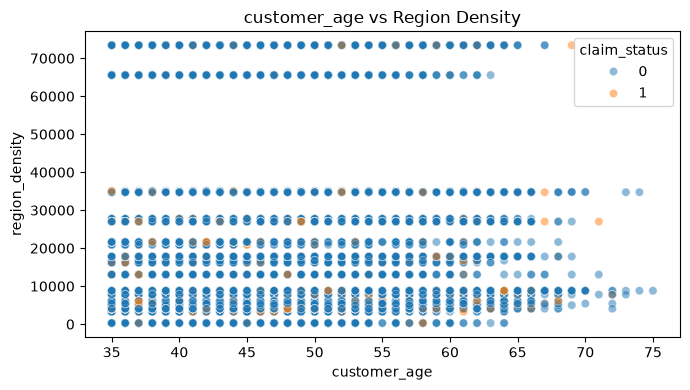

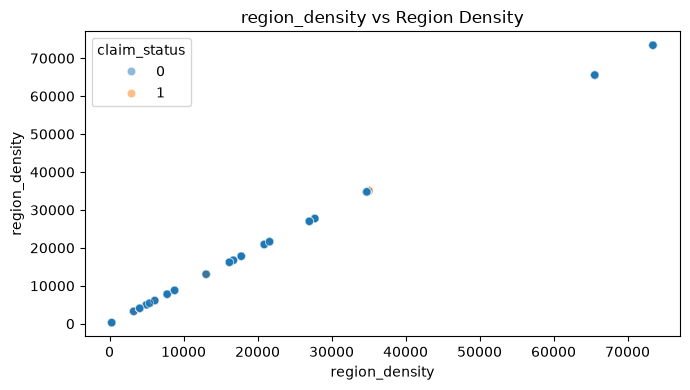

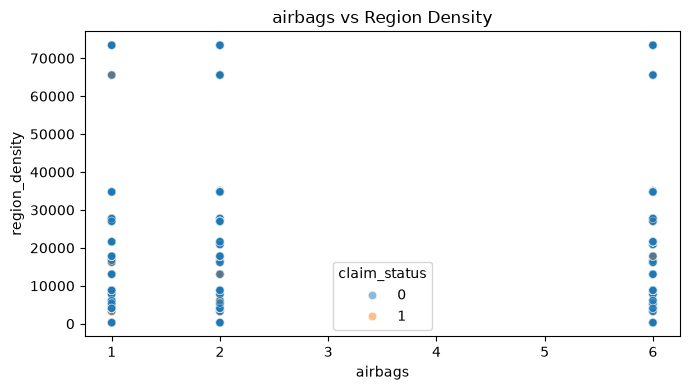

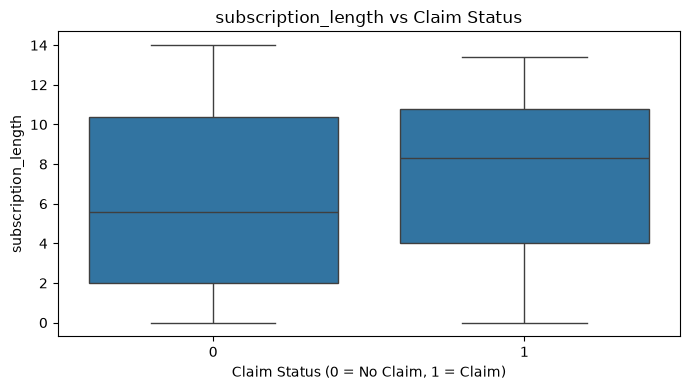

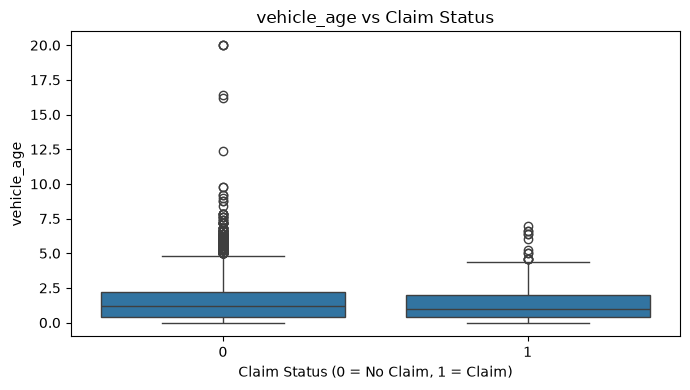

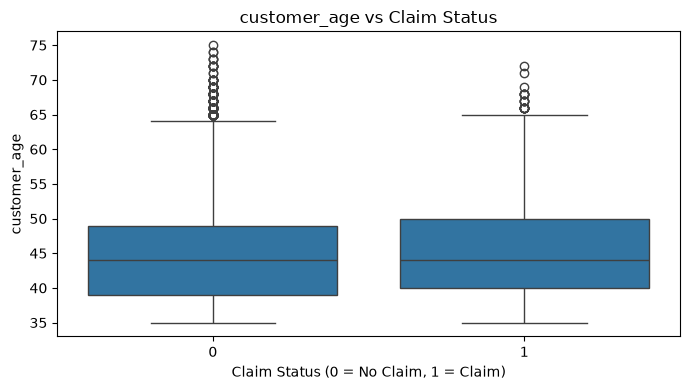

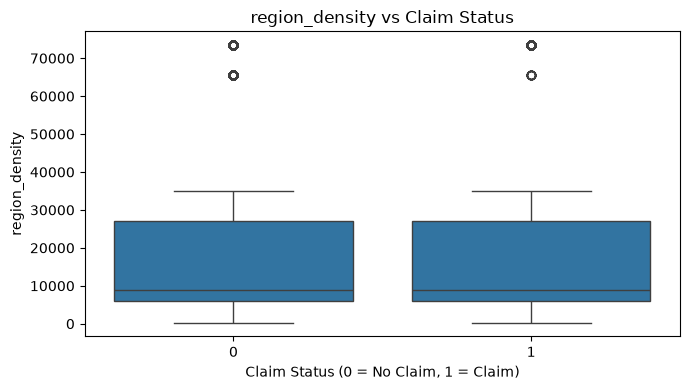

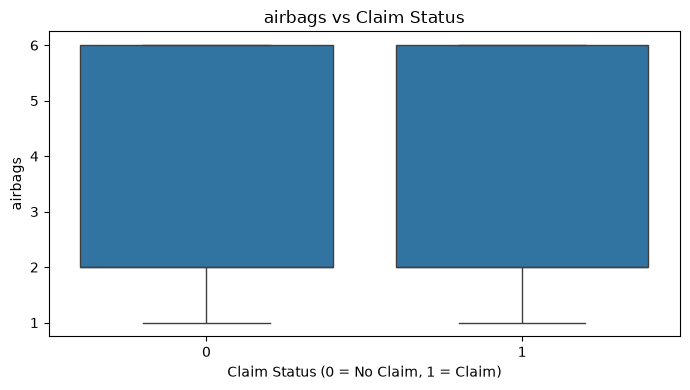

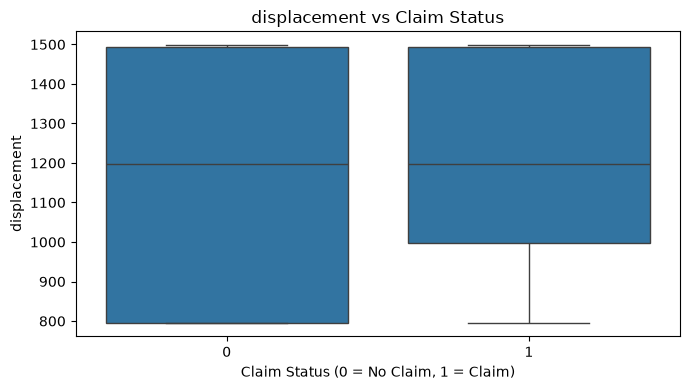

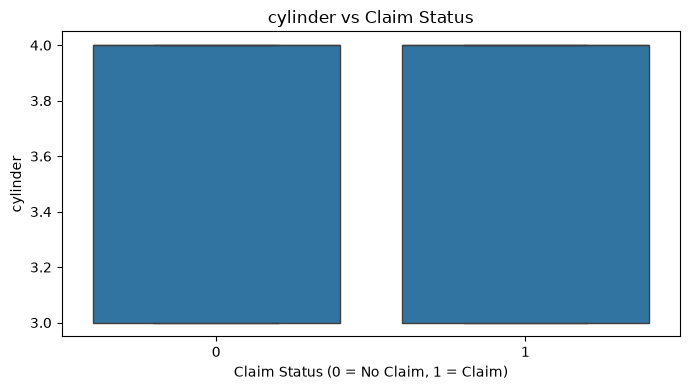

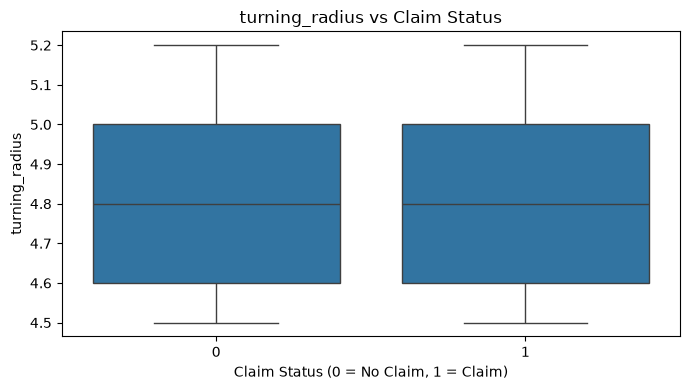

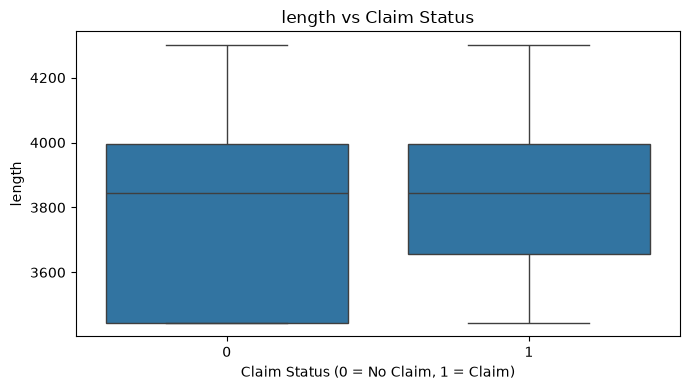

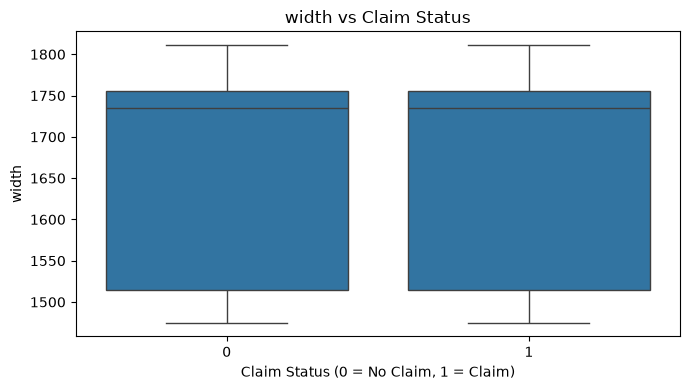

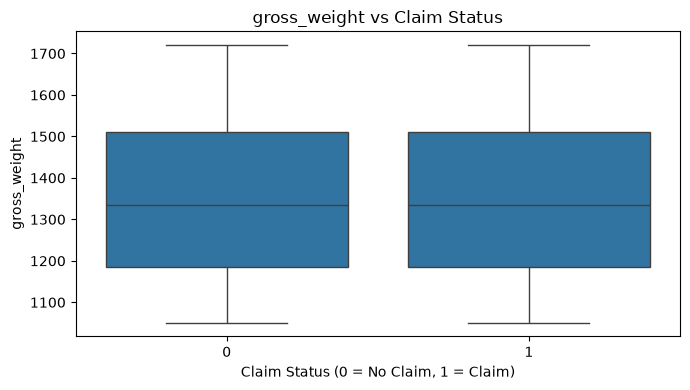

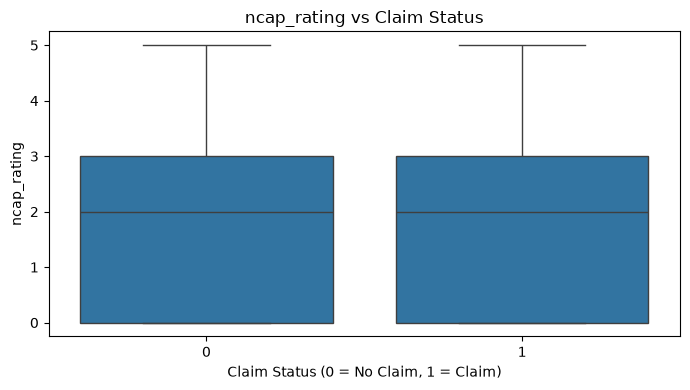

Skipping region_code: 22 categories

Claim counts by segment:
         No Claim (0)  Claim (1)
segment                         
A               16275       1046
B1               3929        244
B2              17058       1256
C1               3329        228
C2              13117        901
Utility          1136         73


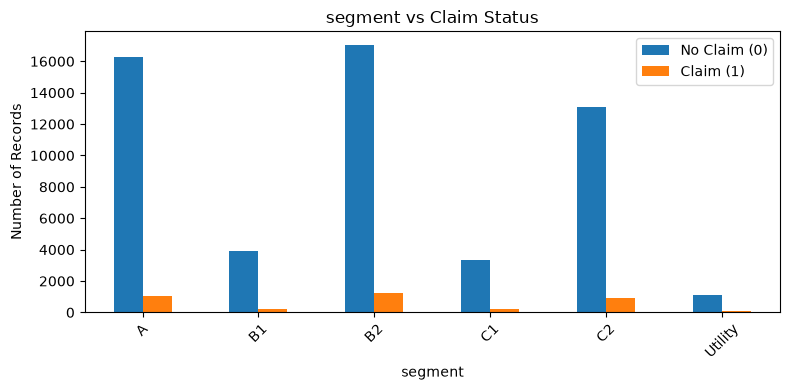


Claim counts by model:
       No Claim (0)  Claim (1)
model                         
M1            14030        918
M10            1136         73
M11             348         15
M2             1000         80
M3             2245        128
M4            13117        901
M5             1482        116
M6            12837        939
M7             2739        201
M8             3929        244
M9             1981        133


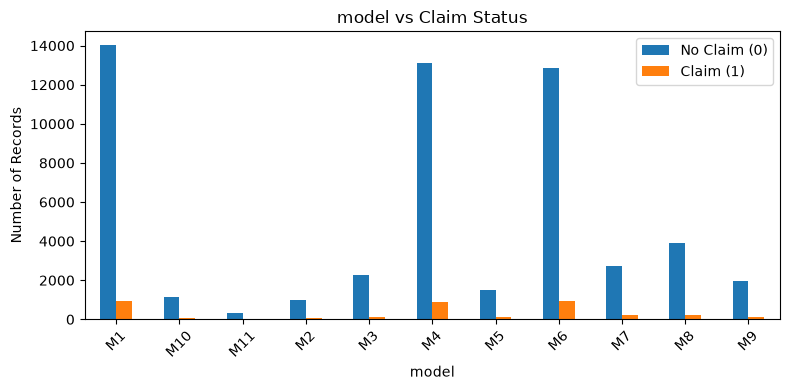


Claim counts by fuel_type:
           No Claim (0)  Claim (1)
fuel_type                         
CNG               19095       1235
Diesel            16580       1150
Petrol            19169       1363


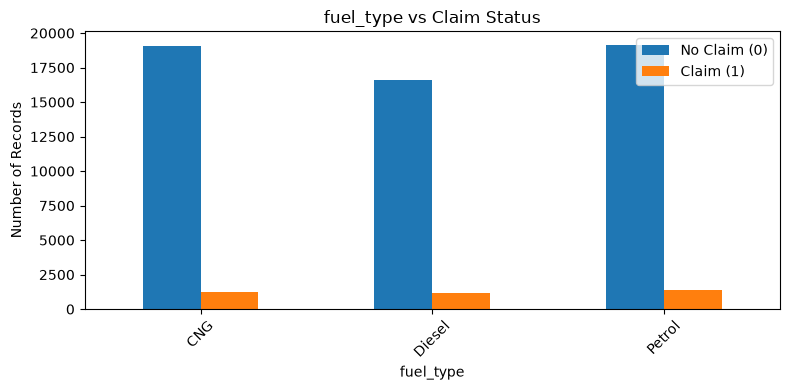


Claim counts by max_torque:
                No Claim (0)  Claim (1)
max_torque                             
113Nm@4400rpm          16576       1220
170Nm@4000rpm            348         15
200Nm@1750rpm           1981        133
200Nm@3000rpm           1482        116
250Nm@2750rpm          13117        901
60Nm@3500rpm           14030        918
82.1Nm@3400rpm          3929        244
85Nm@3000rpm            1136         73
91Nm@4250rpm            2245        128


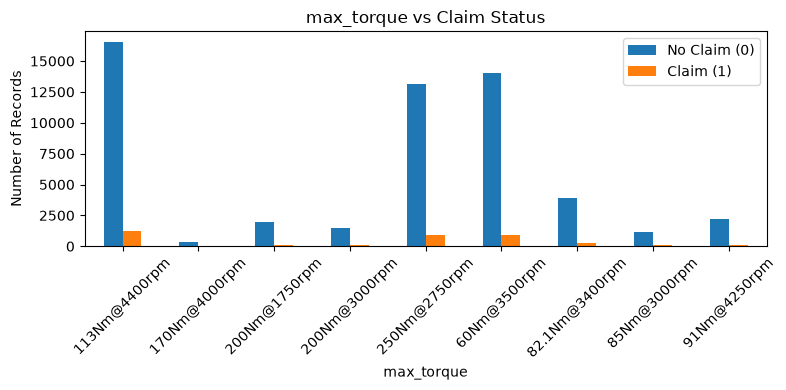


Claim counts by max_power:
                   No Claim (0)  Claim (1)
max_power                                 
113.45bhp@4000rpm         13117        901
118.36bhp@5500rpm           348         15
40.36bhp@6000rpm          14030        918
55.92bhp@5300rpm           3929        244
61.68bhp@6000rpm           1136         73
67.06bhp@5500rpm           2245        128
88.50bhp@6000rpm          16576       1220
88.77bhp@4000rpm           1482        116
97.89bhp@3600rpm           1981        133


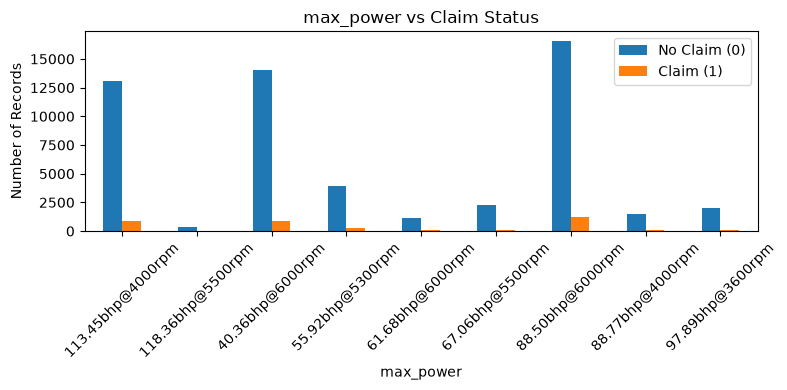


Claim counts by engine_type:
                           No Claim (0)  Claim (1)
engine_type                                       
1.0 SCe                            2245        128
1.2 L K Series Engine              2739        201
1.2 L K12N Dualjet                 1000         80
1.5 L U2 CRDi                     13117        901
1.5 Turbocharged Revotorq          1482        116
1.5 Turbocharged Revotron           348         15
F8D Petrol Engine                 14030        918
G12B                               1136         73
K Series Dual jet                 12837        939
K10C                               3929        244
i-DTEC                             1981        133


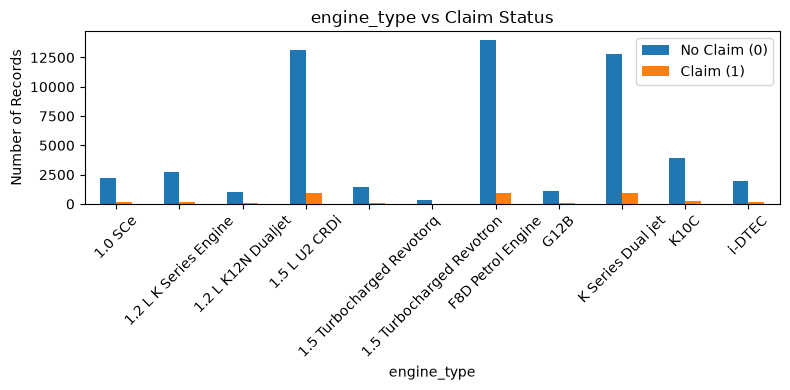


Claim counts by is_esc:
        No Claim (0)  Claim (1)
is_esc                         
No             37640       2551
Yes            17204       1197


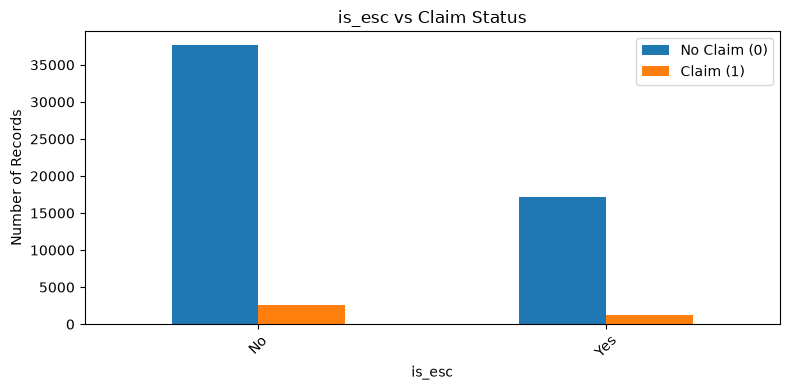


Claim counts by is_adjustable_steering:
                        No Claim (0)  Claim (1)
is_adjustable_steering                         
No                             21688       1378
Yes                            33156       2370


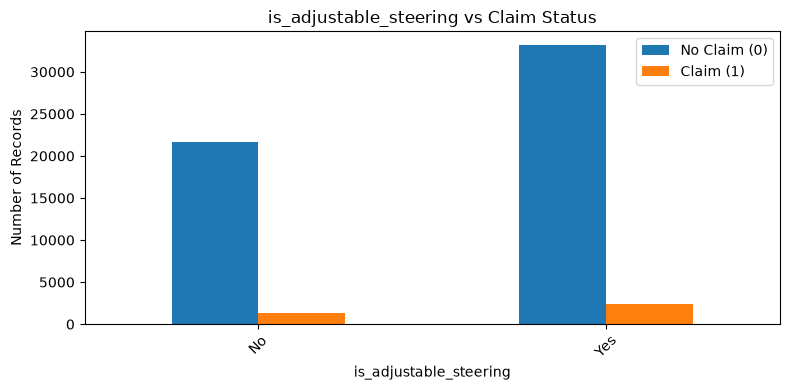


Claim counts by is_tpms:
         No Claim (0)  Claim (1)
is_tpms                         
No              41727       2847
Yes             13117        901


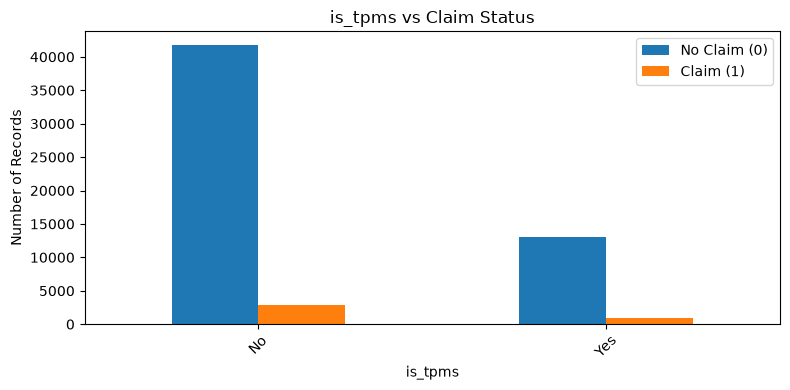


Claim counts by is_parking_sensors:
                    No Claim (0)  Claim (1)
is_parking_sensors                         
No                          2245        128
Yes                        52599       3620


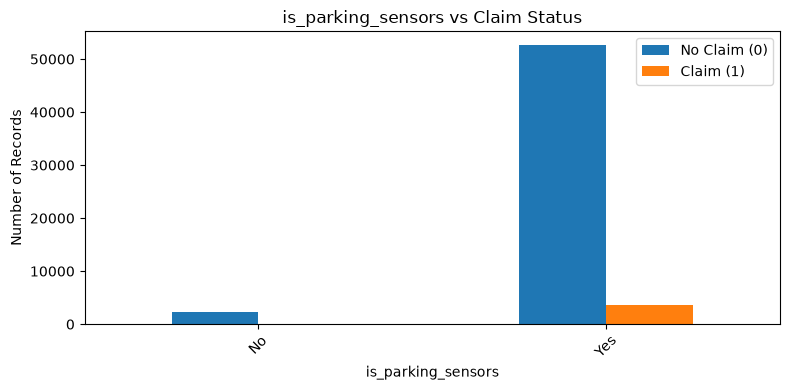


Claim counts by is_parking_camera:
                   No Claim (0)  Claim (1)
is_parking_camera                         
No                        33414       2290
Yes                       21430       1458


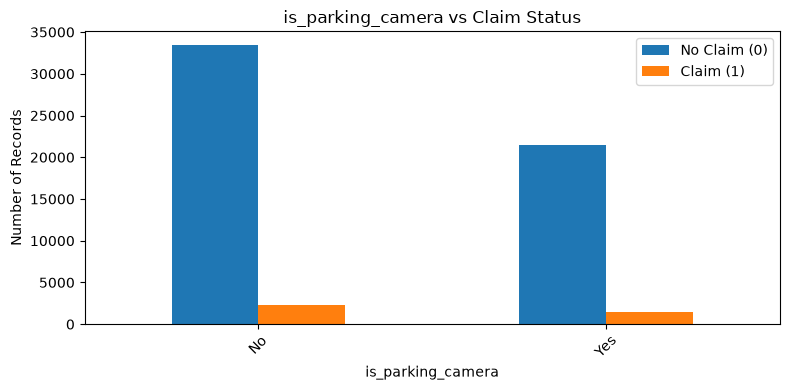


Claim counts by rear_brakes_type:
                  No Claim (0)  Claim (1)
rear_brakes_type                         
Disc                     13117        901
Drum                     41727       2847


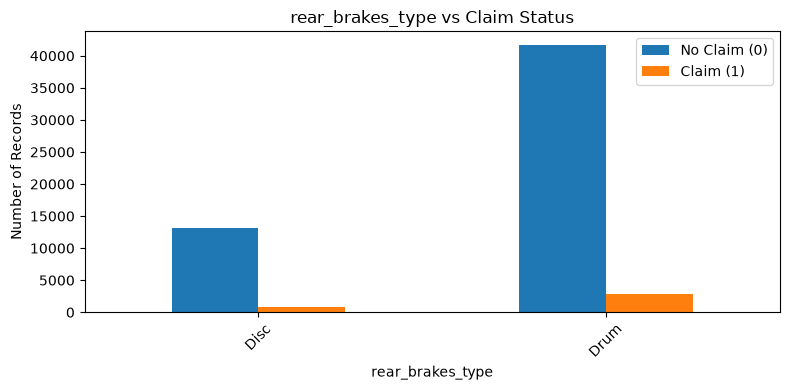


Claim counts by transmission_type:
                   No Claim (0)  Claim (1)
transmission_type                         
Automatic                 19101       1310
Manual                    35743       2438


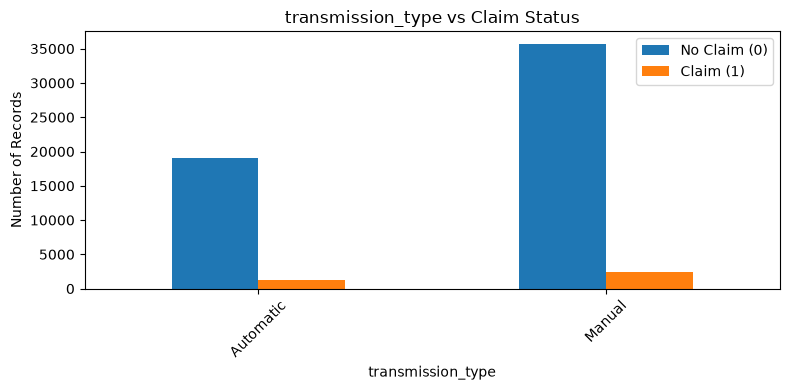


Claim counts by steering_type:
               No Claim (0)  Claim (1)
steering_type                         
Electric              22284       1597
Manual                 1136         73
Power                 31424       2078


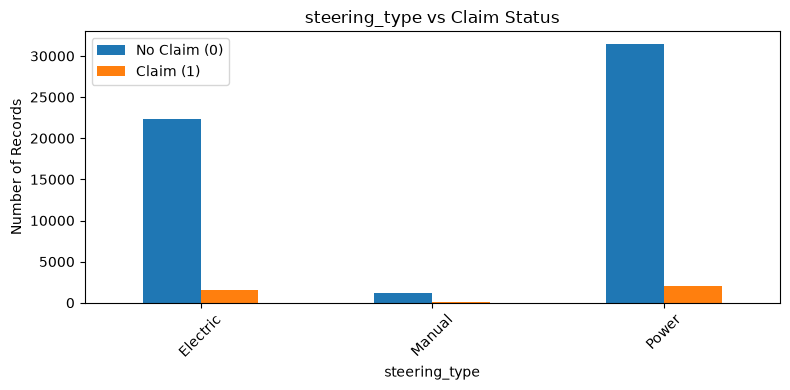


Claim counts by is_front_fog_lights:
                     No Claim (0)  Claim (1)
is_front_fog_lights                         
No                          23170       1494
Yes                         31674       2254


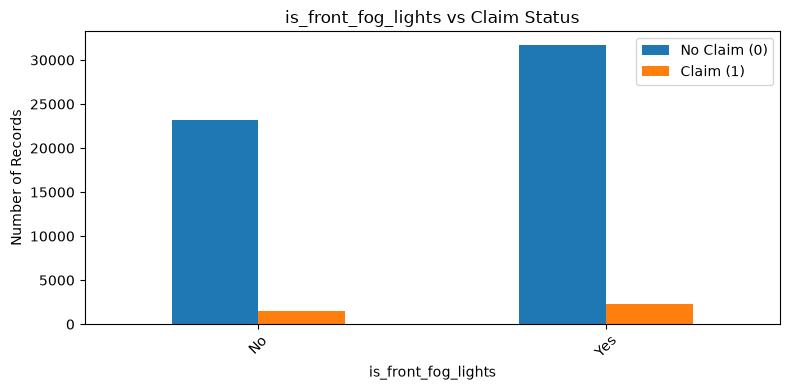


Claim counts by is_rear_window_wiper:
                      No Claim (0)  Claim (1)
is_rear_window_wiper                         
No                           38988       2646
Yes                          15856       1102


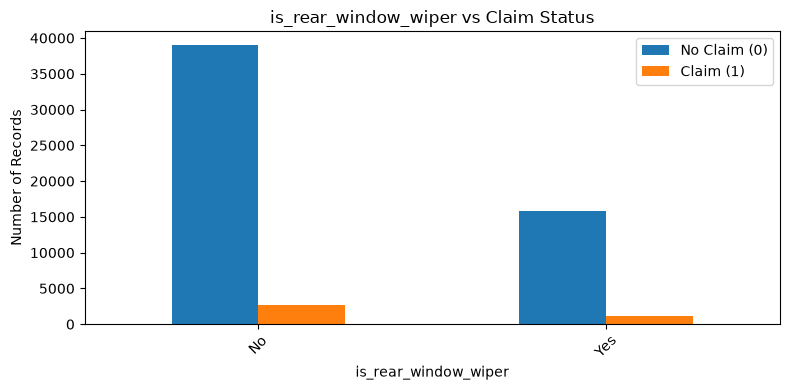


Claim counts by is_rear_window_washer:
                       No Claim (0)  Claim (1)
is_rear_window_washer                         
No                            38988       2646
Yes                           15856       1102


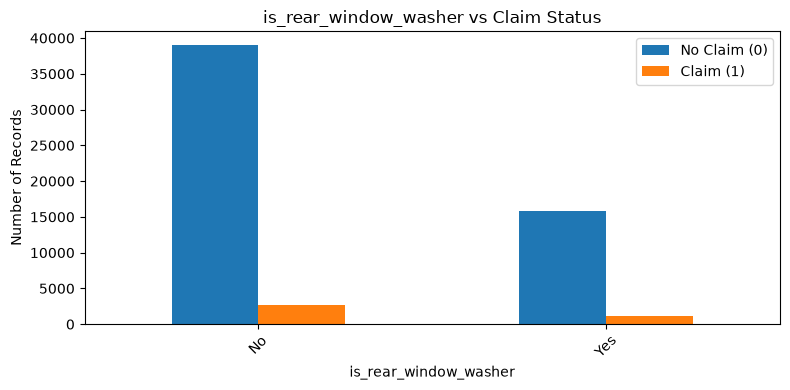


Claim counts by is_rear_window_defogger:
                         No Claim (0)  Claim (1)
is_rear_window_defogger                         
No                              35659       2418
Yes                             19185       1330


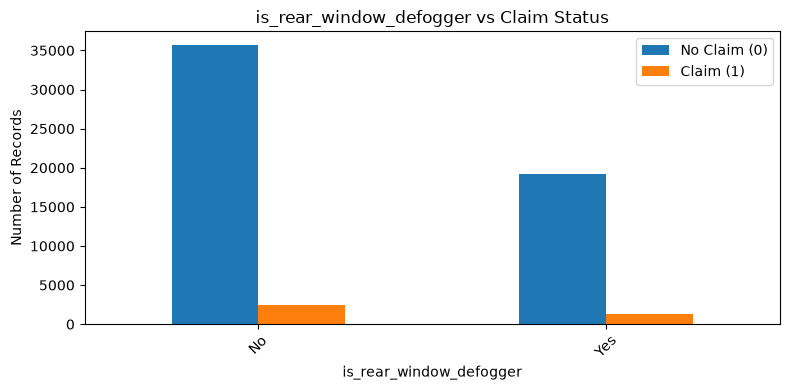


Claim counts by is_brake_assist:
                 No Claim (0)  Claim (1)
is_brake_assist                         
No                      24803       1612
Yes                     30041       2136


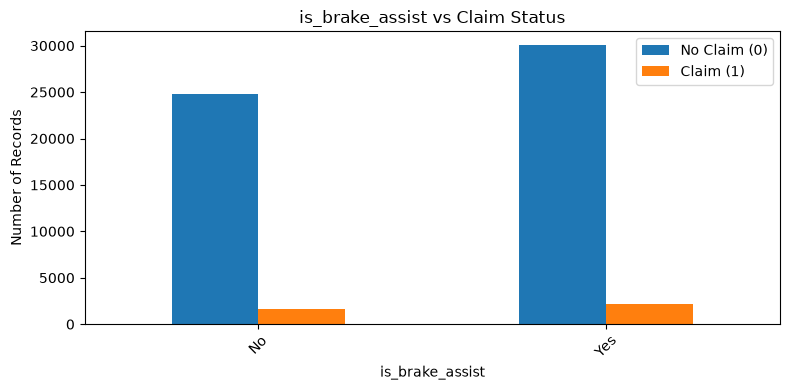


Claim counts by is_power_door_locks:
                     No Claim (0)  Claim (1)
is_power_door_locks                         
No                          15166        991
Yes                         39678       2757


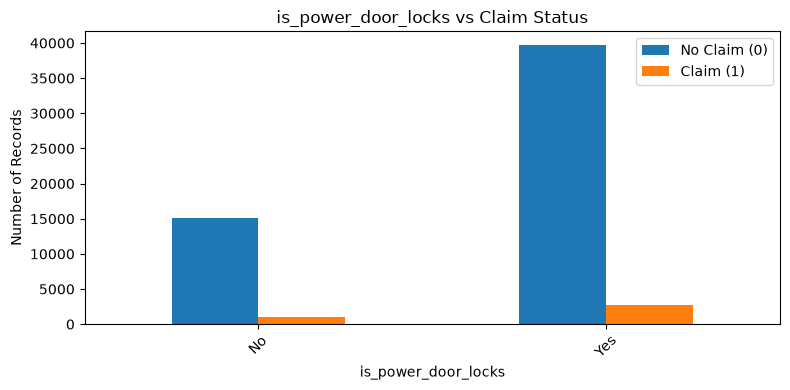


Claim counts by is_central_locking:
                    No Claim (0)  Claim (1)
is_central_locking                         
No                         15166        991
Yes                        39678       2757


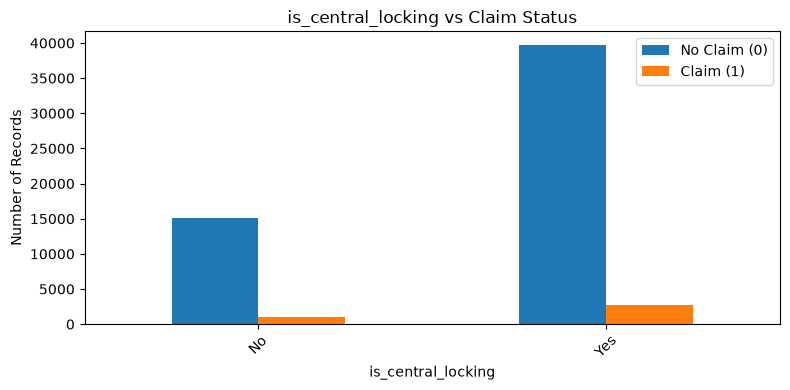


Claim counts by is_power_steering:
                   No Claim (0)  Claim (1)
is_power_steering                         
No                         1136         73
Yes                       53708       3675


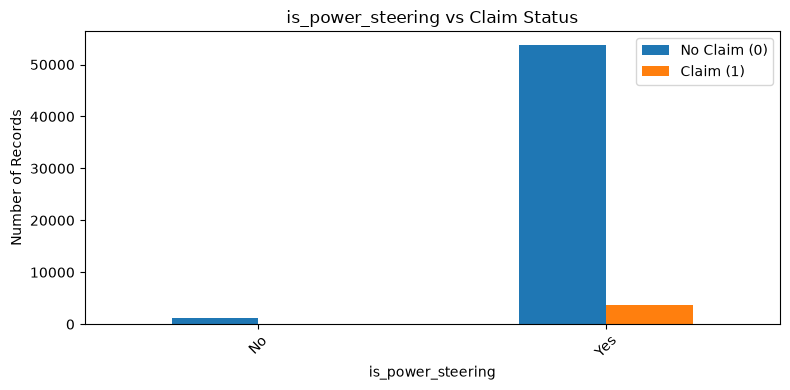


Claim counts by is_driver_seat_height_adjustable:
                                  No Claim (0)  Claim (1)
is_driver_seat_height_adjustable                         
No                                       22822       1479
Yes                                      32022       2269


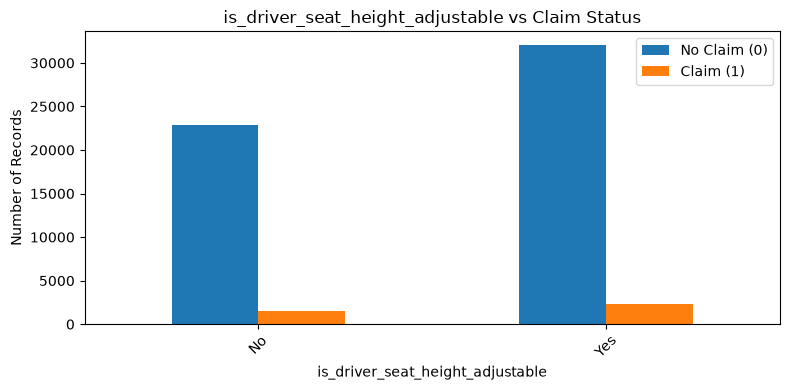


Claim counts by is_day_night_rear_view_mirror:
                               No Claim (0)  Claim (1)
is_day_night_rear_view_mirror                         
No                                    34042       2267
Yes                                   20802       1481


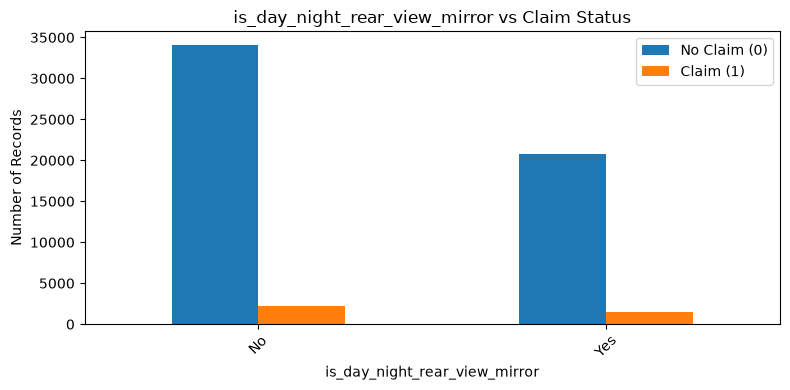


Claim counts by is_ecw:
        No Claim (0)  Claim (1)
is_ecw                         
No             15166        991
Yes            39678       2757


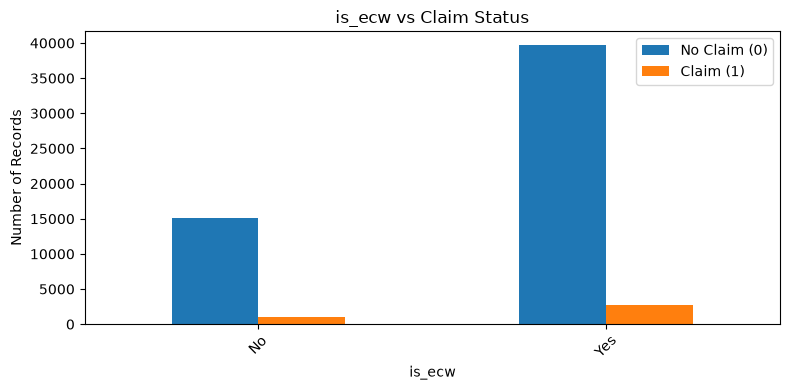


Claim counts by is_speed_alert:
                No Claim (0)  Claim (1)
is_speed_alert                         
No                       348         15
Yes                    54496       3733


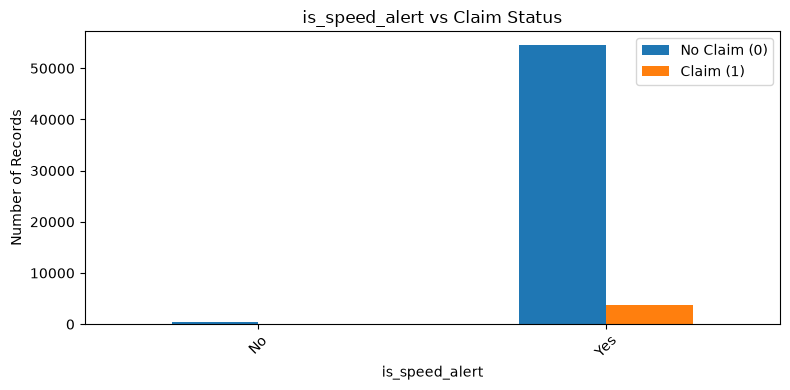


region_code vs fuel_type:
fuel_type     CNG  Diesel  Petrol
region_code                      
C10          1467     748     940
C12           398     509     682
C13           877    1214    1332
C14           751    1378    1531
C2           2340    2285    2717
C3           3749    1136    1216
C5           3210    1796    1973
C7            921     589     657
C8           1843    5569    6242
C9           1142     673     919


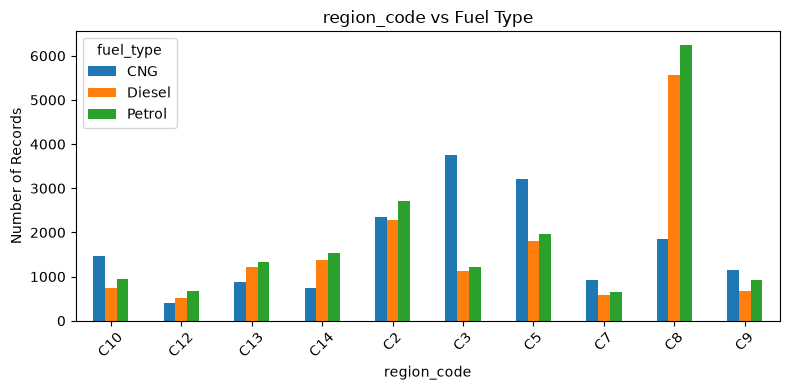


segment vs fuel_type:
fuel_type    CNG  Diesel  Petrol
segment                         
A          14948       0    2373
B1          4173       0       0
B2             0    1598   16716
C1             0    2114    1443
C2             0   14018       0
Utility     1209       0       0


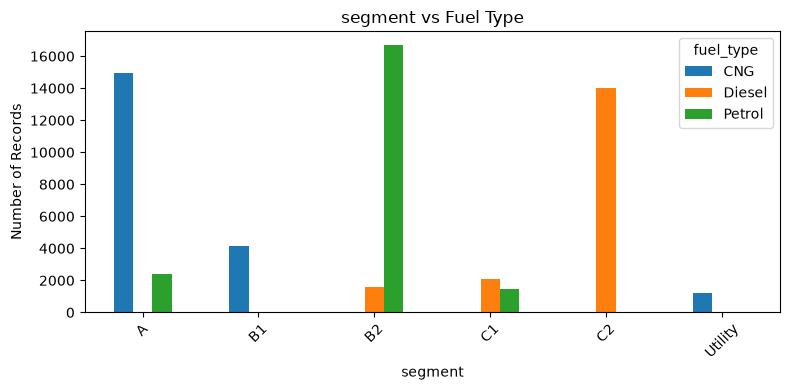


model vs fuel_type:
fuel_type    CNG  Diesel  Petrol
model                           
M1         14948       0       0
M10         1209       0       0
M2             0       0    1080
M3             0       0    2373
M4             0   14018       0
M5             0    1598       0
M6             0       0   13776
M7             0       0    2940
M8          4173       0       0
M9             0    2114       0


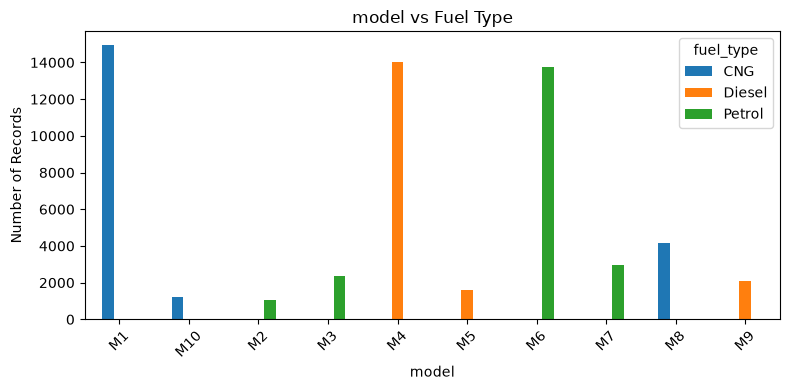


max_torque vs fuel_type:
fuel_type         CNG  Diesel  Petrol
max_torque                           
113Nm@4400rpm       0       0   17796
170Nm@4000rpm       0       0     363
200Nm@1750rpm       0    2114       0
200Nm@3000rpm       0    1598       0
250Nm@2750rpm       0   14018       0
60Nm@3500rpm    14948       0       0
82.1Nm@3400rpm   4173       0       0
85Nm@3000rpm     1209       0       0
91Nm@4250rpm        0       0    2373


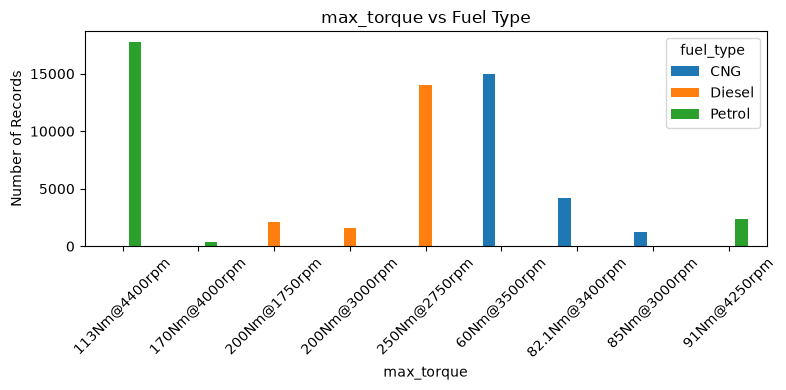


max_power vs fuel_type:
fuel_type            CNG  Diesel  Petrol
max_power                               
113.45bhp@4000rpm      0   14018       0
118.36bhp@5500rpm      0       0     363
40.36bhp@6000rpm   14948       0       0
55.92bhp@5300rpm    4173       0       0
61.68bhp@6000rpm    1209       0       0
67.06bhp@5500rpm       0       0    2373
88.50bhp@6000rpm       0       0   17796
88.77bhp@4000rpm       0    1598       0
97.89bhp@3600rpm       0    2114       0


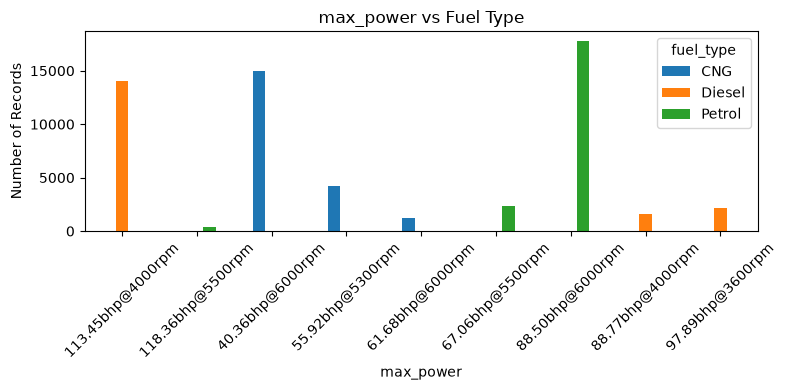


engine_type vs fuel_type:
fuel_type                    CNG  Diesel  Petrol
engine_type                                     
1.0 SCe                        0       0    2373
1.2 L K Series Engine          0       0    2940
1.2 L K12N Dualjet             0       0    1080
1.5 L U2 CRDi                  0   14018       0
1.5 Turbocharged Revotorq      0    1598       0
F8D Petrol Engine          14948       0       0
G12B                        1209       0       0
K Series Dual jet              0       0   13776
K10C                        4173       0       0
i-DTEC                         0    2114       0


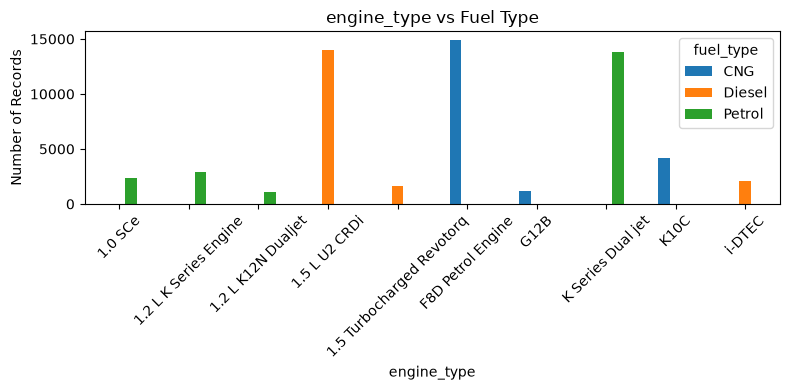


is_esc vs fuel_type:
fuel_type    CNG  Diesel  Petrol
is_esc                          
No         20330    3712   16149
Yes            0   14018    4383


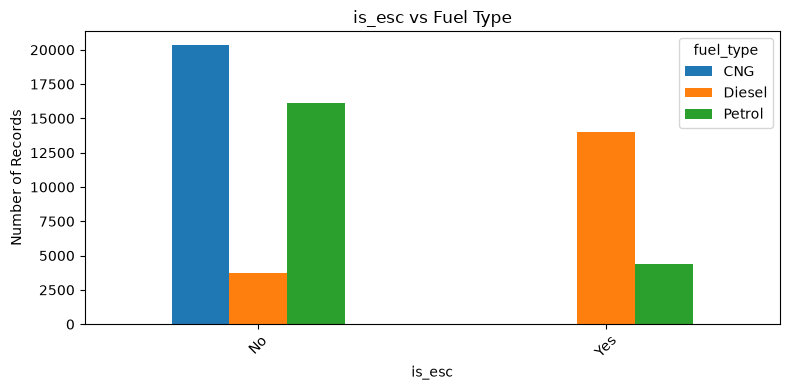


is_adjustable_steering vs fuel_type:
fuel_type                 CNG  Diesel  Petrol
is_adjustable_steering                       
No                      20330       0    2736
Yes                         0   17730   17796


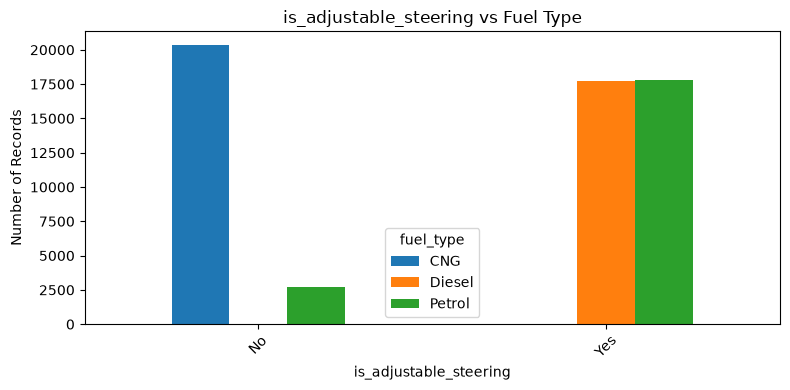


is_tpms vs fuel_type:
fuel_type    CNG  Diesel  Petrol
is_tpms                         
No         20330    3712   20532
Yes            0   14018       0


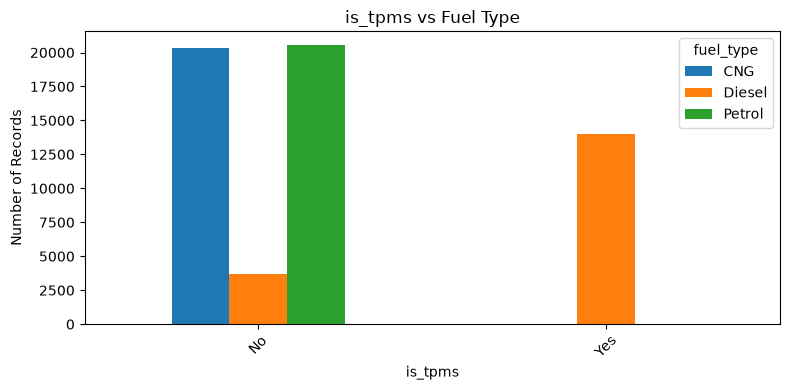


is_parking_sensors vs fuel_type:
fuel_type             CNG  Diesel  Petrol
is_parking_sensors                       
No                      0       0    2373
Yes                 20330   17730   18159


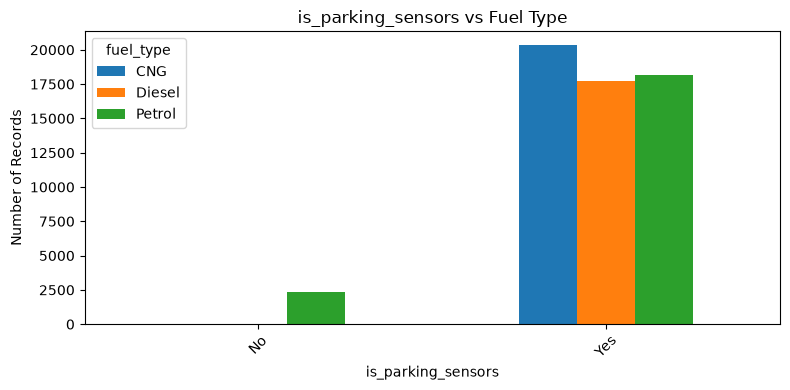


is_parking_camera vs fuel_type:
fuel_type            CNG  Diesel  Petrol
is_parking_camera                       
No                 20330    1598   13776
Yes                    0   16132    6756


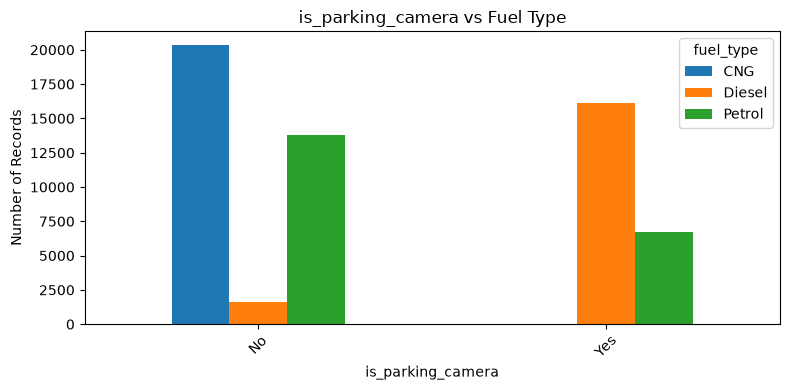


rear_brakes_type vs fuel_type:
fuel_type           CNG  Diesel  Petrol
rear_brakes_type                       
Disc                  0   14018       0
Drum              20330    3712   20532


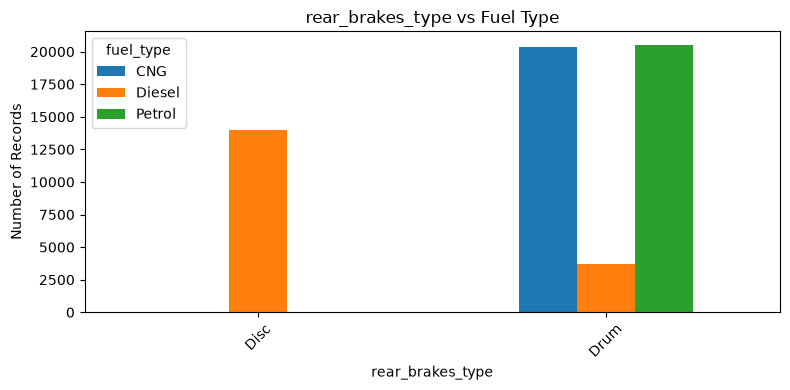


transmission_type vs fuel_type:
fuel_type            CNG  Diesel  Petrol
transmission_type                       
Automatic              0   14018    6393
Manual             20330    3712   14139


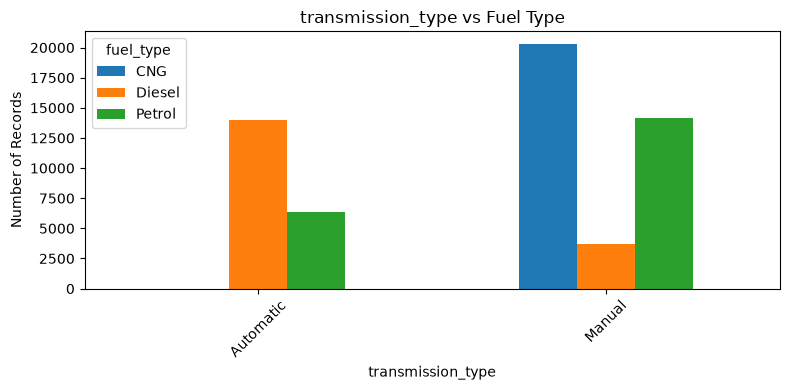


steering_type vs fuel_type:
fuel_type        CNG  Diesel  Petrol
steering_type                       
Electric           0    3712   20169
Manual          1209       0       0
Power          19121   14018     363


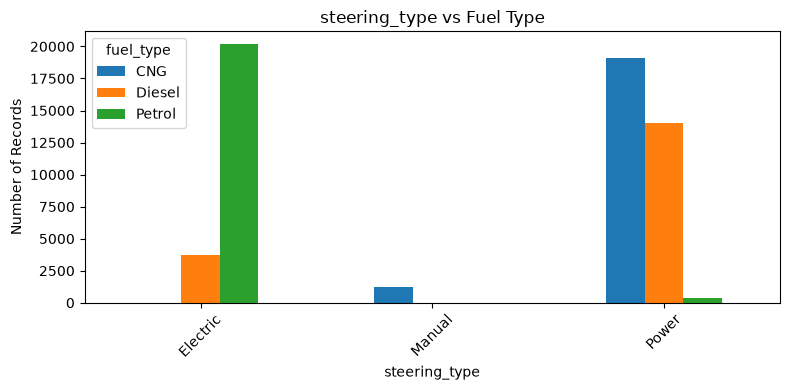


is_front_fog_lights vs fuel_type:
fuel_type              CNG  Diesel  Petrol
is_front_fog_lights                       
No                   20330    1598    2736
Yes                      0   16132   17796


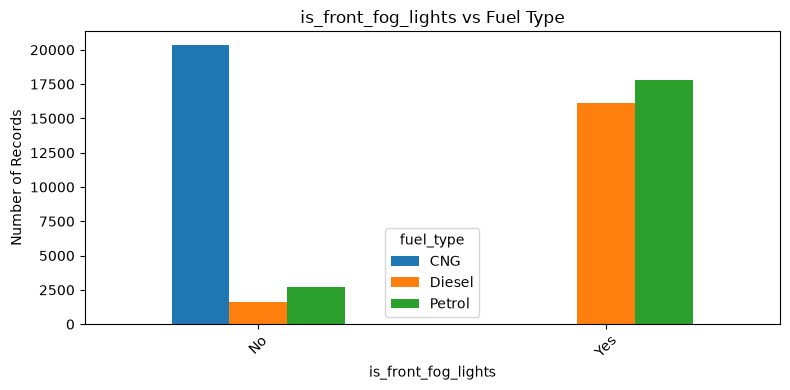


is_rear_window_wiper vs fuel_type:
fuel_type               CNG  Diesel  Petrol
is_rear_window_wiper                       
No                    20330    3712   17592
Yes                       0   14018    2940


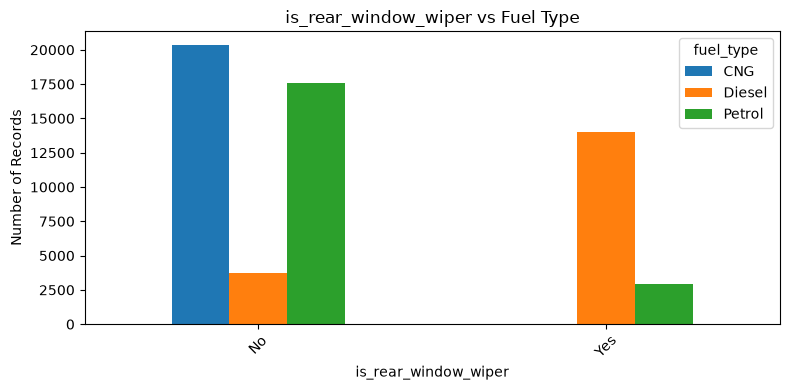


is_rear_window_washer vs fuel_type:
fuel_type                CNG  Diesel  Petrol
is_rear_window_washer                       
No                     20330    3712   17592
Yes                        0   14018    2940


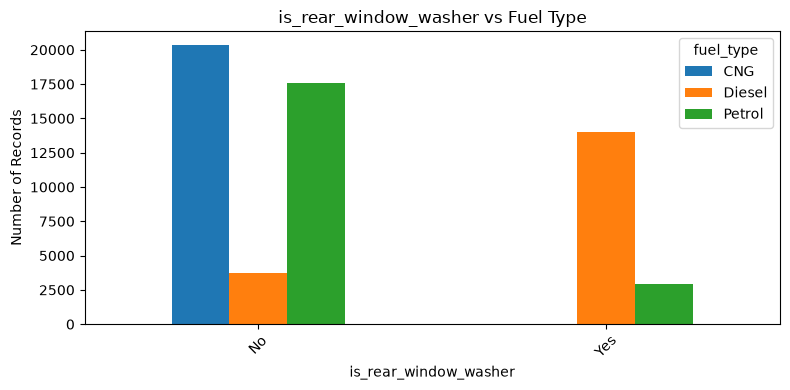


is_rear_window_defogger vs fuel_type:
fuel_type                  CNG  Diesel  Petrol
is_rear_window_defogger                       
No                       20330    1598   16149
Yes                          0   16132    4383


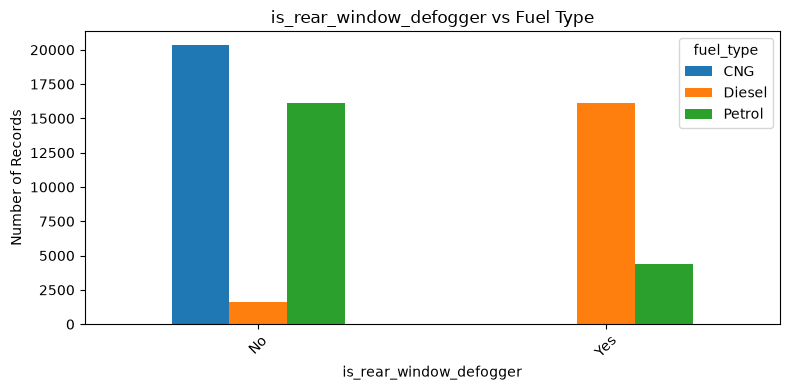


is_brake_assist vs fuel_type:
fuel_type          CNG  Diesel  Petrol
is_brake_assist                       
No               20330    3712    2373
Yes                  0   14018   18159


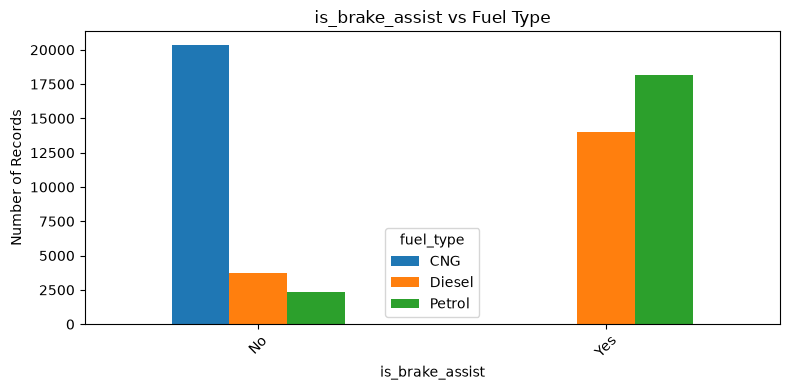


is_power_door_locks vs fuel_type:
fuel_type              CNG  Diesel  Petrol
is_power_door_locks                       
No                   16157       0       0
Yes                   4173   17730   20532


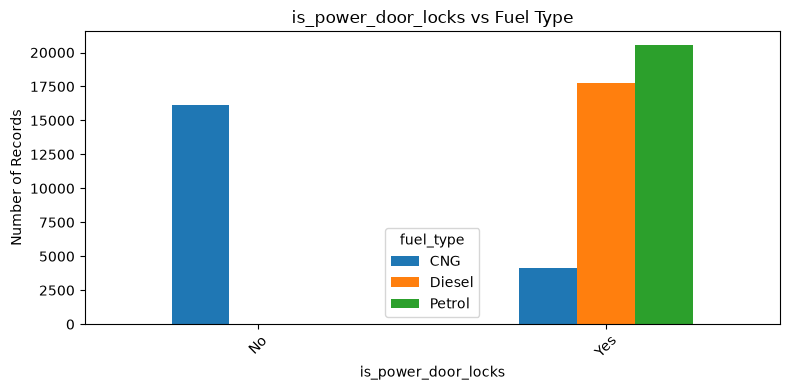


is_central_locking vs fuel_type:
fuel_type             CNG  Diesel  Petrol
is_central_locking                       
No                  16157       0       0
Yes                  4173   17730   20532


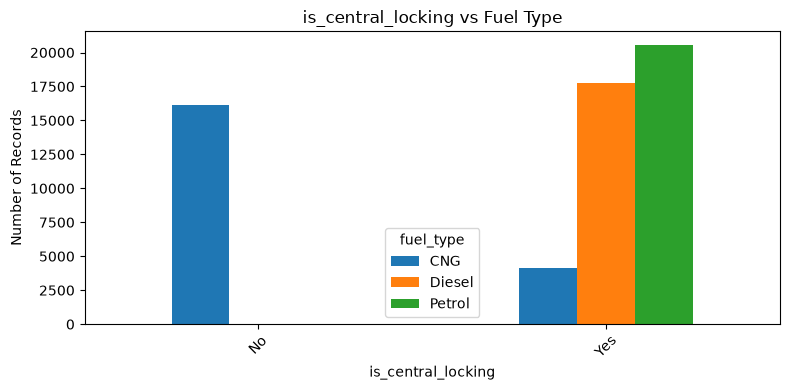


is_power_steering vs fuel_type:
fuel_type            CNG  Diesel  Petrol
is_power_steering                       
No                  1209       0       0
Yes                19121   17730   20532


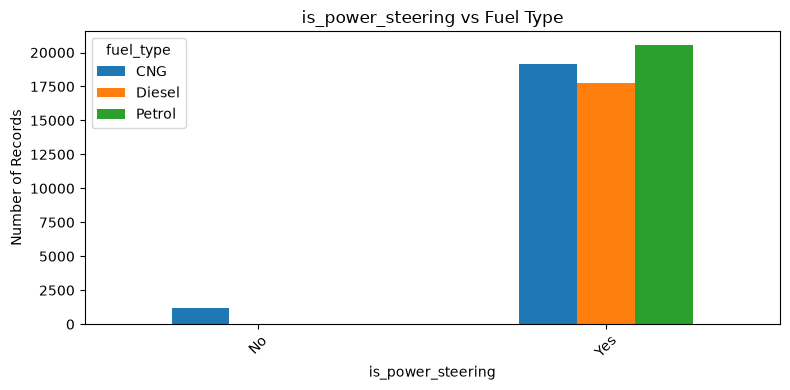


is_driver_seat_height_adjustable vs fuel_type:
fuel_type                           CNG  Diesel  Petrol
is_driver_seat_height_adjustable                       
No                                20330    1598    2373
Yes                                   0   16132   18159


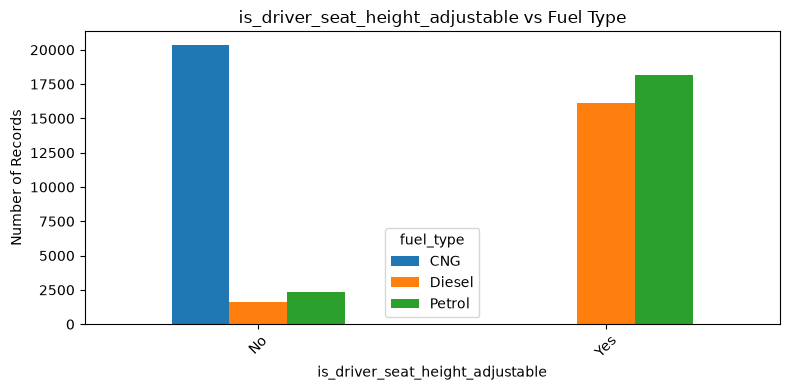


is_day_night_rear_view_mirror vs fuel_type:
fuel_type                        CNG  Diesel  Petrol
is_day_night_rear_view_mirror                       
No                             20330   15616     363
Yes                                0    2114   20169


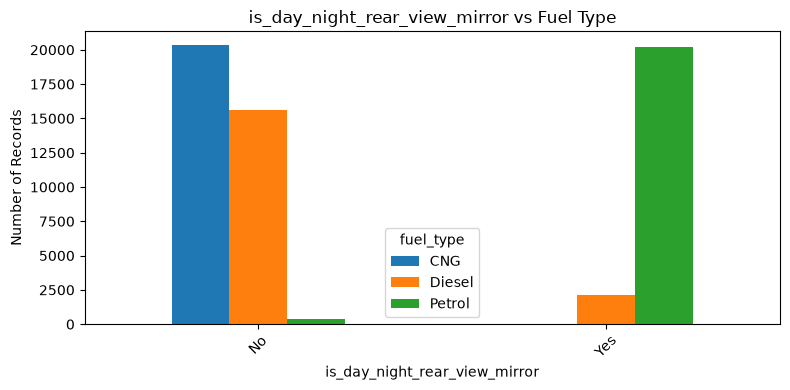


is_ecw vs fuel_type:
fuel_type    CNG  Diesel  Petrol
is_ecw                          
No         16157       0       0
Yes         4173   17730   20532


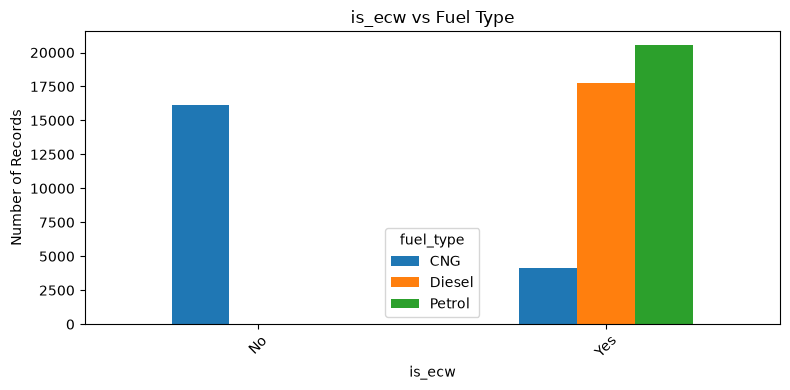


is_speed_alert vs fuel_type:
fuel_type         CNG  Diesel  Petrol
is_speed_alert                       
No                  0       0     363
Yes             20330   17730   20169


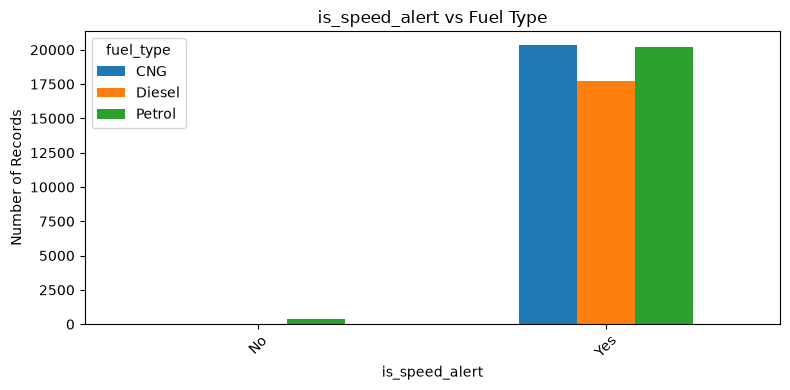


Bivariate analysis completed.


In [ ]:

# BIVARIATE ANALYSIS - INSURANCE CLAIM PREDICTION
# Bivariate analysis means studying the relationship
# between two variables.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. SELECT NUMERICAL AND CATEGORICAL COLUMNS

target = "claim_status"

numerical_columns = (
    Insurance_df.select_dtypes(include=np.number)
    .columns.drop(target, errors="ignore")
    .tolist()
)

categorical_columns = Insurance_df.select_dtypes(
    include=["object", "category", "bool"]
)

# Remove ID and target from categorical features

categorical_columns = categorical_columns.drop(['policy_id'], axis=1)

categorical_columns

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

# 2. NUMERICAL vs NUMERICAL
# Use correlation to examine relationships between numeric features.

correlation_columns = numerical_columns + [target]

correlation = Insurance_df[correlation_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
plt.close()

# Scatter plots: limit to the first 5 numerical features
for col in numerical_columns[:5]:

    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=Insurance_df,
        x=col,
        y="region_density",
        hue=target,
        alpha=0.5
    )

    plt.title(f"{col} vs Region Density")
    plt.tight_layout()
    plt.show()
    plt.close()

# 3. NUMERICAL vs CLAIM
# Compare distributions of numeric features between claim groups.

for col in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=Insurance_df,
        x=target,
        y=col
    )

    plt.title(f"{col} vs Claim Status")
    plt.xlabel("Claim Status (0 = No Claim, 1 = Claim)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    plt.close()

# 4. CATEGORICAL vs CLAIM
# Compare claim counts across categories.
# Skip columns with too many unique values.

for col in categorical_columns:

    unique_count = Insurance_df[col].nunique(dropna=False)

    if unique_count > 20:
        print(f"Skipping {col}: {unique_count} categories")
        continue

    table = pd.crosstab(
        Insurance_df[col],
        Insurance_df[target]
    )

    table = table.reindex(columns=[0, 1], fill_value=0)
    table.columns = ["No Claim (0)", "Claim (1)"]

    print(f"\nClaim counts by {col}:")
    print(table)

    table.plot(
        kind="bar",
        figsize=(8, 4)
    )

    plt.title(f"{col} vs Claim Status")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

# 5. CATEGORICAL vs CATEGORICAL

# Compare the two most common categories of selected features.

selected_categories = categorical_columns[:3]

for col in selected_categories:

    top_categories = (
        Insurance_df[col]
        .value_counts()
        .head(10)
        .index
    )

    filtered_df = Insurance_df[
        Insurance_df[col].isin(top_categories)
    ]

    table = pd.crosstab(
        filtered_df[col],
        filtered_df["fuel_type"]
    ) if col != "fuel_type" and "fuel_type" in filtered_df.columns else None

    if table is not None:

        print(f"\n{col} vs fuel_type:")
        print(table)

        table.plot(
            kind="bar",
            figsize=(8, 4)
        )

        plt.title(f"{col} vs Fuel Type")
        plt.xlabel(col)
        plt.ylabel("Number of Records")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.close()

print("\nBivariate analysis completed.")

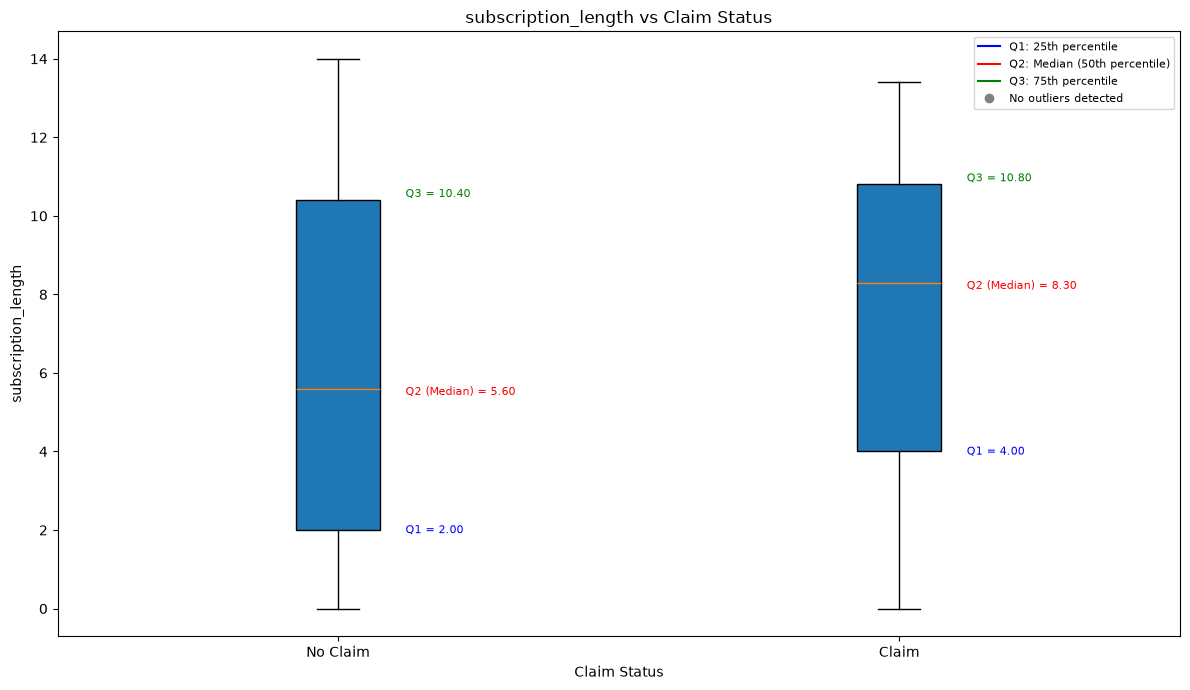

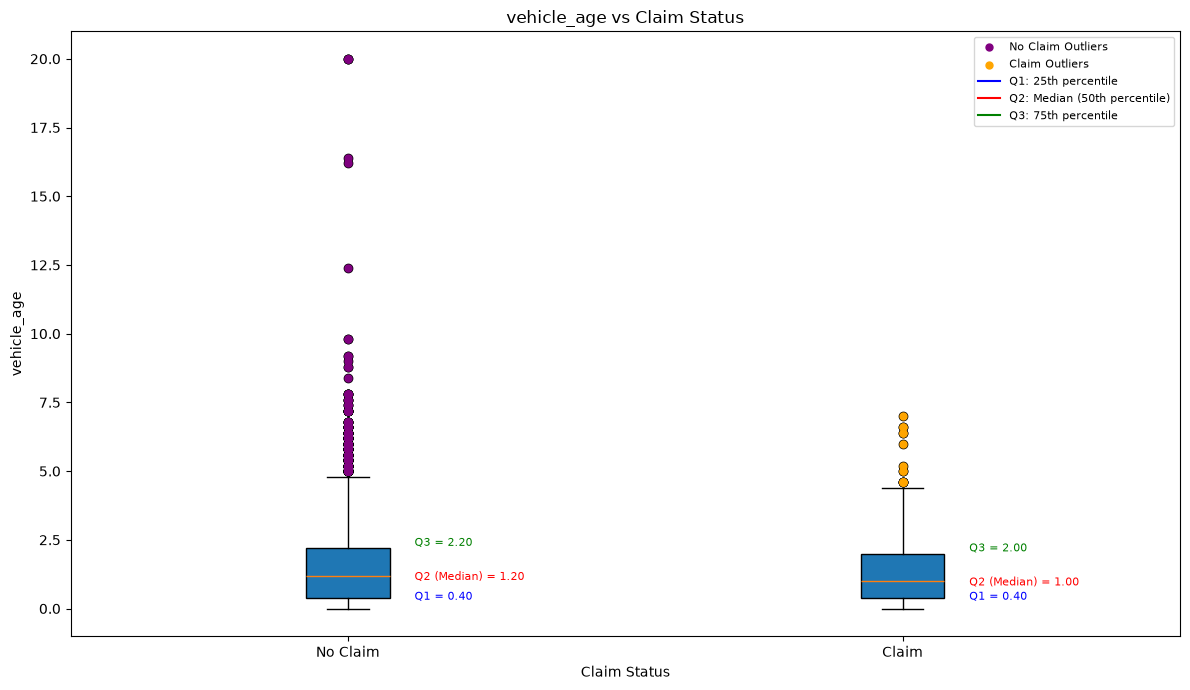

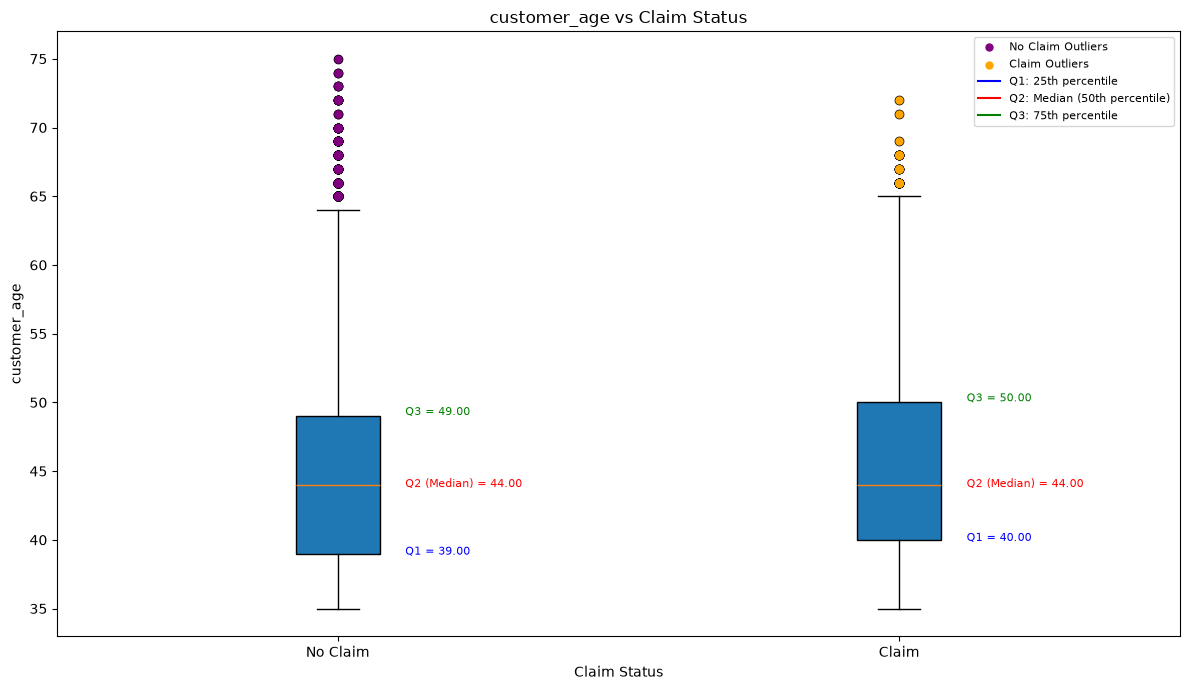

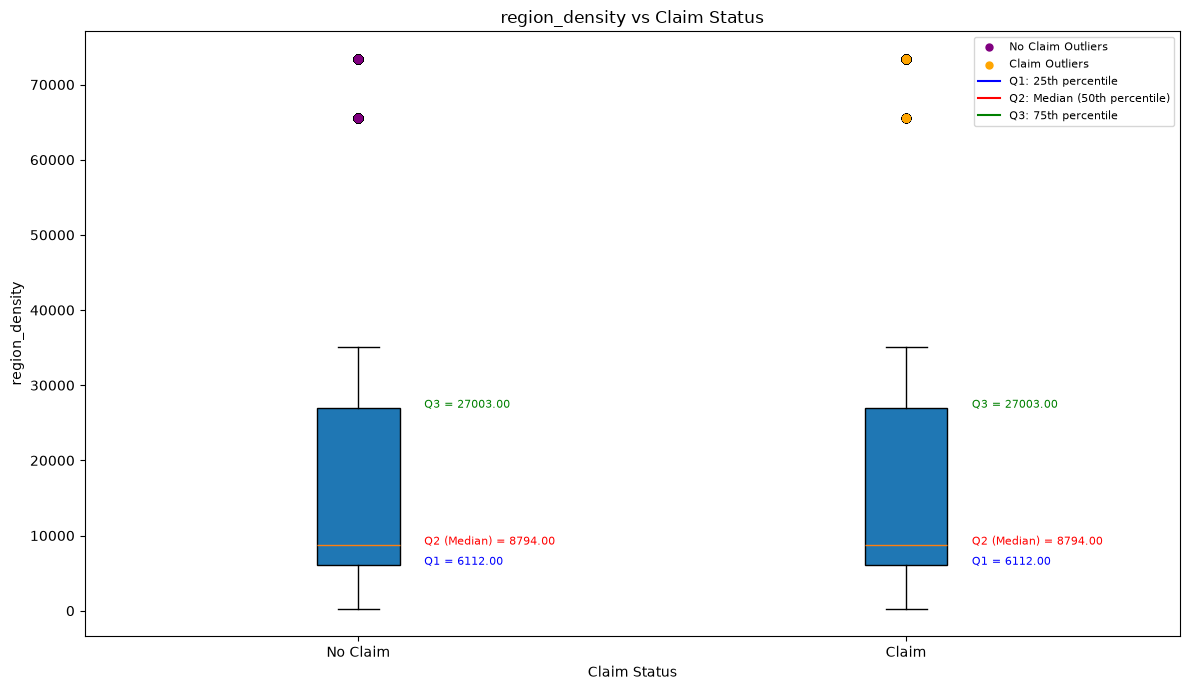

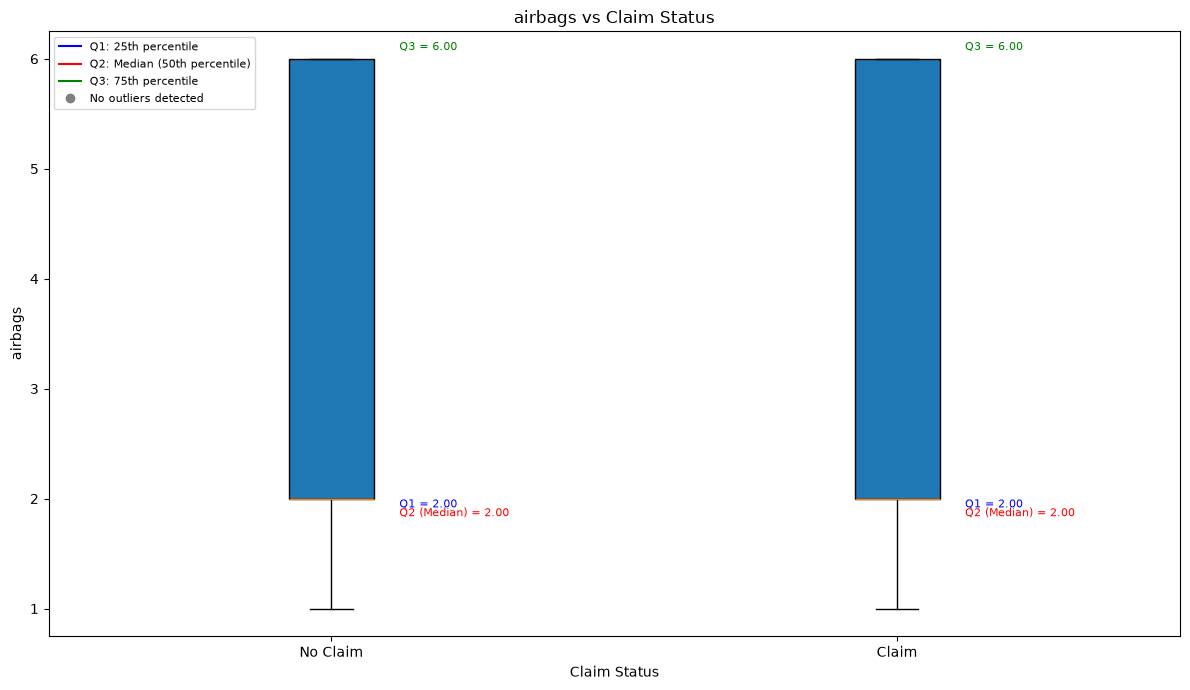

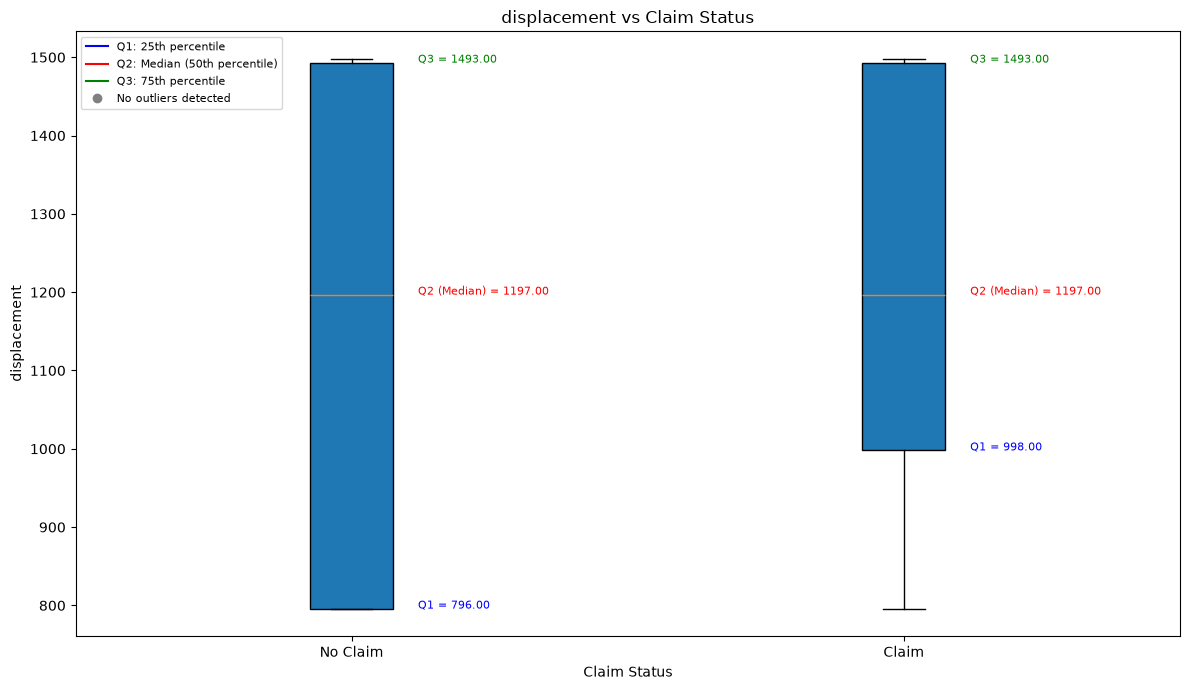

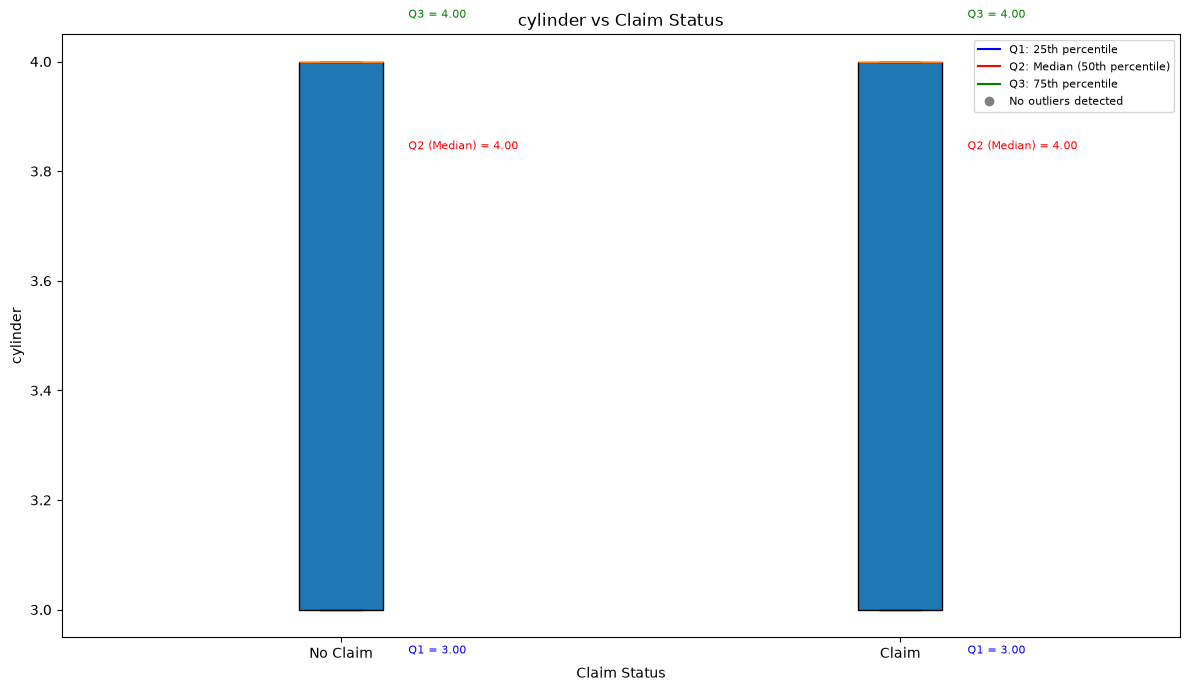

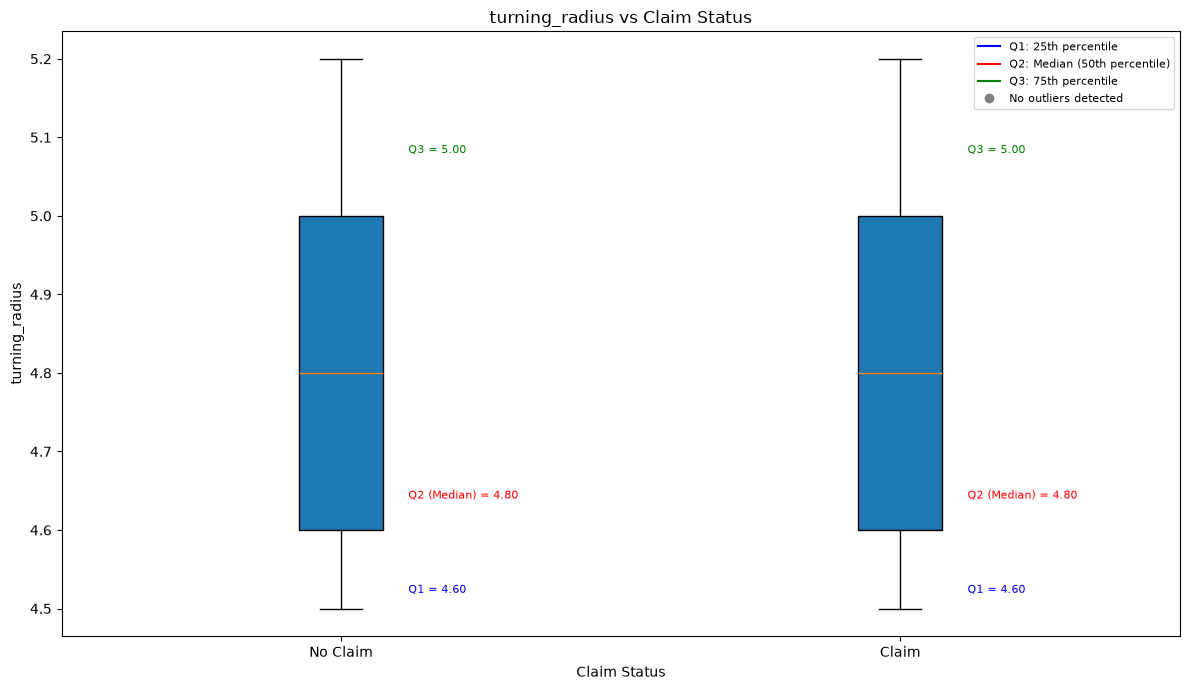

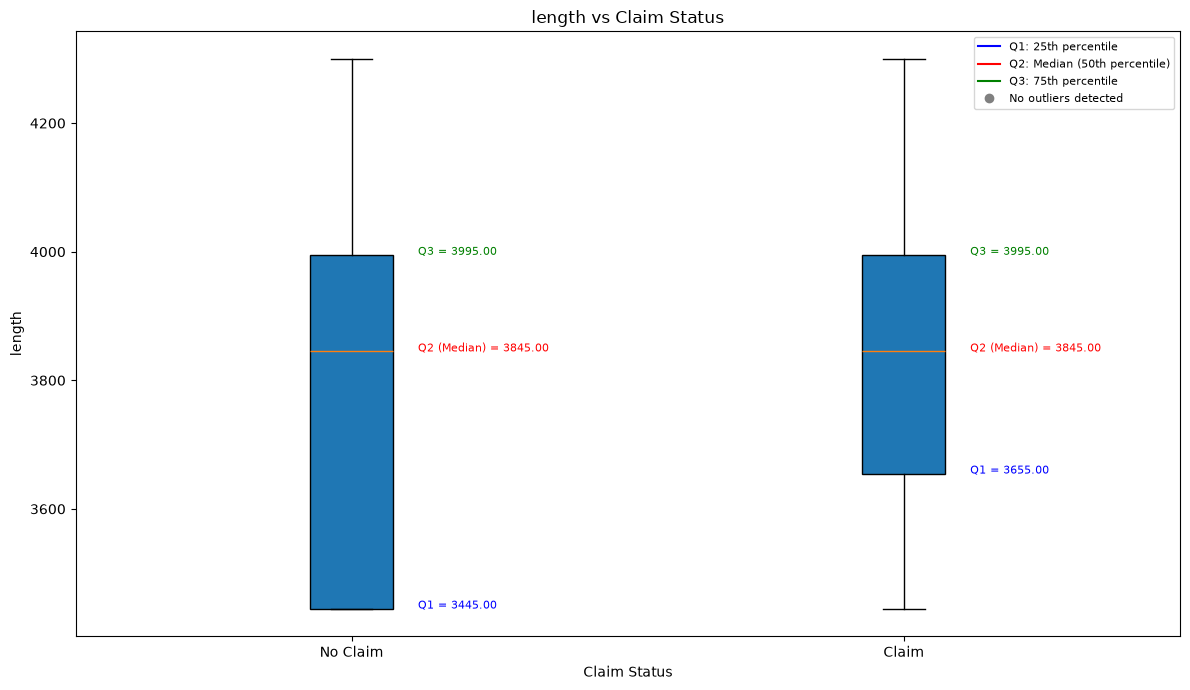

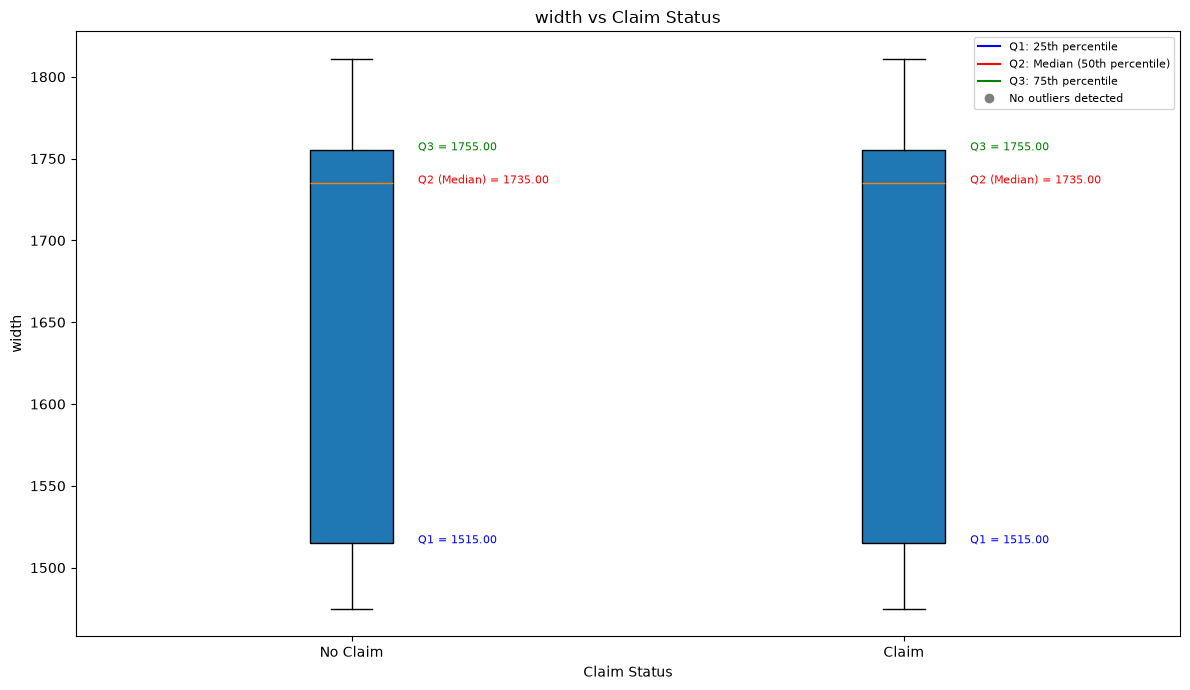

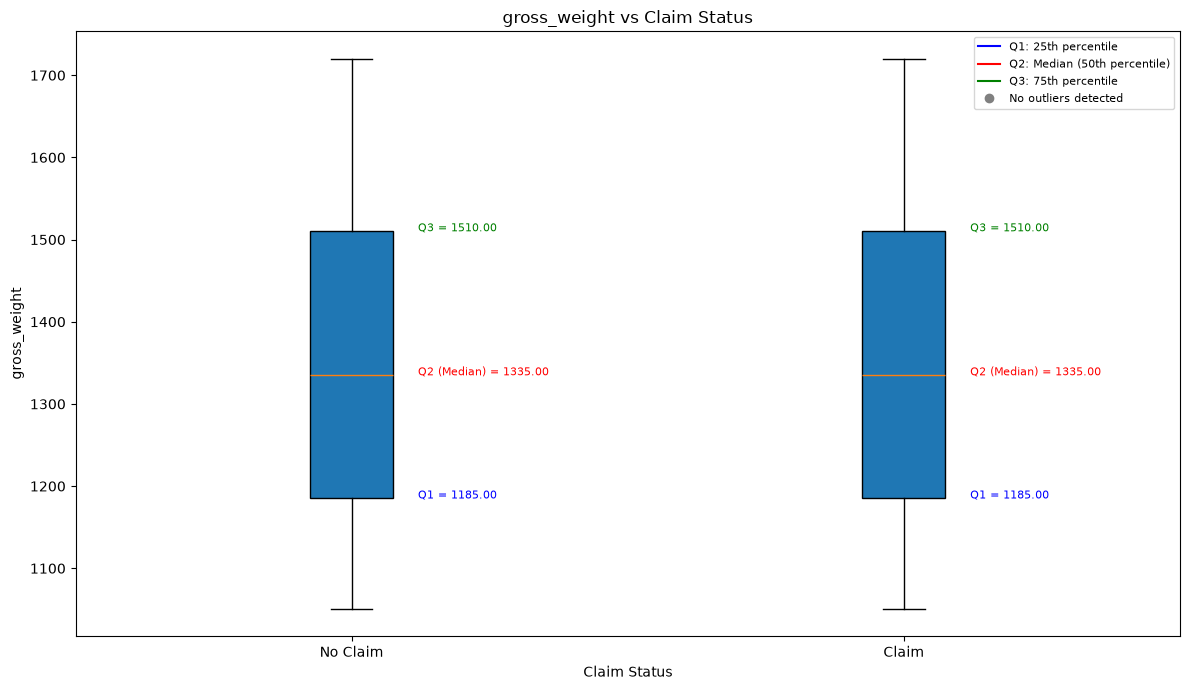

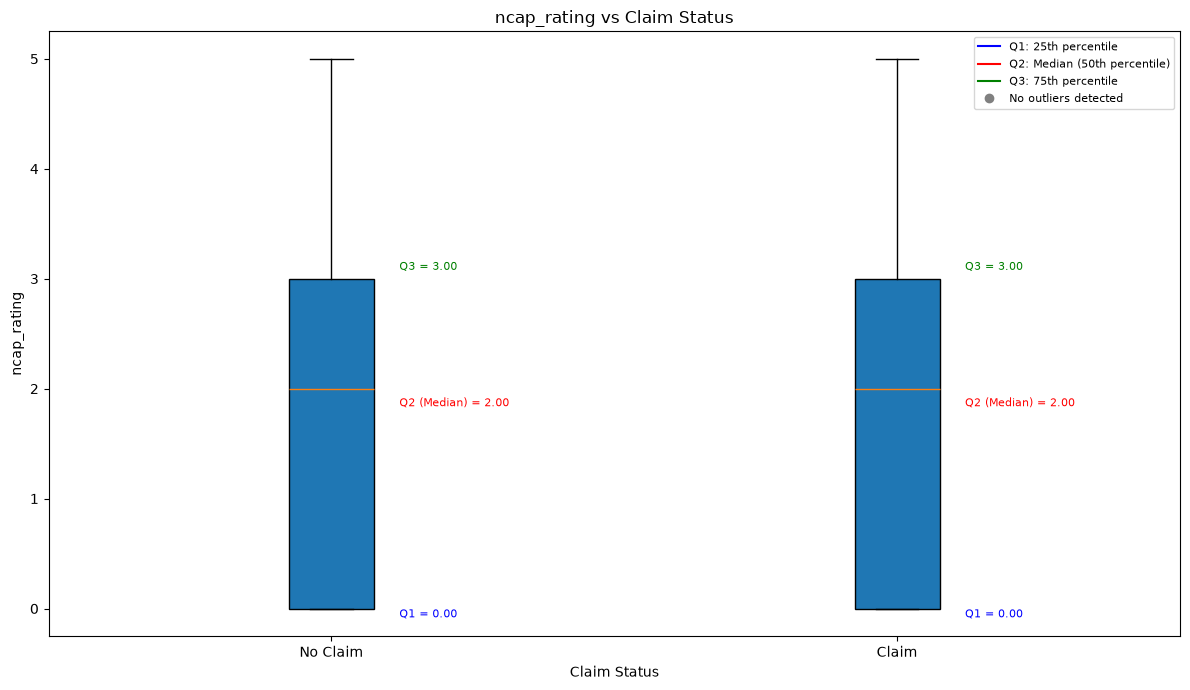

In [ ]:

# # NUMERICAL vs CLAIM



#     plt.xlabel("Claim Status")
#     plt.ylabel(col)
#     plt.legend()
    
#     plt.tight_layout()
#     plt.show()




import numpy as np
import matplotlib.pyplot as plt

# ============================================
# NUMERICAL vs CLAIM
# ============================================

numerical_columns = Insurance_df.select_dtypes(
    include=np.number
).drop(columns=["claim_status"]).columns.tolist()

for col in numerical_columns:

    # Separate values by claim status
    no_claim = Insurance_df.loc[
        Insurance_df["claim_status"] == 0, col
    ].dropna()

    claim = Insurance_df.loc[
        Insurance_df["claim_status"] == 1, col
    ].dropna()

    # Skip empty groups
    if no_claim.empty or claim.empty:
        continue

    plt.figure(figsize=(12, 7))

    # Create boxplot
    box = plt.boxplot(
        [no_claim, claim],
        tick_labels=["No Claim", "Claim"],
        patch_artist=True
    )

    # QUARTILE LABELS

    for i, data in enumerate([no_claim, claim], start=1):

        q1, median, q3 = np.percentile(
            data, [25, 50, 75]
        )

        # Q1: 25th percentile
        plt.annotate(
            f"Q1 = {q1:.2f}",
            xy=(i, q1),
            xytext=(i + 0.12, q1 - 0.08),
            fontsize=8,
            color="blue"
        )

        # Q2: Median (50th percentile)
        plt.annotate(
            f"Q2 (Median) = {median:.2f}",
            xy=(i, median),
            xytext=(i + 0.12, median - 0.16),
            fontsize=8,
            color="red"
        )

        # Q3: 75th percentile
        plt.annotate(
            f"Q3 = {q3:.2f}",
            xy=(i, q3),
            xytext=(i + 0.12, q3 + 0.08),
            fontsize=8,
            color="green"
        )

    # OUTLIER LABELS

    outlier_labels = [
        "No Claim Outliers",
        "Claim Outliers"
    ]

    outlier_colors = ["purple", "orange"]

    outlier_found = False

    for i, flier in enumerate(box["fliers"]):

        outliers = flier.get_ydata()

        if len(outliers) > 0:

            outlier_found = True

            plt.scatter(
                np.full(len(outliers), i + 1),
                outliers,
                color=outlier_colors[i],
                marker="o",
                s=25,
                label=outlier_labels[i],
                zorder=3
            )

    # QUARTILE LEGEND

    plt.plot(
        [], [], color="blue",
        label="Q1: 25th percentile"
    )

    plt.plot(
        [], [], color="red",
        label="Q2: Median (50th percentile)"
    )

    plt.plot(
        [], [], color="green",
        label="Q3: 75th percentile"
    )

    if not outlier_found:
        plt.plot(
            [], [], marker="o", linestyle="None",
            color="gray", label="No outliers detected"
        )

    # CHART DETAILS

    plt.title(f"{col} vs Claim Status")
    plt.xlabel("Claim Status")
    plt.ylabel(col)

    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

   
    

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16460\3191543746.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = Insurance_df.select_dtypes(


['region_code', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']
Skipping region_code: too many categories

--------------------------------------------------
segment
--------------------------------------------------
claim_status      0     1
segment                  
A             16275  1046
B1             3929   244
B2            17058  1256
C1             3329   228
C2            13117   901
Utility        1136    73


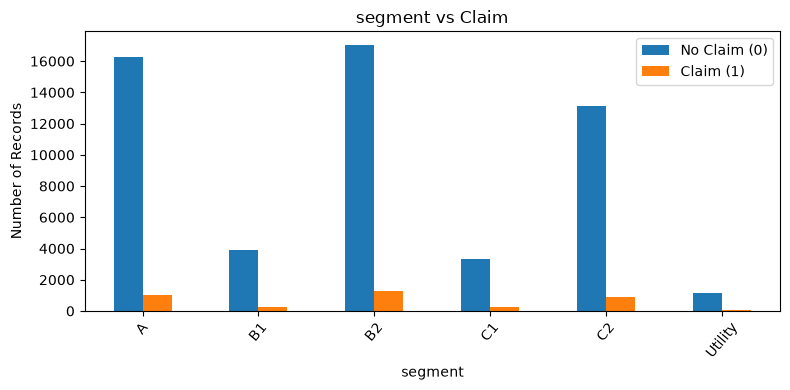


--------------------------------------------------
model
--------------------------------------------------
claim_status      0    1
model                   
M1            14030  918
M10            1136   73
M11             348   15
M2             1000   80
M3             2245  128
M4            13117  901
M5             1482  116
M6            12837  939
M7             2739  201
M8             3929  244
M9             1981  133


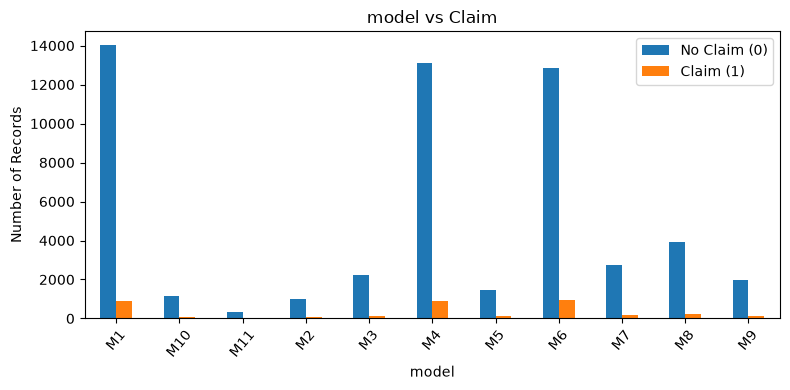


--------------------------------------------------
fuel_type
--------------------------------------------------
claim_status      0     1
fuel_type                
CNG           19095  1235
Diesel        16580  1150
Petrol        19169  1363


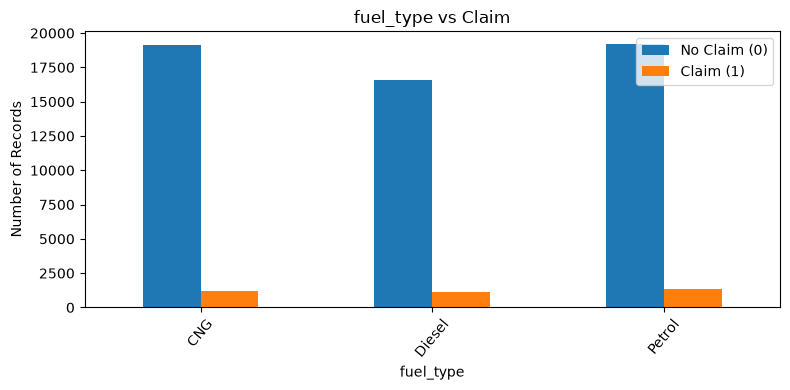


--------------------------------------------------
max_torque
--------------------------------------------------
claim_status        0     1
max_torque                 
113Nm@4400rpm   16576  1220
170Nm@4000rpm     348    15
200Nm@1750rpm    1981   133
200Nm@3000rpm    1482   116
250Nm@2750rpm   13117   901
60Nm@3500rpm    14030   918
82.1Nm@3400rpm   3929   244
85Nm@3000rpm     1136    73
91Nm@4250rpm     2245   128


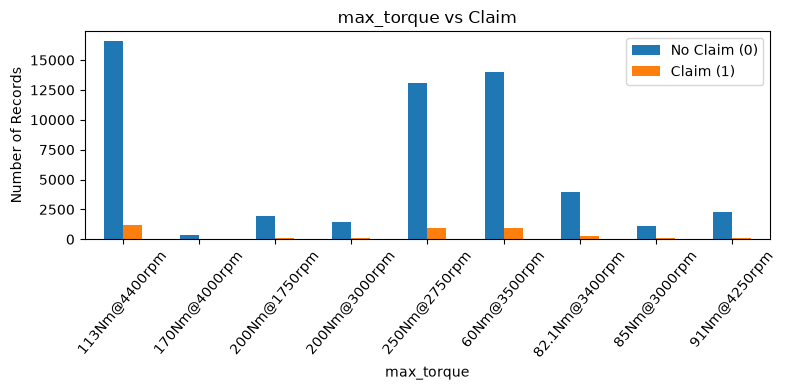


--------------------------------------------------
max_power
--------------------------------------------------
claim_status           0     1
max_power                     
113.45bhp@4000rpm  13117   901
118.36bhp@5500rpm    348    15
40.36bhp@6000rpm   14030   918
55.92bhp@5300rpm    3929   244
61.68bhp@6000rpm    1136    73
67.06bhp@5500rpm    2245   128
88.50bhp@6000rpm   16576  1220
88.77bhp@4000rpm    1482   116
97.89bhp@3600rpm    1981   133


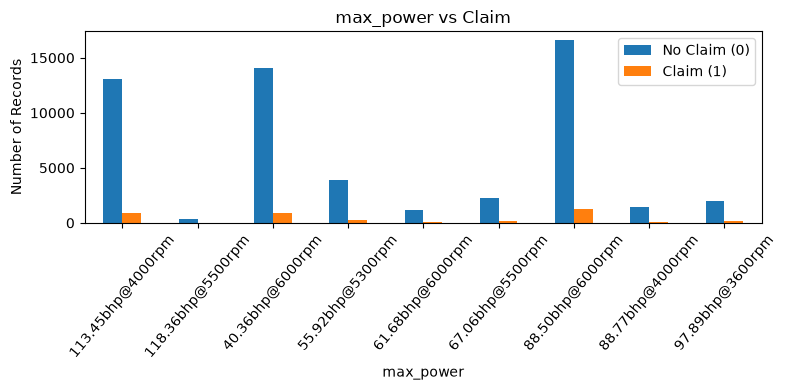


--------------------------------------------------
engine_type
--------------------------------------------------
claim_status                   0    1
engine_type                          
1.0 SCe                     2245  128
1.2 L K Series Engine       2739  201
1.2 L K12N Dualjet          1000   80
1.5 L U2 CRDi              13117  901
1.5 Turbocharged Revotorq   1482  116
1.5 Turbocharged Revotron    348   15
F8D Petrol Engine          14030  918
G12B                        1136   73
K Series Dual jet          12837  939
K10C                        3929  244
i-DTEC                      1981  133


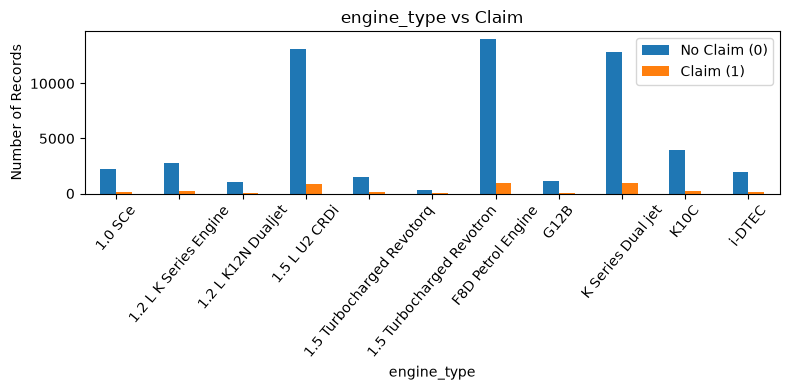


--------------------------------------------------
is_esc
--------------------------------------------------
claim_status      0     1
is_esc                   
No            37640  2551
Yes           17204  1197


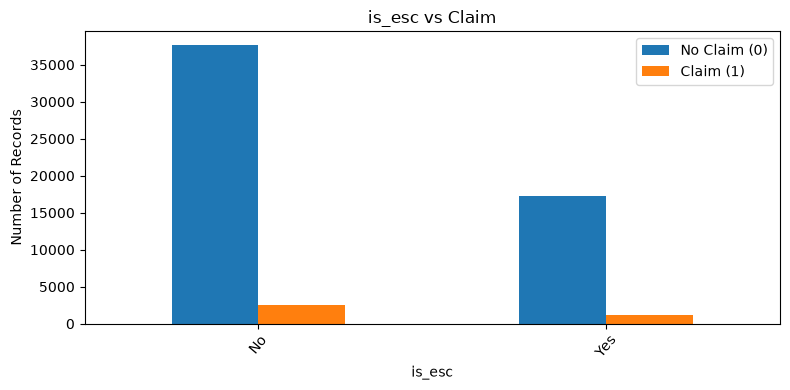


--------------------------------------------------
is_adjustable_steering
--------------------------------------------------
claim_status                0     1
is_adjustable_steering             
No                      21688  1378
Yes                     33156  2370


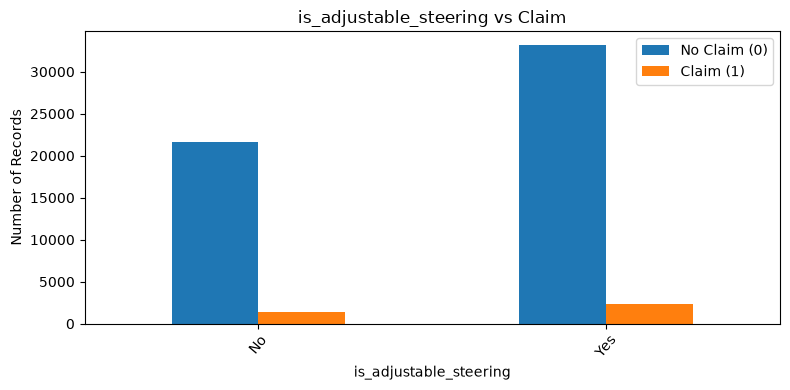


--------------------------------------------------
is_tpms
--------------------------------------------------
claim_status      0     1
is_tpms                  
No            41727  2847
Yes           13117   901


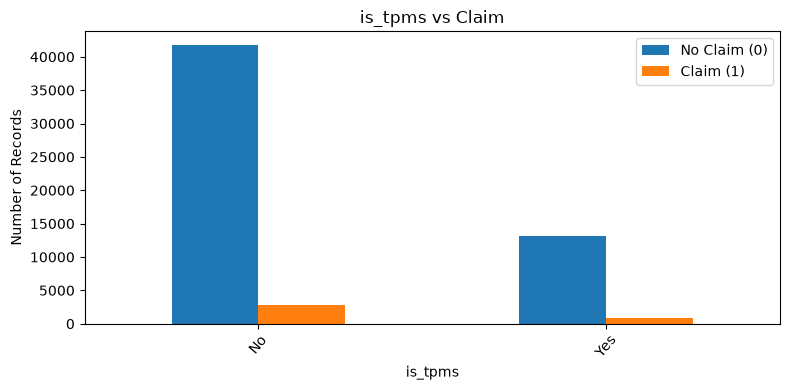


--------------------------------------------------
is_parking_sensors
--------------------------------------------------
claim_status            0     1
is_parking_sensors             
No                   2245   128
Yes                 52599  3620


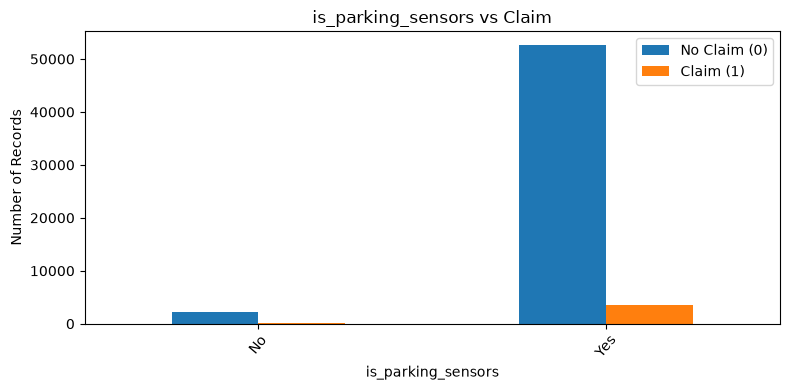


--------------------------------------------------
is_parking_camera
--------------------------------------------------
claim_status           0     1
is_parking_camera             
No                 33414  2290
Yes                21430  1458


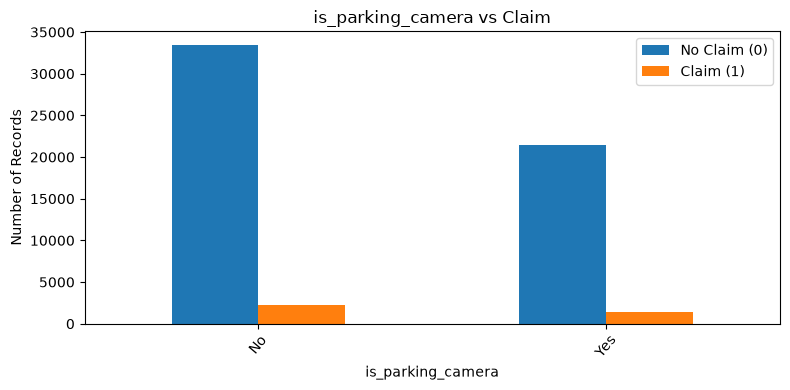


--------------------------------------------------
rear_brakes_type
--------------------------------------------------
claim_status          0     1
rear_brakes_type             
Disc              13117   901
Drum              41727  2847


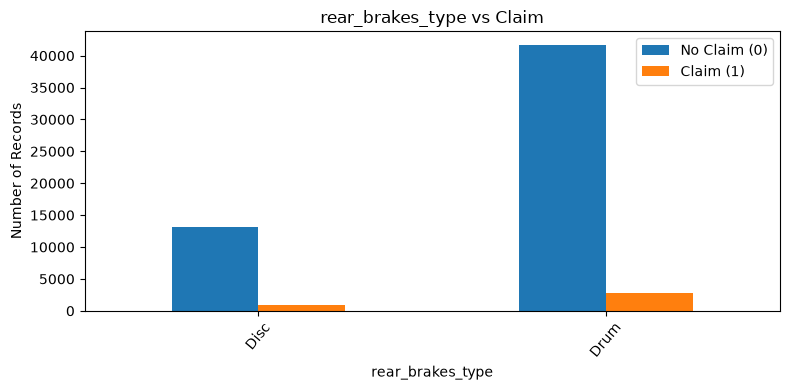


--------------------------------------------------
transmission_type
--------------------------------------------------
claim_status           0     1
transmission_type             
Automatic          19101  1310
Manual             35743  2438


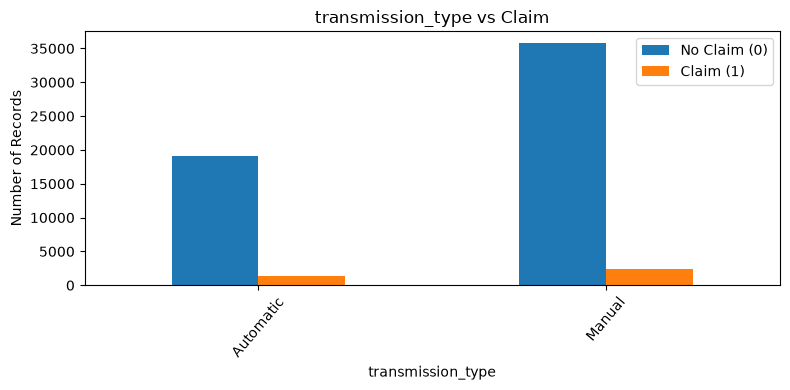


--------------------------------------------------
steering_type
--------------------------------------------------
claim_status       0     1
steering_type             
Electric       22284  1597
Manual          1136    73
Power          31424  2078


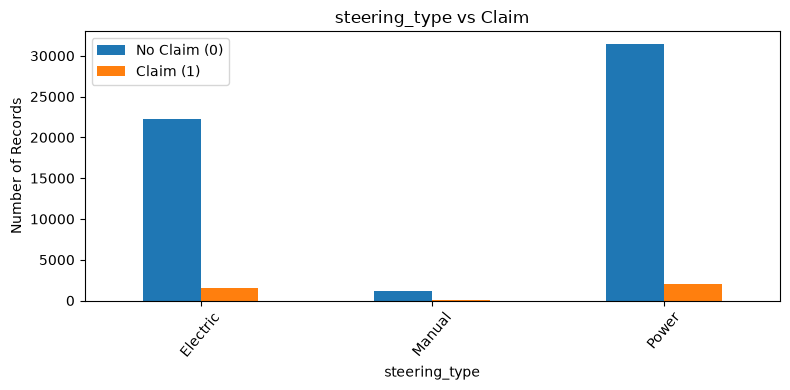


--------------------------------------------------
is_front_fog_lights
--------------------------------------------------
claim_status             0     1
is_front_fog_lights             
No                   23170  1494
Yes                  31674  2254


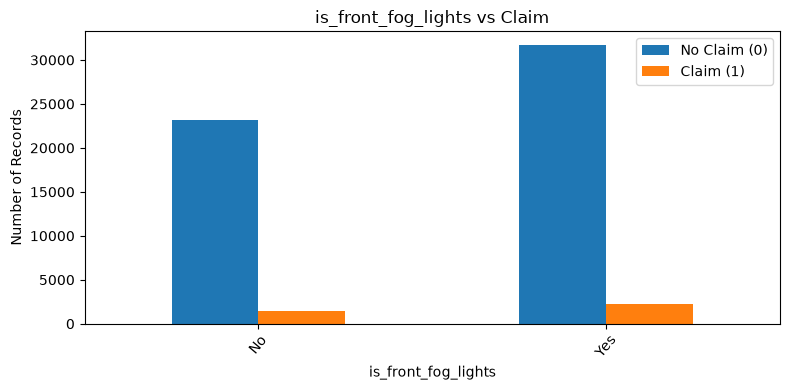


--------------------------------------------------
is_rear_window_wiper
--------------------------------------------------
claim_status              0     1
is_rear_window_wiper             
No                    38988  2646
Yes                   15856  1102


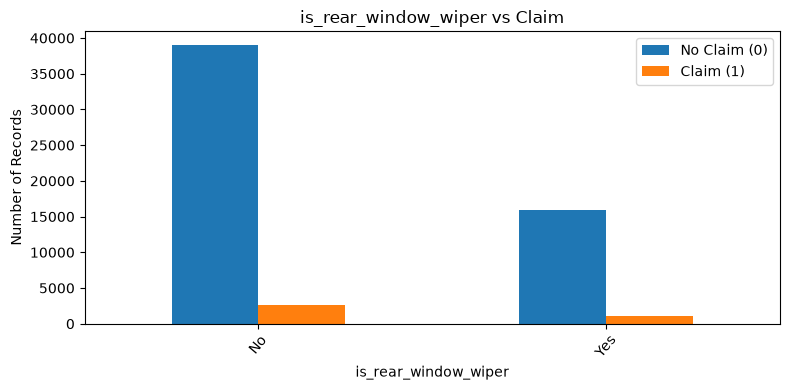


--------------------------------------------------
is_rear_window_washer
--------------------------------------------------
claim_status               0     1
is_rear_window_washer             
No                     38988  2646
Yes                    15856  1102


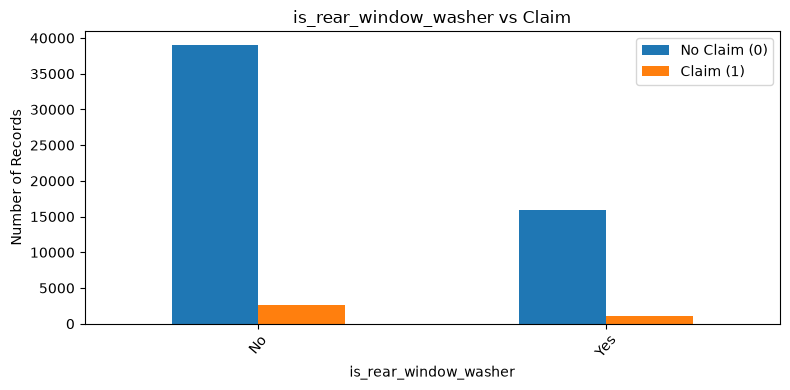


--------------------------------------------------
is_rear_window_defogger
--------------------------------------------------
claim_status                 0     1
is_rear_window_defogger             
No                       35659  2418
Yes                      19185  1330


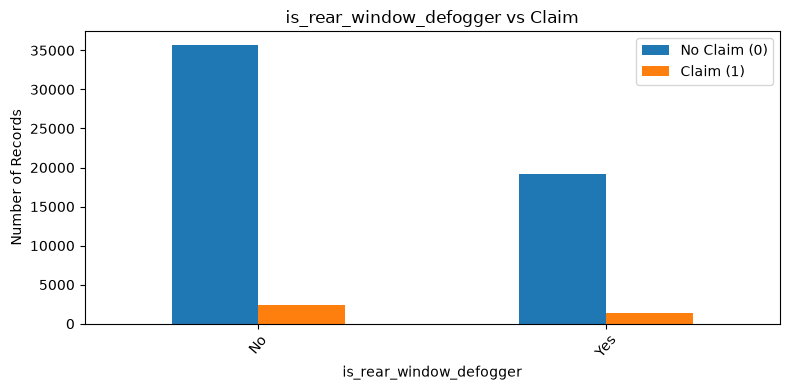


--------------------------------------------------
is_brake_assist
--------------------------------------------------
claim_status         0     1
is_brake_assist             
No               24803  1612
Yes              30041  2136


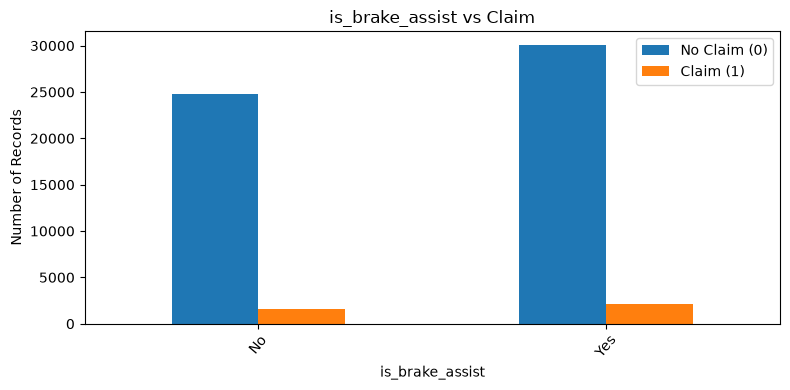


--------------------------------------------------
is_power_door_locks
--------------------------------------------------
claim_status             0     1
is_power_door_locks             
No                   15166   991
Yes                  39678  2757


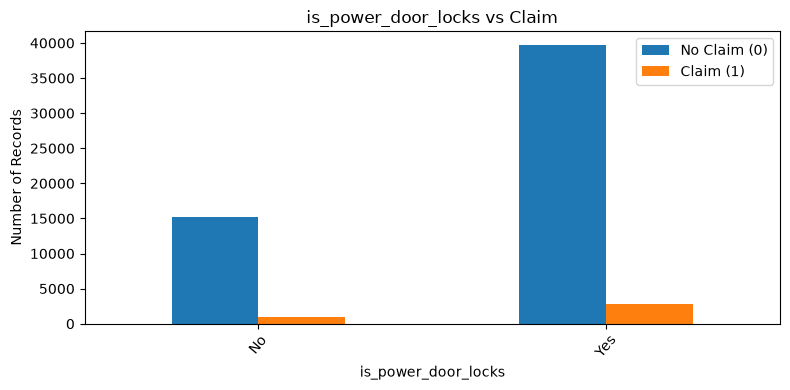


--------------------------------------------------
is_central_locking
--------------------------------------------------
claim_status            0     1
is_central_locking             
No                  15166   991
Yes                 39678  2757


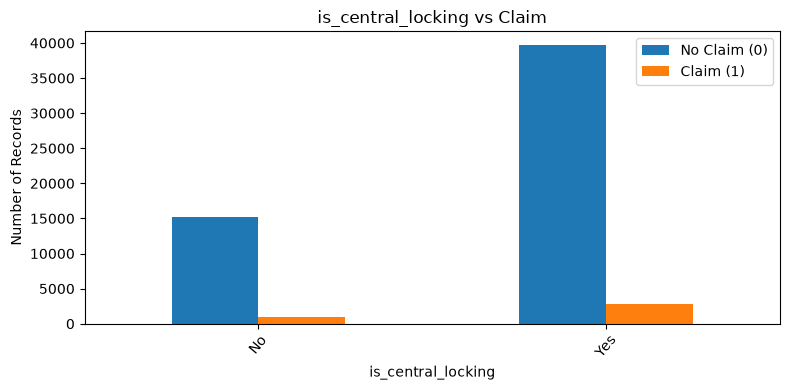


--------------------------------------------------
is_power_steering
--------------------------------------------------
claim_status           0     1
is_power_steering             
No                  1136    73
Yes                53708  3675


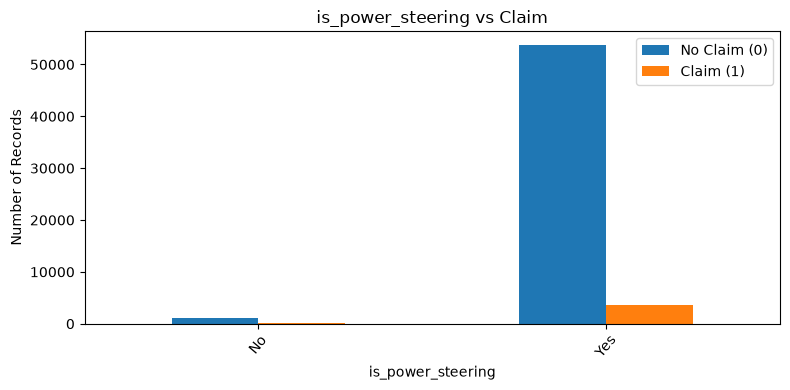


--------------------------------------------------
is_driver_seat_height_adjustable
--------------------------------------------------
claim_status                          0     1
is_driver_seat_height_adjustable             
No                                22822  1479
Yes                               32022  2269


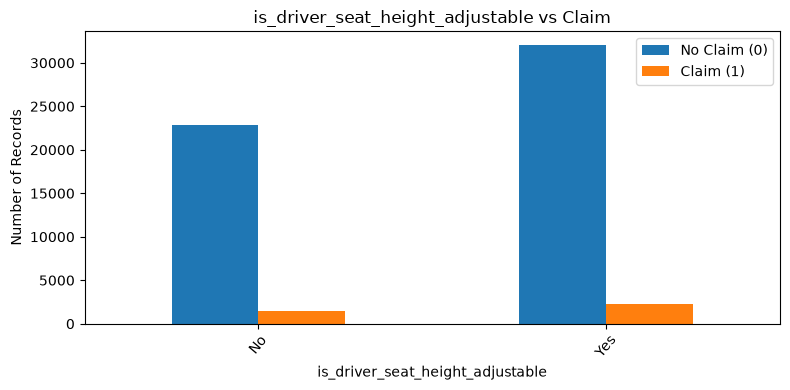


--------------------------------------------------
is_day_night_rear_view_mirror
--------------------------------------------------
claim_status                       0     1
is_day_night_rear_view_mirror             
No                             34042  2267
Yes                            20802  1481


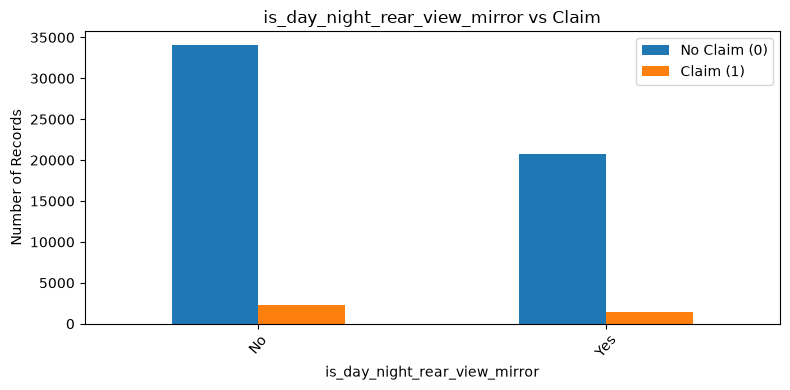


--------------------------------------------------
is_ecw
--------------------------------------------------
claim_status      0     1
is_ecw                   
No            15166   991
Yes           39678  2757


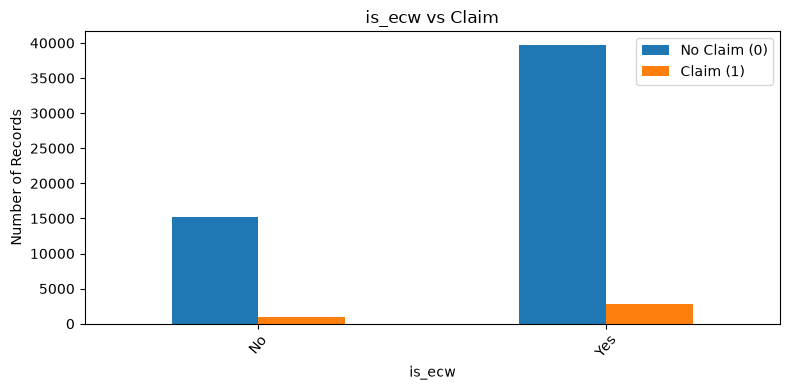


--------------------------------------------------
is_speed_alert
--------------------------------------------------
claim_status        0     1
is_speed_alert             
No                348    15
Yes             54496  3733


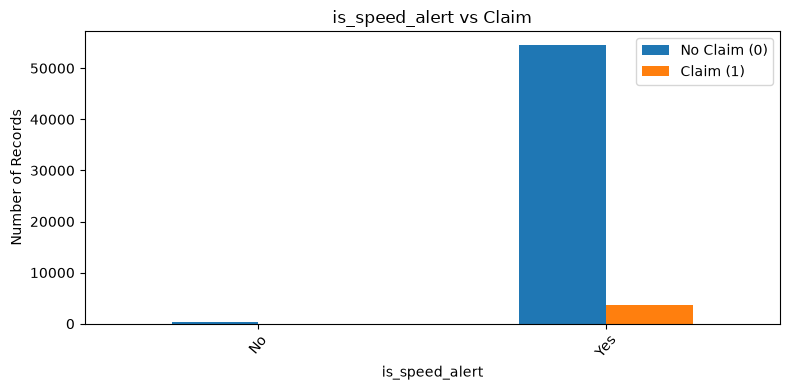

In [ ]:


# CATEGORICAL vs CLAIM

categorical_columns = Insurance_df.select_dtypes(
    include=["object", "category", "bool"]
)

# Removing policy ID

categorical_columns = categorical_columns.drop(['policy_id'] , axis= 1)

print(categorical_columns.columns.to_list())

for col in categorical_columns:

    # Skipping columns with too many unique values
    if Insurance_df[col].nunique(dropna=False) > 20:
        print(f"Skipping {col}: too many categories")
        continue

    table = pd.crosstab(
        Insurance_df[col],
        Insurance_df["claim_status"]
    )

    print("\n" + "-" * 50)
    print(col)
    print("-" * 50)
    print(table)

    # Ensuring both target classes have consistent labels
    table = table.reindex(columns=[0, 1], fill_value=0)
    table.columns = ["No Claim (0)", "Claim (1)"]

    table.plot(kind="bar", figsize=(8, 4))

    plt.title(f"{col} vs Claim")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=50)
    plt.tight_layout()
    plt.show()
    plt.close()



----------------------------------------------------------------------
MULTIVARIATE ANALYSIS
----------------------------------------------------------------------

Correlation Matrix:
                     subscription_length  vehicle_age  customer_age  \
subscription_length                 1.00         0.17          0.14   
vehicle_age                         0.17         1.00         -0.04   
customer_age                        0.14        -0.04          1.00   
region_density                     -0.10        -0.06          0.01   
airbags                             0.10         0.21         -0.01   
displacement                        0.19         0.39         -0.02   
cylinder                            0.19         0.38          0.00   
turning_radius                      0.17         0.33         -0.02   
length                              0.19         0.38         -0.02   
width                               0.21         0.41         -0.01   
gross_weight                      

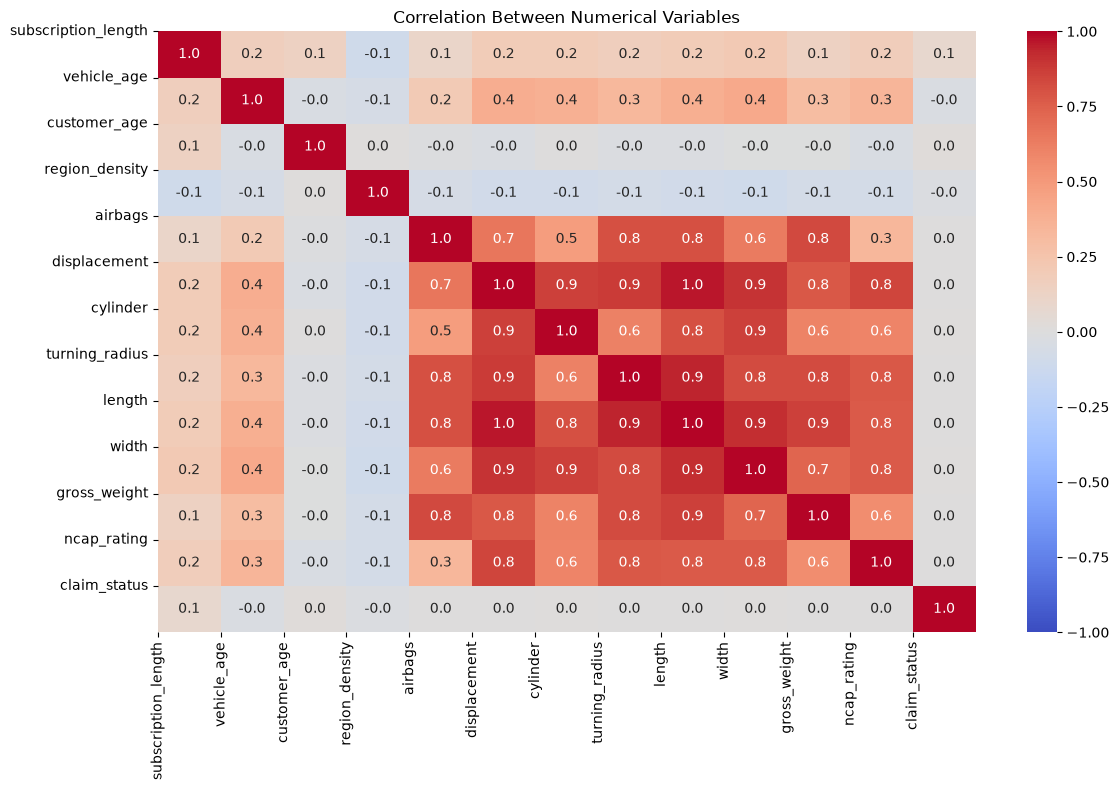

In [ ]:
# Multivariate Analysis?

# Multivariate analysis means analyzing three or more variables together

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("-" * 70)
print("MULTIVARIATE ANALYSIS")
print("-" * 70)


# Select numerical columns
numerical_columns = Insurance_df.select_dtypes(
    include=np.number
).columns.tolist()


# Calculate correlation
correlation = Insurance_df[numerical_columns].corr()


print("\nCorrelation Matrix:")
print(correlation.round(2))


# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot= True, vmin= -1, vmax= 1, cmap='coolwarm', fmt='.1f')

# X-axis labels
plt.xticks(range(len(numerical_columns)),numerical_columns,rotation=90)


# Y-axis labels
plt.yticks(
    range(len(numerical_columns)),
    numerical_columns
)


plt.title("Correlation Between Numerical Variables")

plt.tight_layout()
plt.show()

In [ ]:
# Data Preprocessing is the process of cleaning and analysing the data and making it clean data

# 1. Check missing values
print("Missing values before handling:")
print(Insurance_df.isnull().sum())

# Percentage of missing values in numerical cols
numerical_cols = Insurance_df.select_dtypes(include=np.number).columns


print(numerical_cols.isnull().sum() / len(Insurance_df) * 100)




for col in numerical_cols:
    Insurance_df[col] = Insurance_df[col].fillna(
        Insurance_df[col].median()
    )

# Fill missing categorical values with the mode
categorical_cols = Insurance_df.select_dtypes(
    include=["object", "category", "bool"]
).columns

for col in categorical_cols:
    if Insurance_df[col].isnull().any():
        Insurance_df[col] = Insurance_df[col].fillna(
            Insurance_df[col].mode()[0]
        )

# Removing extra spaces from the categorical data

print("\nMissing values after handling:")
print(Insurance_df.isnull().sum())

for col in Insurance_df.select_dtypes(include=["object"]).columns:
    Insurance_df[col] = Insurance_df[col].str.strip()

print("\nDuplicate records:", Insurance_df.duplicated().sum())


Missing values before handling:
policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width             

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_18068\913219278.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = Insurance_df.select_dtypes(



Missing values after handling:
policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width             

C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_18068\913219278.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in Insurance_df.select_dtypes(include=["object"]).columns:



Duplicate records: 0


In [ ]:
# Encoding categorical variables
# Convert text categories into numerical columns so models can use them.


# Preview one-hot encoding
categorical_cols = Insurance_df.select_dtypes(
    include=["object", "category", "bool"]
).columns

for col in categorical_cols:
    print(col, ":", Insurance_df[col].nunique(), "unique values")

policy_id : 58592 unique values
region_code : 22 unique values
segment : 6 unique values
model : 11 unique values
fuel_type : 3 unique values
max_torque : 9 unique values
max_power : 9 unique values
engine_type : 11 unique values
is_esc : 2 unique values
is_adjustable_steering : 2 unique values
is_tpms : 2 unique values
is_parking_sensors : 2 unique values
is_parking_camera : 2 unique values
rear_brakes_type : 2 unique values
transmission_type : 2 unique values
steering_type : 3 unique values
is_front_fog_lights : 2 unique values
is_rear_window_wiper : 2 unique values
is_rear_window_washer : 2 unique values
is_rear_window_defogger : 2 unique values
is_brake_assist : 2 unique values
is_power_door_locks : 2 unique values
is_central_locking : 2 unique values
is_power_steering : 2 unique values
is_driver_seat_height_adjustable : 2 unique values
is_day_night_rear_view_mirror : 2 unique values
is_ecw : 2 unique values
is_speed_alert : 2 unique values


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_16284\943073900.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = Insurance_df.select_dtypes(


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Labelencoder converts text format to numberical format most machine learning algorithms work with numerical data, not raw text categories.
encoder = LabelEncoder()

Insurance_df['fuel_type'] = encoder.fit_transform(Insurance_df['fuel_type'])

print(Insurance_df['fuel_type'])

0        1
1        1
2        1
3        0
4        1
        ..
58587    2
58588    1
58589    2
58590    2
58591    2
Name: fuel_type, Length: 58592, dtype: int64


In [ ]:
# OneHotEncoding is used to create seperate cols for each class

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)

encoded_data = encoder.fit_transform(
    Insurance_df[['fuel_type']]
)

print(encoded_data)



# Feature scaling where required
# Feature scaling brings numerical features to a similar scale.
# Some algorithms, such as KNN and Logistic Regression, can be affected when features have very different scales.


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    Insurance_df[['vehicle_age', 'customer_age', 'region_density']]
)

print(scaled_data[:5])

# StandardScaler() creates the scaler.

# fit_transform() calculates the mean and standard deviation, then scales the data.

# The scaled values are generally centered around 0.

[[0 1 0]
 [0 1 0]
 [0 1 0]
 ...
 [0 0 1]
 [0 0 1]
 [0 0 1]]
[[-0.1661427  -0.55135322 -0.56811127]
 [ 0.36276973 -1.41646188  0.46297453]
 [-1.04766342 -0.11879889 -0.56811127]
 [-0.87135928 -0.11879889  3.09190639]
 [-0.34244685  1.61141844 -0.75973049]]


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_19536\922352913.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box = plt.boxplot(age, vert=True)


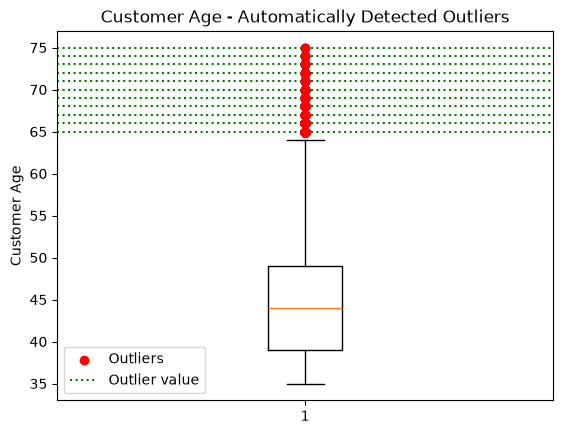

Number of outlier observations: 282


In [ ]:

# Handling potential outliers
# Outliers are values that are unusually far from most other values.
# Outliers can influence some models and statistical summaries.

import matplotlib.pyplot as plt
import numpy as np

age = Insurance_df['customer_age'].dropna()

# Create box plot
box = plt.boxplot(age, vert=True)

# Automatically get outlier values
outliers = box['fliers'][0].get_ydata()

# Highlight outliers in red
plt.scatter(
    np.ones(len(outliers)),
    outliers,
    color='red',
    label='Outliers',
    zorder=3
)

# horizontal dotted lines at outlier values

for i, value in enumerate(np.unique(outliers)):
    plt.axhline(
        value,
        linestyle='dotted',
        color='green',
        label='Outlier value'if i == 0 else None
    )

plt.ylabel('Customer Age')
plt.title('Customer Age - Automatically Detected Outliers')
plt.legend()
plt.show()


print("Number of outlier observations:", len(outliers))

In [ ]:
from sklearn.model_selection import train_test_split

X = Insurance_df.drop(
    columns=['claim_status', 'policy_id'],
    errors='ignore'
)

y = Insurance_df['claim_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (46873, 39)
Testing features: (11719, 39)
Training target: (46873,)
Testing target: (11719,)


In [ ]:
# Create a new feature from vehicle_age Feature engineering means creating new useful features from existing columns to help a machine learning model identify patterns.

X_train["vehicle_age_group"] = pd.cut(
    X_train["vehicle_age"],
    bins=[-1, 2, 5, float("inf")],
    labels=["New", "Medium", "Old"]
)

X_test["vehicle_age_group"] = pd.cut(
    X_test["vehicle_age"],
    bins=[-1, 2, 5, float("inf")],
    labels=["New", "Medium", "Old"]
)

print(X_train[["vehicle_age", "vehicle_age_group"]].head())

       vehicle_age vehicle_age_group
47157          1.6               New
58129          0.2               New
35007          1.6               New
6067           0.4               New
34788          2.2            Medium



 ---------------------------------------------
Logistic Regression
---------------------------------------------
Training Accuracy: 0.936
Testing Accuracy: 0.936

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



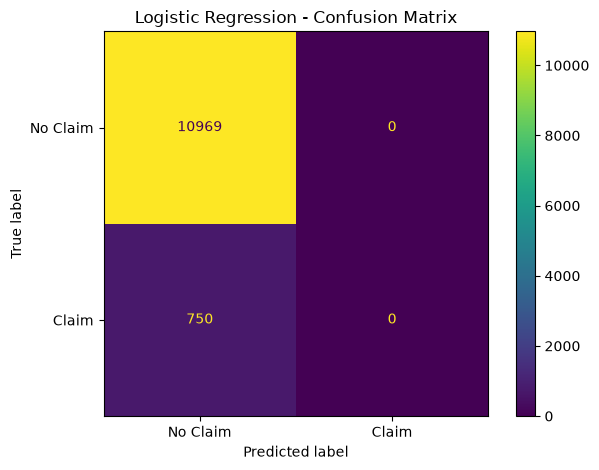


 ---------------------------------------------
Decision Tree
---------------------------------------------
Training Accuracy: 0.9394
Testing Accuracy: 0.9318

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.96     10969
           1       0.05      0.00      0.01       750

    accuracy                           0.93     11719
   macro avg       0.50      0.50      0.49     11719
weighted avg       0.88      0.93      0.90     11719



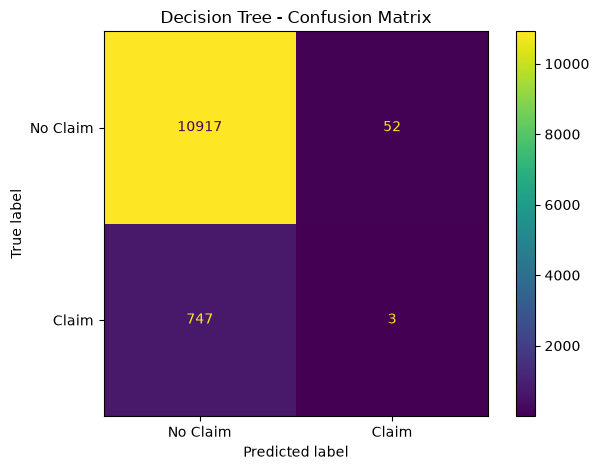


 ---------------------------------------------
Random Forest
---------------------------------------------
Training Accuracy: 0.9364
Testing Accuracy: 0.9359

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



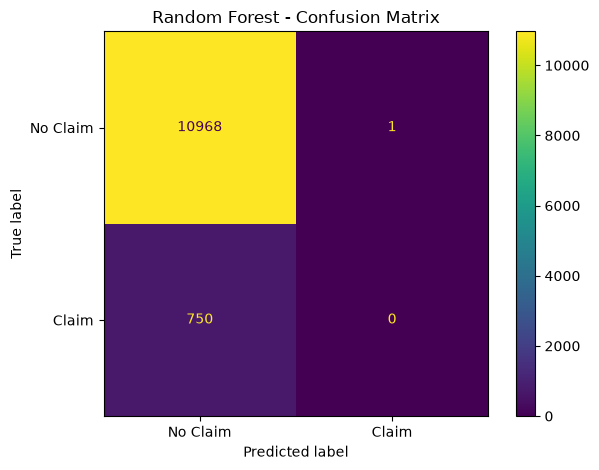


 ---------------------------------------------
AdaBoost
---------------------------------------------
Training Accuracy: 0.936
Testing Accuracy: 0.936

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



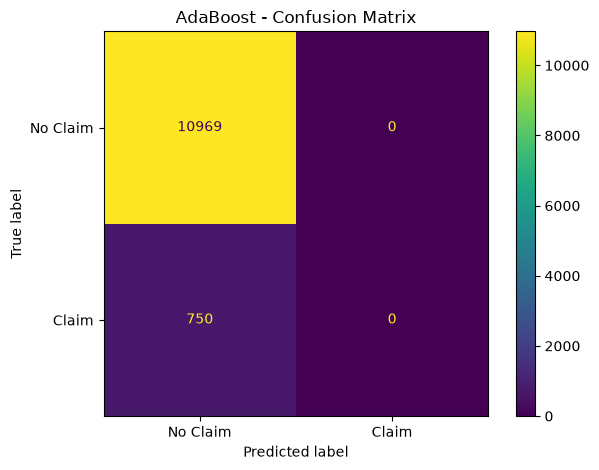


 ---------------------------------------------
KNN
---------------------------------------------
Training Accuracy: 0.9364
Testing Accuracy: 0.9342

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.18      0.01      0.02       750

    accuracy                           0.93     11719
   macro avg       0.56      0.50      0.49     11719
weighted avg       0.89      0.93      0.91     11719



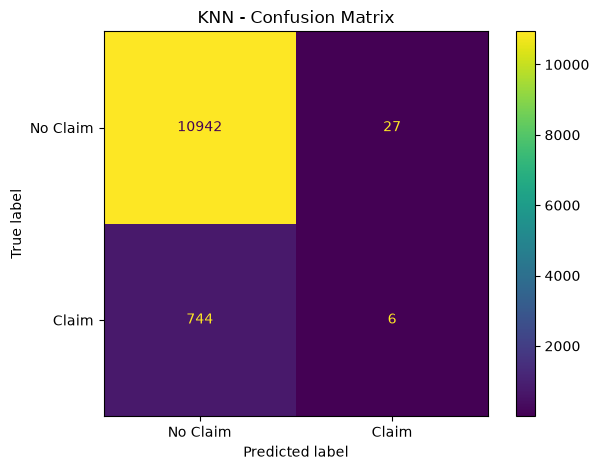


FINAL MODEL COMPARISON
              Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score
                KNN          0.9364         0.9342     0.1818   0.008    0.0153
      Decision Tree          0.9394         0.9318     0.0545   0.004    0.0075
Logistic Regression          0.9360         0.9360     0.0000   0.000    0.0000
      Random Forest          0.9364         0.9359     0.0000   0.000    0.0000
           AdaBoost          0.9360         0.9360     0.0000   0.000    0.0000


In [92]:
# Model Development

# I have to use and compare five models suggested for this project:

# Logistic Regression

# Decision Tree

# Random Forest

# AdaBoost

# K-Nearest Neighbors (KNN)



import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Separate features and target
X = Insurance_df.drop(
    columns=["claim_status", "policy_id"],
    errors="ignore"
)

y = Insurance_df["claim_status"]

# Remove rows with a missing target, if any
valid_rows = y.notna()
X = X.loc[valid_rows]
y = y.loc[valid_rows]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature engineering: create vehicle age groups
for data in [X_train, X_test]:
    data["vehicle_age_group"] = pd.cut(data["vehicle_age"],bins=[-1, 2, 5, float("inf")],labels=["New", "Medium", "Old"])

# Identify column types
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Preprocess numerical features
numerical_process = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocess categorical features
categorical_process = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numerical_process, numerical_cols),
    ("cat", categorical_process, categorical_cols)
])

# Models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=15,
        random_state=42, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=50, random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
fitted_models = {}

# Train and evaluate each model
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    precision = precision_score(
        y_test, test_pred, zero_division=0
    )

    recall = recall_score(
        y_test, test_pred, zero_division=0
    )

    f1 = f1_score(
        y_test, test_pred, zero_division=0
    )

    results.append({
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    fitted_models[name] = pipeline

    print("\n", "-" * 45)
    print(name)
    print("-" * 45)

    print("Training Accuracy:", round(train_accuracy, 4))
    print("Testing Accuracy:", round(test_accuracy, 4))
    print("\nClassification Report:")
    print(classification_report(
        y_test, test_pred, zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test, test_pred,
        labels=[0, 1],
        display_labels=["No Claim", "Claim"],
        values_format="d"
    )

    plt.title(name + " - Confusion Matrix")
    plt.tight_layout()
    plt.show()

# Compare all models
results_df = pd.DataFrame(results).sort_values(
    by="F1 Score", ascending=False
)

print("\nFINAL MODEL COMPARISON")
print(results_df.round(4).to_string(index=False))

In [93]:
# Test the selected model


final_model = fitted_models["Random Forest"]

final_predictions = final_model.predict(X_test)

print("Final Test Accuracy:",
      accuracy_score(y_test, final_predictions))

print("\nFinal Classification Report:")
print(classification_report(
    y_test, final_predictions, zero_division=0
))

Final Test Accuracy: 0.9359160337912791

Final Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



                           Feature  Importance
0         num__subscription_length    0.378215
2                num__customer_age    0.266437
1                 num__vehicle_age    0.194285
3              num__region_density    0.026040
124  cat__vehicle_age_group_Medium    0.007494
125     cat__vehicle_age_group_New    0.007155
32             cat__region_code_C8    0.005574
27             cat__region_code_C3    0.005231
23             cat__region_code_C2    0.004883
29             cat__region_code_C5    0.004757


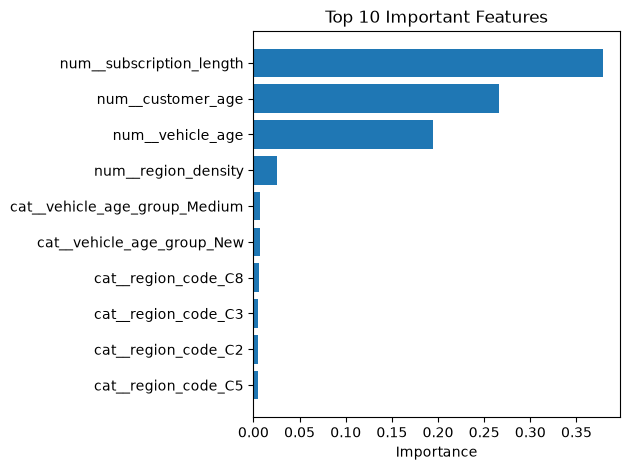

In [94]:
# understanding which features influence the model's predictions.


import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance = fitted_models["Random Forest"].named_steps["model"].feature_importances_

# Get feature names
features = fitted_models["Random Forest"].named_steps["preprocessing"].get_feature_names_out()

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

# Display top 10 features
importance_df = importance_df.sort_values(
    by="Importance", ascending=False
).head(10)

print(importance_df)

# Plot
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# It displays training accuracy, testing accuracy, precision, recall, and F1 score for every model.

print(results_df.round(4).to_string(index=False))

              Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score
                KNN          0.9365         0.9342     0.1818   0.008    0.0153
      Decision Tree          0.9394         0.9319     0.0556   0.004    0.0075
Logistic Regression          0.9360         0.9360     0.0000   0.000    0.0000
      Random Forest          0.9364         0.9359     0.0000   0.000    0.0000
           AdaBoost          0.9360         0.9360     0.0000   0.000    0.0000


In [95]:
# Select the final model
# For insurance claims, recall and F1 score are important because the model should identify actual claims without producing too many false alarms

best_model_name = results_df.iloc[0]["Model"]

print("Selected Model:", best_model_name)
print(results_df.iloc[0])

Selected Model: KNN
Model                  KNN
Train Accuracy    0.936445
Test Accuracy     0.934209
Precision         0.181818
Recall               0.008
F1 Score          0.015326
Name: 4, dtype: object


              precision    recall  f1-score   support

    No Claim       0.94      1.00      0.97     10969
       Claim       0.18      0.01      0.02       750

    accuracy                           0.93     11719
   macro avg       0.56      0.50      0.49     11719
weighted avg       0.89      0.93      0.91     11719



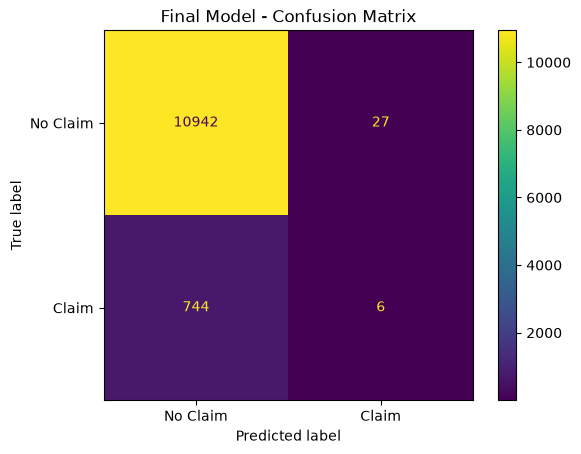

In [96]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_model = fitted_models[best_model_name]

predictions = final_model.predict(X_test)

print(classification_report(
    y_test, predictions,
    target_names=["No Claim", "Claim"],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test, predictions,
    display_labels=["No Claim", "Claim"]
)

plt.title("Final Model - Confusion Matrix")
plt.show()

In [ ]:
# Testing the model performance for new input data

import pandas as pd

# Created new customer data
new_data = pd.DataFrame([
    {
        "subscription_length": 12,
        "vehicle_age": 3,
        "customer_age": 30,
        "region_code": 5,
        "region_density": 5000,
        "segment": "B2",
        "model": "M1",
        "fuel_type": "Petrol",
        "max_torque": "113Nm@4400rpm",
        "max_power": "88.50bhp@6000rpm",
        "engine_type": "1.2L K Series",
        "airbags": 2,
        "is_esc": 0,
        "is_adjustable_steering": 1,
        "is_tpms": 0,
        "is_parking_sensors": 1,
        "is_parking_camera": 0,
        "rear_brakes_type": "Drum",
        "displacement": 1197,
        "cylinder": 4,
        "transmission_type": "Manual",
        "steering_type": "Power",
        "turning_radius": 4.8,
        "length": 3995,
        "width": 1735,
        "gross_weight": 1200,
        "is_front_fog_lights": 0,
        "is_rear_window_wiper": 0,
        "is_rear_window_washer": 0,
        "is_rear_window_defogger": 0,
        "is_brake_assist": 1,
        "is_power_door_locks": 1,
        "is_central_locking": 1,
        "is_power_steering": 1,
        "is_driver_seat_height_adjustable": 0,
        "is_day_night_rear_view_mirror": 0,
        "is_ecw": 1,
        "is_speed_alert": 1,
        "ncap_rating": 3,
        'vehicle_age_group' : 1
    }
])

# Predict using the selected model
predictions = final_model.predict(new_data)
prob_pred = final_model.predict_proba(new_data)


# To calculate probability in percentage

prob_pred = prob_pred * 100

# Display result
for prediction in predictions:
    if prediction == 1:
        print("Prediction: Claim")
    else:
        print("Prediction: No Claim")


print(f"Prediction_probability : ", prob_pred)

Prediction: No Claim
Prediction_probability :  [[80. 20.]]


0 = No Claim, 1 = Claim
claim_status
0    54844
1     3748
Name: count, dtype: int64


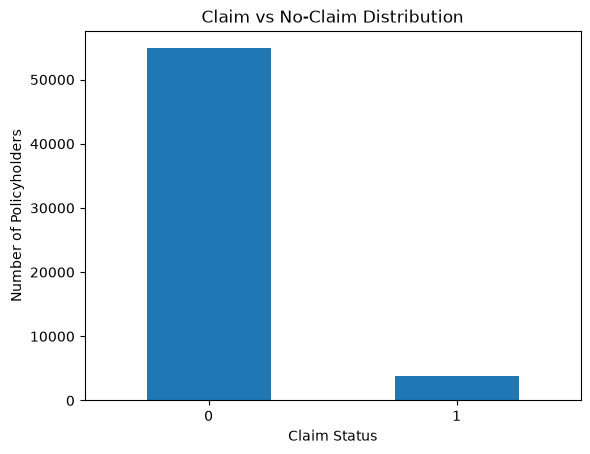

Overall claim rate: 6.4 %


In [ ]:
# Business Insights & Recommendations
# Claim vs. No-Claim Analysis
# This identifies the proportion of policyholders who filed claims

import matplotlib.pyplot as plt

claim_counts = Insurance_df["claim_status"].value_counts().sort_index()

print("0 = No Claim, 1 = Claim")
print(claim_counts)

claim_counts.plot(kind="bar")
plt.title("Claim vs No-Claim Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Number of Policyholders")
plt.xticks(rotation=0)
plt.show()

print("Overall claim rate:",
      round(Insurance_df["claim_status"].mean() * 100, 2), "%")

In [ ]:
# Which customer groups have higher claim rates?

# Create customer age groups
Insurance_df["customer_age_group"] = pd.cut(
    Insurance_df["customer_age"],
    bins=[0, 25, 40, 60, float("inf")],
    labels=["Under 25", "25-40", "41-60", "Above 60"]
)

# Create vehicle age groups
Insurance_df["vehicle_age_group"] = pd.cut(
    Insurance_df["vehicle_age"],
    bins=[-1, 2, 5, float("inf")],
    labels=["New", "Medium", "Old"]
)

# Compare claim rates by group
for column in [
    "customer_age_group",
    "vehicle_age_group",
    "fuel_type",
    "region_code"
]:
    summary = Insurance_df.groupby(
        column, observed=True
    )["claim_status"].agg(["count", "mean"])

    summary["claim_rate_%"] = summary["mean"] * 100

    # Ignore groups with fewer than 30 records
    summary = summary[summary["count"] >= 30]

    print("\nClaim rate by", column)
    print(summary[["count", "claim_rate_%"]].round(2).sort_values(
        "claim_rate_%", ascending=False
    ))


Claim rate by customer_age_group
                    count  claim_rate_%
customer_age_group                     
Above 60             1506          8.37
41-60               37272          6.69
25-40               19814          5.70

Claim rate by vehicle_age_group
                   count  claim_rate_%
vehicle_age_group                     
New                42765          6.74
Medium             15604          5.51
Old                  223          3.14

Claim rate by fuel_type
           count  claim_rate_%
fuel_type                     
2          20532          6.64
1          17730          6.49
0          20330          6.07

Claim rate by region_code
             count  claim_rate_%
region_code                     
C18            242         10.74
C22            207          8.21
C14           3660          7.68
C4             665          7.67
C21            379          7.65
C19            952          7.46
C3            6101          7.10
C2            7342          7.08
C

       count  mean  claim_rate_%
model                           
M2      1080  0.07          7.41
M5      1598  0.07          7.26
M7      2940  0.07          6.84
M6     13776  0.07          6.82
M4     14018  0.06          6.43
M9      2114  0.06          6.29
M1     14948  0.06          6.14
M10     1209  0.06          6.04
M8      4173  0.06          5.85
M3      2373  0.05          5.39
M11      363  0.04          4.13


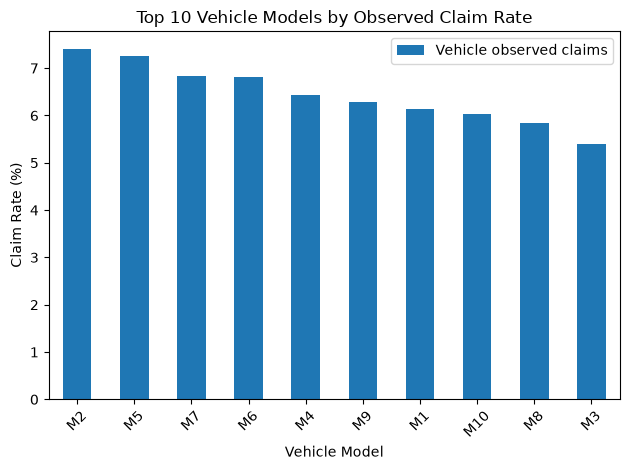

In [ ]:
# Which vehicle models have higher claim rates?

model_claims = Insurance_df.groupby("model")[
    "claim_status"
].agg(["count", "mean"])

model_claims["claim_rate_%"] = model_claims["mean"] * 100

model_claims = model_claims[model_claims["count"] >= 30]

model_claims = model_claims.sort_values(
    "claim_rate_%", ascending=False
)

print(model_claims.round(2))

model_claims["claim_rate_%"].head(10).plot(kind="bar", label='Vehicle observed claims')

plt.title("Top 10 Vehicle Models by Observed Claim Rate")
plt.xlabel("Vehicle Model")
plt.ylabel("Claim Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
# Identifying the strongest predictors

print(importance_df.head(10))

                           Feature  Importance
0         num__subscription_length    0.378215
2                num__customer_age    0.266437
1                 num__vehicle_age    0.194285
3              num__region_density    0.026040
124  cat__vehicle_age_group_Medium    0.007494
125     cat__vehicle_age_group_New    0.007155
32             cat__region_code_C8    0.005574
27             cat__region_code_C3    0.005231
23             cat__region_code_C2    0.004883
29             cat__region_code_C5    0.004757
